# First Experiment


Data Augmentation (Yes/No) + Weighted Random Sampler

Device: cuda
Loading dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/2.13k [00:00<?, ?B/s]

data/train-00000-of-00001-c08a401c53fe53(…):   0%|          | 0.00/22.6M [00:00<?, ?B/s]

data/test-00000-of-00001-44110b9df98c558(…):   0%|          | 0.00/5.65M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5120 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1280 [00:00<?, ? examples/s]

Train: 4096 | Val: 1024 | Test: 1280

STARTING EXPERIMENT: Baseline - No Augmentation
Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 114MB/s]


Epoch 01/25 | Train Loss: 0.8879 Acc: 0.6013 | Val Loss: 0.7135 Acc: 0.6729
Epoch 02/25 | Train Loss: 0.4965 Acc: 0.7871 | Val Loss: 0.5754 Acc: 0.7529
Epoch 03/25 | Train Loss: 0.3465 Acc: 0.8567 | Val Loss: 0.4915 Acc: 0.7910
Epoch 04/25 | Train Loss: 0.2434 Acc: 0.9050 | Val Loss: 0.4334 Acc: 0.8350
Epoch 05/25 | Train Loss: 0.1806 Acc: 0.9346 | Val Loss: 0.3487 Acc: 0.8682
Epoch 06/25 | Train Loss: 0.1382 Acc: 0.9502 | Val Loss: 0.2977 Acc: 0.9014
Epoch 07/25 | Train Loss: 0.1084 Acc: 0.9631 | Val Loss: 0.2577 Acc: 0.9082
Epoch 08/25 | Train Loss: 0.0880 Acc: 0.9683 | Val Loss: 0.2605 Acc: 0.9082
Epoch 09/25 | Train Loss: 0.0861 Acc: 0.9707 | Val Loss: 0.2615 Acc: 0.9082
Epoch 10/25 | Train Loss: 0.0669 Acc: 0.9800 | Val Loss: 0.2546 Acc: 0.9180
Epoch 11/25 | Train Loss: 0.0532 Acc: 0.9817 | Val Loss: 0.1881 Acc: 0.9375
Epoch 12/25 | Train Loss: 0.0493 Acc: 0.9819 | Val Loss: 0.1759 Acc: 0.9463
Epoch 13/25 | Train Loss: 0.0336 Acc: 0.9890 | Val Loss: 0.1767 Acc: 0.9521
Epoch 14/25 

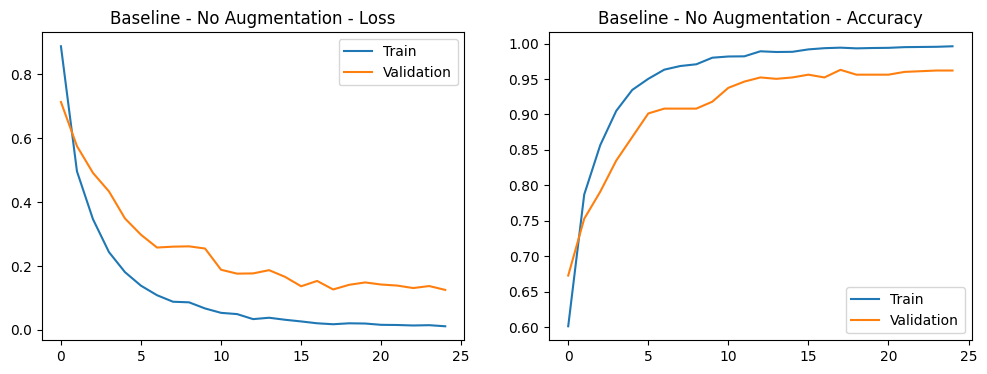


=== CLASSIFICATION REPORT: Baseline - No Augmentation ===
              precision    recall  f1-score   support

           0       0.99      0.90      0.94       172
           1       1.00      0.93      0.97        15
           2       0.94      0.97      0.96       634
           3       0.94      0.94      0.94       459

    accuracy                           0.95      1280
   macro avg       0.97      0.93      0.95      1280
weighted avg       0.95      0.95      0.95      1280



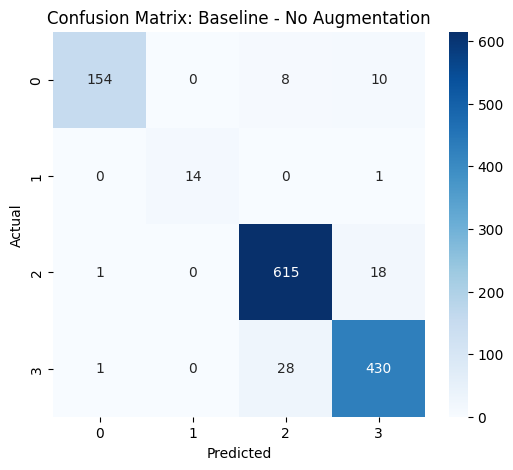


STARTING EXPERIMENT: Experiment - With Augmentation
Epoch 01/25 | Train Loss: 0.9960 Acc: 0.5574 | Val Loss: 0.9591 Acc: 0.5264
Epoch 02/25 | Train Loss: 0.6620 Acc: 0.6934 | Val Loss: 0.7179 Acc: 0.6533
Epoch 03/25 | Train Loss: 0.5698 Acc: 0.7520 | Val Loss: 0.6116 Acc: 0.7178
Epoch 04/25 | Train Loss: 0.4658 Acc: 0.8076 | Val Loss: 0.6355 Acc: 0.7178
Epoch 05/25 | Train Loss: 0.4203 Acc: 0.8220 | Val Loss: 0.4696 Acc: 0.8115
Epoch 06/25 | Train Loss: 0.3563 Acc: 0.8601 | Val Loss: 0.3940 Acc: 0.8301
Epoch 07/25 | Train Loss: 0.3011 Acc: 0.8794 | Val Loss: 0.4113 Acc: 0.8252
Epoch 08/25 | Train Loss: 0.2527 Acc: 0.8997 | Val Loss: 0.3774 Acc: 0.8350
Epoch 09/25 | Train Loss: 0.2286 Acc: 0.9104 | Val Loss: 0.3122 Acc: 0.8711
Epoch 10/25 | Train Loss: 0.1903 Acc: 0.9270 | Val Loss: 0.2690 Acc: 0.8877
Epoch 11/25 | Train Loss: 0.1826 Acc: 0.9321 | Val Loss: 0.2683 Acc: 0.8926
Epoch 12/25 | Train Loss: 0.1542 Acc: 0.9358 | Val Loss: 0.2592 Acc: 0.9053
Epoch 13/25 | Train Loss: 0.1245 Ac

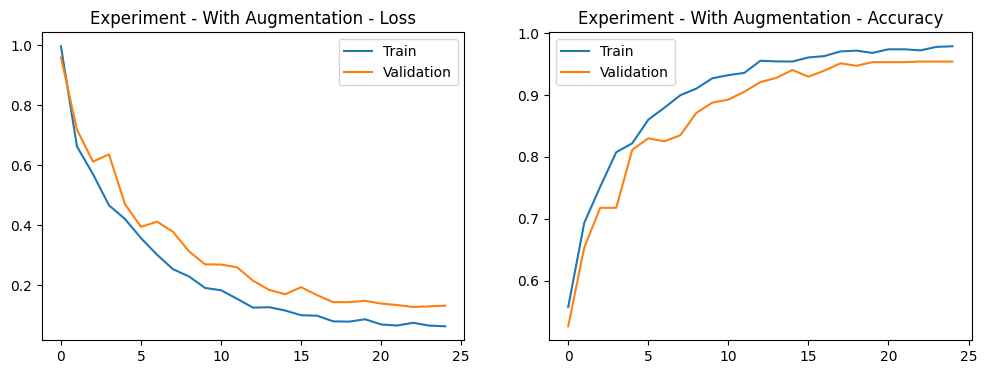


=== CLASSIFICATION REPORT: Experiment - With Augmentation ===
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       172
           1       1.00      1.00      1.00        15
           2       0.97      0.97      0.97       634
           3       0.95      0.96      0.96       459

    accuracy                           0.96      1280
   macro avg       0.98      0.97      0.97      1280
weighted avg       0.96      0.96      0.96      1280



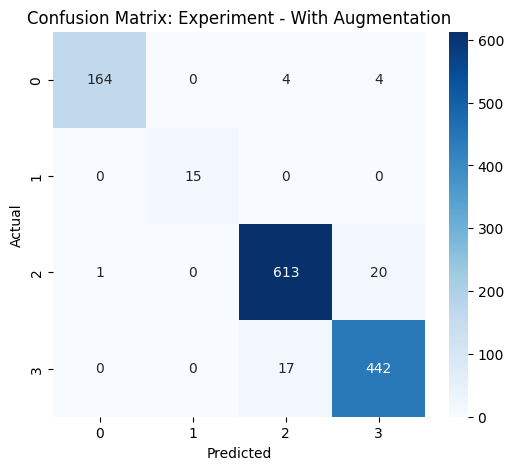

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CONFIG & SETUP
# ==========================================
CONFIG = {
    "lr": 1e-4,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"] # 5120 data
test_data = hf_dataset["test"]      # 1280 data

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

train_labels = np.array(train_data["label"])

# ==========================================
# 3. WEIGHTED SAMPLER (IMBALANCE)
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1. / class_counts
sample_weights = class_weights[train_labels]

# ==========================================
# 4. DATASET WRAPPER
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

# ==========================================
# 5. DEFINE TRANSFORMS (AUG & NO AUG)
# ==========================================
# Transformasi dasar untuk Validasi, Test, dan eksperimen Non-Augmentasi
base_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Transformasi dengan Augmentasi
aug_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==========================================
# 6. EXPERIMENT FUNCTION (UPDATED)
# ==========================================
def run_experiment(experiment_name, train_transform):
    print(f"\n{'='*50}")
    print(f"STARTING EXPERIMENT: {experiment_name}")
    print(f"{'='*50}")

    # --- Setup DataLoaders ---
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )

    train_ds = AlzheimerDataset(train_data, train_transform)
    val_ds   = AlzheimerDataset(val_data, base_transform)
    test_ds  = AlzheimerDataset(test_data, base_transform)

    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, num_workers=CONFIG["num_workers"])
    val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
    test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

    # --- Setup Model ---
    model = efficientnet_b2(weights=EfficientNet_B2_Weights.DEFAULT)
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-4:].parameters():
        param.requires_grad = True

    num_classes = len(np.unique(train_labels))
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(1408, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )
    model = model.to(device)

    # --- Optimizers & Schedulers ---
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

    # --- Training Loop ---
    train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []
    best_model = copy.deepcopy(model.state_dict())
    best_loss = float("inf")
    counter = 0

    for epoch in range(CONFIG["epochs"]):
        # Train
        model.train()
        train_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss /= total
        train_acc = correct / total
        scheduler.step()

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        print(f"Epoch {epoch+1:02d}/{CONFIG['epochs']} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        # Early Stopping
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = copy.deepcopy(model.state_dict()) # <- Hanya simpan di memori sementara
            counter = 0
        else:
            counter += 1
            if counter >= CONFIG["patience"]:
                print("-> Early stopping triggered!")
                break

    # --- Load Best Model & Test ---
    print(f"\nLoading best model for {experiment_name} testing (from memory)...")
    model.load_state_dict(best_model)
    # torch.save(model.state_dict(), ...) -> Bagian ini sudah dihapus

    model.eval()
    all_probs, all_labels, all_preds = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())

    # --- Plotting & Metrics ---
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Validation")
    plt.title(f"{experiment_name} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label="Train")
    plt.plot(val_accuracies, label="Validation")
    plt.title(f"{experiment_name} - Accuracy")
    plt.legend()
    plt.show()

    print(f"\n=== CLASSIFICATION REPORT: {experiment_name} ===")
    print(classification_report(all_labels, all_preds))

    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix: {experiment_name}")
    plt.show()

# ==========================================
# 7. RUN PIPELINES
# ==========================================
# Eksperimen 1: Tanpa Augmentasi
run_experiment(
    experiment_name="Baseline - No Augmentation",
    train_transform=base_transform
)

# Eksperimen 2: Dengan Augmentasi
run_experiment(
    experiment_name="Experiment - With Augmentation",
    train_transform=aug_transform
)

Data Augmentation (Yes/NO) + No IMbalance Data Handling

Device: cuda
Loading dataset...
Train: 4096 | Val: 1024 | Test: 1280

STARTING EXPERIMENT: Baseline - No Augmentation
Epoch 01/25 | Train Loss: 0.9050 Acc: 0.5732 | Val Loss: 0.7292 Acc: 0.6689
Epoch 02/25 | Train Loss: 0.6358 Acc: 0.7236 | Val Loss: 0.5118 Acc: 0.7939
Epoch 03/25 | Train Loss: 0.3774 Acc: 0.8523 | Val Loss: 0.4290 Acc: 0.8252
Epoch 04/25 | Train Loss: 0.2476 Acc: 0.9067 | Val Loss: 0.3117 Acc: 0.8809
Epoch 05/25 | Train Loss: 0.1858 Acc: 0.9319 | Val Loss: 0.2709 Acc: 0.9062
Epoch 06/25 | Train Loss: 0.1261 Acc: 0.9583 | Val Loss: 0.2496 Acc: 0.9111
Epoch 07/25 | Train Loss: 0.1067 Acc: 0.9641 | Val Loss: 0.2323 Acc: 0.9170
Epoch 08/25 | Train Loss: 0.0948 Acc: 0.9656 | Val Loss: 0.2369 Acc: 0.9209
Epoch 09/25 | Train Loss: 0.0734 Acc: 0.9749 | Val Loss: 0.1984 Acc: 0.9326
Epoch 10/25 | Train Loss: 0.0581 Acc: 0.9807 | Val Loss: 0.1963 Acc: 0.9424
Epoch 11/25 | Train Loss: 0.0526 Acc: 0.9807 | Val Loss: 0.1782 Acc: 0.9473
Epoch 12/25 | Train Loss: 0.0463 Acc: 0.9856 |

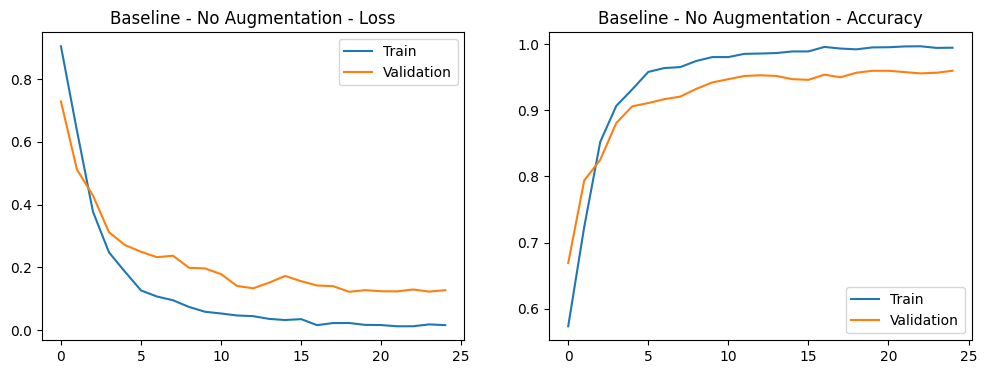


=== CLASSIFICATION REPORT: Baseline - No Augmentation ===
              precision    recall  f1-score   support

           0       0.95      0.92      0.94       172
           1       1.00      1.00      1.00        15
           2       0.96      0.98      0.97       634
           3       0.96      0.95      0.95       459

    accuracy                           0.96      1280
   macro avg       0.97      0.96      0.97      1280
weighted avg       0.96      0.96      0.96      1280



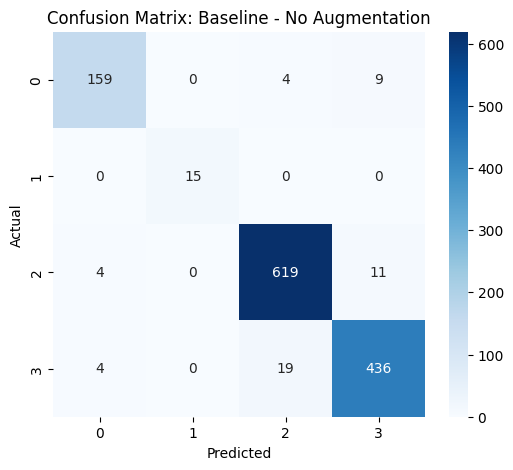


STARTING EXPERIMENT: Experiment - With Augmentation
Epoch 01/25 | Train Loss: 0.9527 Acc: 0.5581 | Val Loss: 0.8624 Acc: 0.5576
Epoch 02/25 | Train Loss: 0.7916 Acc: 0.6375 | Val Loss: 0.7269 Acc: 0.6631
Epoch 03/25 | Train Loss: 0.6784 Acc: 0.6958 | Val Loss: 0.6149 Acc: 0.7275
Epoch 04/25 | Train Loss: 0.5751 Acc: 0.7554 | Val Loss: 0.5078 Acc: 0.7754
Epoch 05/25 | Train Loss: 0.4824 Acc: 0.8020 | Val Loss: 0.4348 Acc: 0.8398
Epoch 06/25 | Train Loss: 0.3980 Acc: 0.8391 | Val Loss: 0.3479 Acc: 0.8623
Epoch 07/25 | Train Loss: 0.3282 Acc: 0.8730 | Val Loss: 0.3033 Acc: 0.8867
Epoch 08/25 | Train Loss: 0.2767 Acc: 0.8909 | Val Loss: 0.2517 Acc: 0.9053
Epoch 09/25 | Train Loss: 0.2536 Acc: 0.8999 | Val Loss: 0.2300 Acc: 0.9160
Epoch 10/25 | Train Loss: 0.2138 Acc: 0.9187 | Val Loss: 0.1892 Acc: 0.9316
Epoch 11/25 | Train Loss: 0.1812 Acc: 0.9304 | Val Loss: 0.2530 Acc: 0.9092
Epoch 12/25 | Train Loss: 0.1623 Acc: 0.9404 | Val Loss: 0.1469 Acc: 0.9492
Epoch 13/25 | Train Loss: 0.1376 Ac

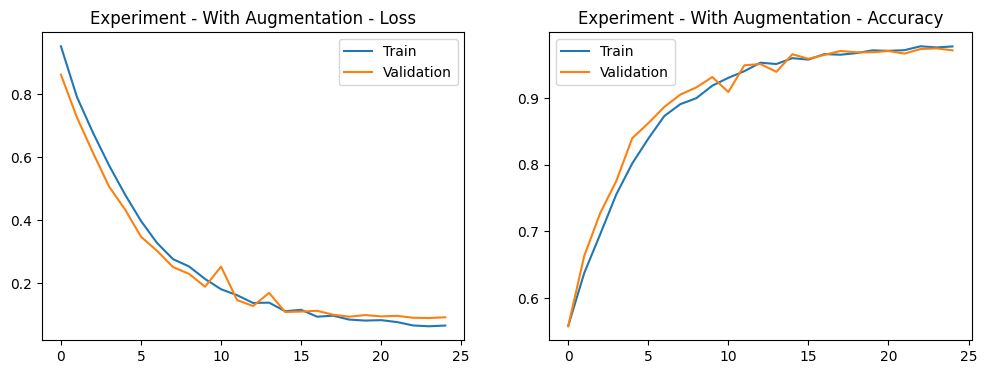


=== CLASSIFICATION REPORT: Experiment - With Augmentation ===
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       172
           1       1.00      1.00      1.00        15
           2       0.99      0.96      0.98       634
           3       0.95      0.98      0.96       459

    accuracy                           0.97      1280
   macro avg       0.98      0.98      0.98      1280
weighted avg       0.97      0.97      0.97      1280



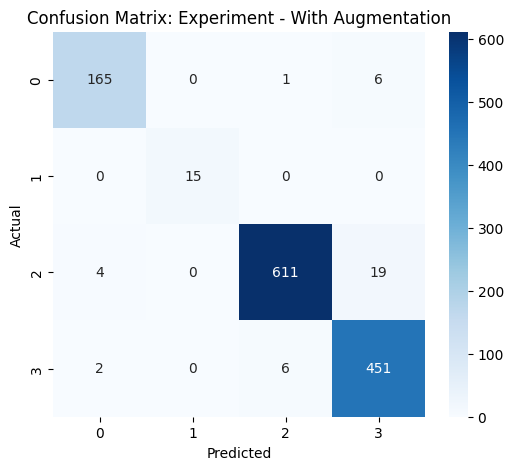

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CONFIG & SETUP
# ==========================================
CONFIG = {
    "lr": 1e-4,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"] # 5120 data
test_data = hf_dataset["test"]      # 1280 data

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

train_labels = np.array(train_data["label"])

# ==========================================
# 3. WEIGHTED SAMPLER (IMBALANCE)
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1. / class_counts
sample_weights = class_weights[train_labels]

# ==========================================
# 4. DATASET WRAPPER
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

# ==========================================
# 5. DEFINE TRANSFORMS (AUG & NO AUG)
# ==========================================
# Transformasi dasar untuk Validasi, Test, dan eksperimen Non-Augmentasi
base_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Transformasi dengan Augmentasi
aug_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==========================================
# 6. EXPERIMENT FUNCTION (TANPA WEIGHTED SAMPLER)
# ==========================================
def run_experiment(experiment_name, train_transform):
    print(f"\n{'='*50}")
    print(f"STARTING EXPERIMENT: {experiment_name}")
    print(f"{'='*50}")

    # --- Setup DataLoaders ---
    train_ds = AlzheimerDataset(train_data, train_transform)
    val_ds   = AlzheimerDataset(val_data, base_transform)
    test_ds  = AlzheimerDataset(test_data, base_transform)

    # PERUBAHAN DISINI: sampler=sampler dihapus, diganti dengan shuffle=True
    train_loader = DataLoader(
        train_ds,
        batch_size=CONFIG["batch_size"],
        shuffle=True,
        num_workers=CONFIG["num_workers"]
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=CONFIG["batch_size"],
        shuffle=False,
        num_workers=CONFIG["num_workers"]
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=CONFIG["batch_size"],
        shuffle=False,
        num_workers=CONFIG["num_workers"]
    )

    # --- Setup Model ---
    model = efficientnet_b2(weights=EfficientNet_B2_Weights.DEFAULT)
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-4:].parameters():
        param.requires_grad = True

    num_classes = len(np.unique(train_labels))
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(1408, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )
    model = model.to(device)

    # --- Optimizers & Schedulers ---
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

    # --- Training Loop ---
    train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []
    best_model = copy.deepcopy(model.state_dict())
    best_loss = float("inf")
    counter = 0

    for epoch in range(CONFIG["epochs"]):
        # Train
        model.train()
        train_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss /= total
        train_acc = correct / total
        scheduler.step()

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        print(f"Epoch {epoch+1:02d}/{CONFIG['epochs']} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        # Early Stopping
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= CONFIG["patience"]:
                print("-> Early stopping triggered!")
                break

    # --- Load Best Model & Test ---
    print(f"\nLoading best model for {experiment_name} testing (from memory)...")
    model.load_state_dict(best_model)

    model.eval()
    all_probs, all_labels, all_preds = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())

    # --- Plotting & Metrics ---
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Validation")
    plt.title(f"{experiment_name} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label="Train")
    plt.plot(val_accuracies, label="Validation")
    plt.title(f"{experiment_name} - Accuracy")
    plt.legend()
    plt.show()

    print(f"\n=== CLASSIFICATION REPORT: {experiment_name} ===")
    print(classification_report(all_labels, all_preds))

    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix: {experiment_name}")
    plt.show()

# ==========================================
# 7. RUN PIPELINES
# ==========================================
# Eksperimen 1: Tanpa Augmentasi
run_experiment(
    experiment_name="Baseline - No Augmentation",
    train_transform=base_transform
)

# Eksperimen 2: Dengan Augmentasi
run_experiment(
    experiment_name="Experiment - With Augmentation",
    train_transform=aug_transform
)

Device: cuda
Loading dataset...
Train: 4096 | Val: 1024 | Test: 1280
Class Weights Tensor: tensor([0.2419, 3.5916, 0.0682, 0.0983], device='cuda:0')

STARTING EXPERIMENT: Baseline - No Augmentation (Class Weight Loss)
Epoch 01/25 | Train Loss: 1.1135 Acc: 0.5107 | Val Loss: 0.8618 Acc: 0.5928
Epoch 02/25 | Train Loss: 0.7622 Acc: 0.6296 | Val Loss: 0.6140 Acc: 0.6777
Epoch 03/25 | Train Loss: 0.5413 Acc: 0.7397 | Val Loss: 0.4589 Acc: 0.8057
Epoch 04/25 | Train Loss: 0.3780 Acc: 0.8337 | Val Loss: 0.3711 Acc: 0.8438
Epoch 05/25 | Train Loss: 0.2675 Acc: 0.8757 | Val Loss: 0.3136 Acc: 0.8848
Epoch 06/25 | Train Loss: 0.1839 Acc: 0.9219 | Val Loss: 0.3149 Acc: 0.8789
Epoch 07/25 | Train Loss: 0.1611 Acc: 0.9353 | Val Loss: 0.2684 Acc: 0.9111
Epoch 08/25 | Train Loss: 0.1324 Acc: 0.9426 | Val Loss: 0.2889 Acc: 0.9219
Epoch 09/25 | Train Loss: 0.1005 Acc: 0.9548 | Val Loss: 0.2585 Acc: 0.9229
Epoch 10/25 | Train Loss: 0.0893 Acc: 0.9622 | Val Loss: 0.2205 Acc: 0.9189
Epoch 11/25 | Train Lo

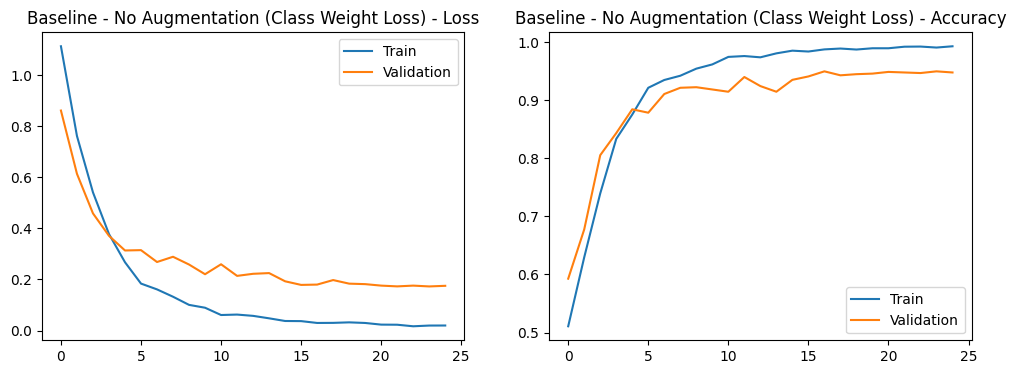


=== CLASSIFICATION REPORT: Baseline - No Augmentation (Class Weight Loss) ===
              precision    recall  f1-score   support

           0       0.92      0.93      0.92       172
           1       1.00      1.00      1.00        15
           2       0.97      0.97      0.97       634
           3       0.96      0.96      0.96       459

    accuracy                           0.96      1280
   macro avg       0.96      0.96      0.96      1280
weighted avg       0.96      0.96      0.96      1280



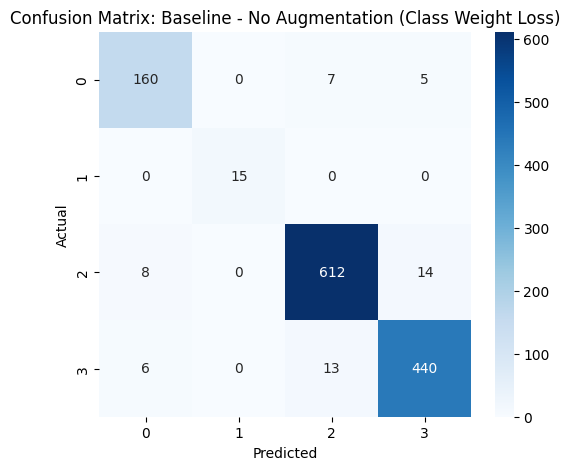


STARTING EXPERIMENT: Experiment - With Augmentation (Class Weight Loss)
Epoch 01/25 | Train Loss: 1.1977 Acc: 0.4912 | Val Loss: 0.9886 Acc: 0.5469
Epoch 02/25 | Train Loss: 0.9461 Acc: 0.5518 | Val Loss: 0.8086 Acc: 0.6094
Epoch 03/25 | Train Loss: 0.8074 Acc: 0.6030 | Val Loss: 0.6875 Acc: 0.6523
Epoch 04/25 | Train Loss: 0.7405 Acc: 0.6392 | Val Loss: 0.6513 Acc: 0.6973
Epoch 05/25 | Train Loss: 0.6270 Acc: 0.6963 | Val Loss: 0.5345 Acc: 0.7373
Epoch 06/25 | Train Loss: 0.6029 Acc: 0.7195 | Val Loss: 0.5625 Acc: 0.7656
Epoch 07/25 | Train Loss: 0.4923 Acc: 0.7551 | Val Loss: 0.4206 Acc: 0.7920
Epoch 08/25 | Train Loss: 0.4251 Acc: 0.7932 | Val Loss: 0.3895 Acc: 0.8213
Epoch 09/25 | Train Loss: 0.3781 Acc: 0.8193 | Val Loss: 0.3514 Acc: 0.8525
Epoch 10/25 | Train Loss: 0.3528 Acc: 0.8391 | Val Loss: 0.2946 Acc: 0.8652
Epoch 11/25 | Train Loss: 0.2762 Acc: 0.8650 | Val Loss: 0.3391 Acc: 0.8232
Epoch 12/25 | Train Loss: 0.2650 Acc: 0.8762 | Val Loss: 0.2284 Acc: 0.9082
Epoch 13/25 | T

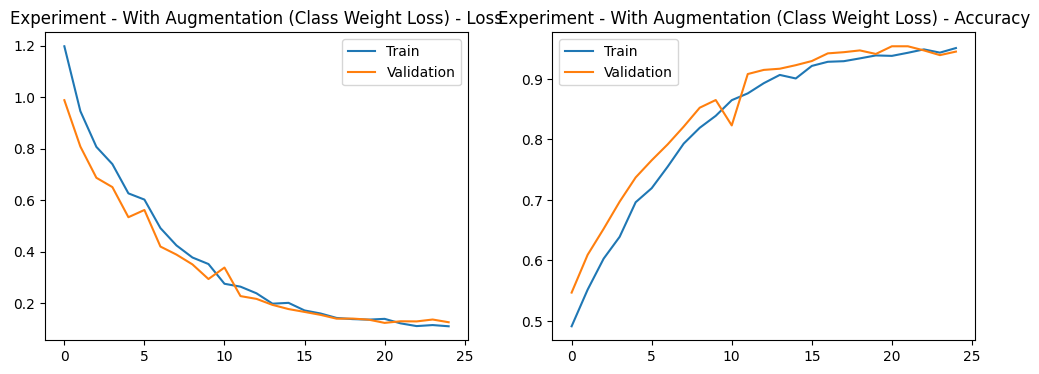


=== CLASSIFICATION REPORT: Experiment - With Augmentation (Class Weight Loss) ===
              precision    recall  f1-score   support

           0       0.94      0.93      0.94       172
           1       1.00      1.00      1.00        15
           2       0.97      0.94      0.95       634
           3       0.91      0.95      0.93       459

    accuracy                           0.94      1280
   macro avg       0.95      0.95      0.95      1280
weighted avg       0.94      0.94      0.94      1280



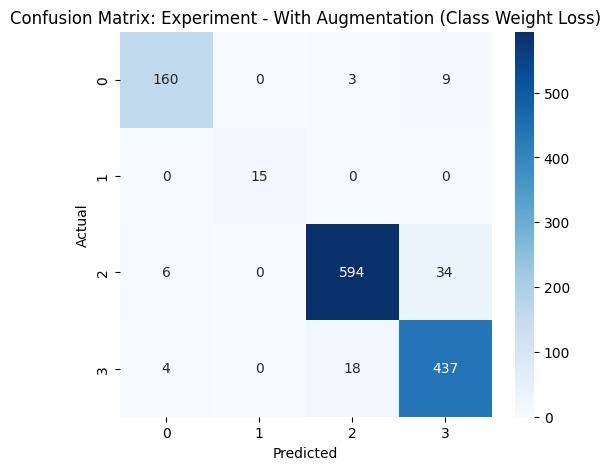

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import numpy as np
import copy
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CONFIG & SETUP
# ==========================================
CONFIG = {
    "lr": 1e-4,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"] # 5120 data
test_data = hf_dataset["test"]      # 1280 data

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

train_labels = np.array(train_data["label"])

# ==========================================
# 3. CLASS WEIGHTS UNTUK LOSS FUNCTION
# ==========================================
# Menghitung bobot invers dari frekuensi kelas
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts

# Opsional: Normalisasi bobot agar tidak terlalu besar/kecil (best practice)
class_weights = class_weights / class_weights.sum() * len(class_counts)

# Konversi ke Tensor dan pindahkan ke device (GPU/CPU)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"Class Weights Tensor: {class_weights_tensor}")

# ==========================================
# 4. DATASET WRAPPER
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

# ==========================================
# 5. DEFINE TRANSFORMS (AUG & NO AUG)
# ==========================================
base_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

aug_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==========================================
# 6. EXPERIMENT FUNCTION (WITH CLASS WEIGHT LOSS)
# ==========================================
def run_experiment(experiment_name, train_transform):
    print(f"\n{'='*50}")
    print(f"STARTING EXPERIMENT: {experiment_name}")
    print(f"{'='*50}")

    # --- Setup DataLoaders (Normal Shuffle) ---
    train_ds = AlzheimerDataset(train_data, train_transform)
    val_ds   = AlzheimerDataset(val_data, base_transform)
    test_ds  = AlzheimerDataset(test_data, base_transform)

    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])
    val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
    test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

    # --- Setup Model ---
    model = efficientnet_b2(weights=EfficientNet_B2_Weights.DEFAULT)
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-4:].parameters():
        param.requires_grad = True

    num_classes = len(np.unique(train_labels))
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(1408, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )
    model = model.to(device)

    # --- Optimizers, Loss (with weights), & Schedulers ---
    # PERUBAHAN DISINI: Memasukkan tensor bobot ke dalam CrossEntropyLoss
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

    # --- Training Loop ---
    train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []
    best_model = copy.deepcopy(model.state_dict())
    best_loss = float("inf")
    counter = 0

    for epoch in range(CONFIG["epochs"]):
        # Train
        model.train()
        train_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss /= total
        train_acc = correct / total
        scheduler.step()

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        print(f"Epoch {epoch+1:02d}/{CONFIG['epochs']} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        # Early Stopping
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= CONFIG["patience"]:
                print("-> Early stopping triggered!")
                break

    # --- Load Best Model & Test ---
    print(f"\nLoading best model for {experiment_name} testing (from memory)...")
    model.load_state_dict(best_model)

    model.eval()
    all_probs, all_labels, all_preds = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())

    # --- Plotting & Metrics ---
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Validation")
    plt.title(f"{experiment_name} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label="Train")
    plt.plot(val_accuracies, label="Validation")
    plt.title(f"{experiment_name} - Accuracy")
    plt.legend()
    plt.show()

    print(f"\n=== CLASSIFICATION REPORT: {experiment_name} ===")
    print(classification_report(all_labels, all_preds))

    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix: {experiment_name}")
    plt.show()

# ==========================================
# 7. RUN PIPELINES
# ==========================================
# Eksperimen 1: Tanpa Augmentasi (Menggunakan Class Weight Loss)
run_experiment(
    experiment_name="Baseline - No Augmentation (Class Weight Loss)",
    train_transform=base_transform
)

# Eksperimen 2: Dengan Augmentasi (Menggunakan Class Weight Loss)
run_experiment(
    experiment_name="Experiment - With Augmentation (Class Weight Loss)",
    train_transform=aug_transform
)

# AUG + Weighted (ALL SKENARIO)

Device: cuda
Loading dataset...
Train: 4096 | Val: 1024 | Test: 1280

STARTING: S-01 | Opt: Adam | Sched: ReduceLROnPlateau
Epoch 01/25 | LR: 1.00e-04 | Train Loss: 1.3234 Acc: 0.3711 | Val Loss: 1.2460 Acc: 0.5010
Epoch 02/25 | LR: 1.00e-04 | Train Loss: 1.2043 Acc: 0.4658 | Val Loss: 1.1402 Acc: 0.5078
Epoch 03/25 | LR: 1.00e-04 | Train Loss: 1.1358 Acc: 0.4924 | Val Loss: 1.1535 Acc: 0.4854
Epoch 04/25 | LR: 1.00e-04 | Train Loss: 1.0838 Acc: 0.5205 | Val Loss: 1.1310 Acc: 0.4912
Epoch 05/25 | LR: 1.00e-04 | Train Loss: 1.0586 Acc: 0.5249 | Val Loss: 1.0341 Acc: 0.5645
Epoch 06/25 | LR: 1.00e-04 | Train Loss: 1.0303 Acc: 0.5518 | Val Loss: 1.0421 Acc: 0.5430
Epoch 07/25 | LR: 1.00e-04 | Train Loss: 1.0240 Acc: 0.5532 | Val Loss: 1.0496 Acc: 0.5342
Epoch 08/25 | LR: 1.00e-04 | Train Loss: 1.0258 Acc: 0.5435 | Val Loss: 1.0033 Acc: 0.5557
Epoch 09/25 | LR: 1.00e-04 | Train Loss: 1.0151 Acc: 0.5520 | Val Loss: 0.9970 Acc: 0.5664
Epoch 10/25 | LR: 1.00e-04 | Train Loss: 1.0018 Acc: 0.56

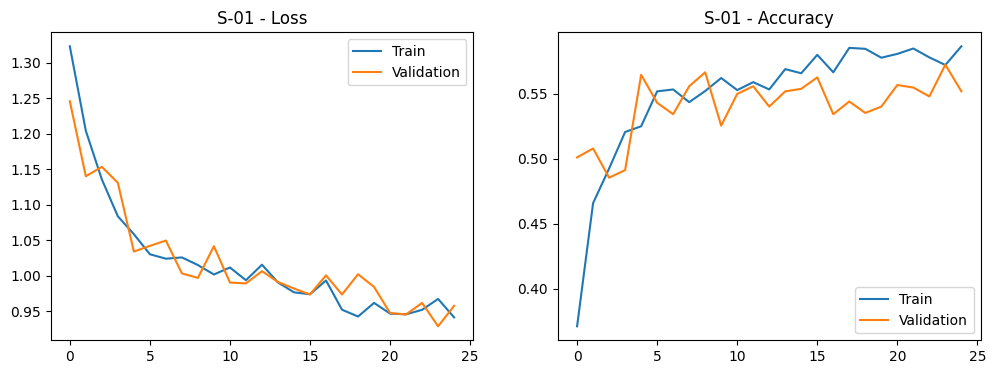


=== CLASSIFICATION REPORT: S-01 ===
              precision    recall  f1-score   support

           0       0.34      0.44      0.39       172
           1       0.15      1.00      0.25        15
           2       0.69      0.69      0.69       634
           3       0.55      0.38      0.45       459

    accuracy                           0.55      1280
   macro avg       0.43      0.63      0.44      1280
weighted avg       0.58      0.55      0.56      1280


STARTING: S-02 | Opt: Adam | Sched: CosineAnnealingLR
Epoch 01/25 | LR: 9.96e-05 | Train Loss: 1.3180 Acc: 0.3821 | Val Loss: 1.2444 Acc: 0.4971
Epoch 02/25 | LR: 9.84e-05 | Train Loss: 1.1837 Acc: 0.4839 | Val Loss: 1.1231 Acc: 0.5459
Epoch 03/25 | LR: 9.65e-05 | Train Loss: 1.1163 Acc: 0.5044 | Val Loss: 1.0844 Acc: 0.5420
Epoch 04/25 | LR: 9.38e-05 | Train Loss: 1.0869 Acc: 0.5188 | Val Loss: 1.0961 Acc: 0.5244
Epoch 05/25 | LR: 9.05e-05 | Train Loss: 1.0756 Acc: 0.5237 | Val Loss: 1.0858 Acc: 0.5244
Epoch 06/25 | LR: 

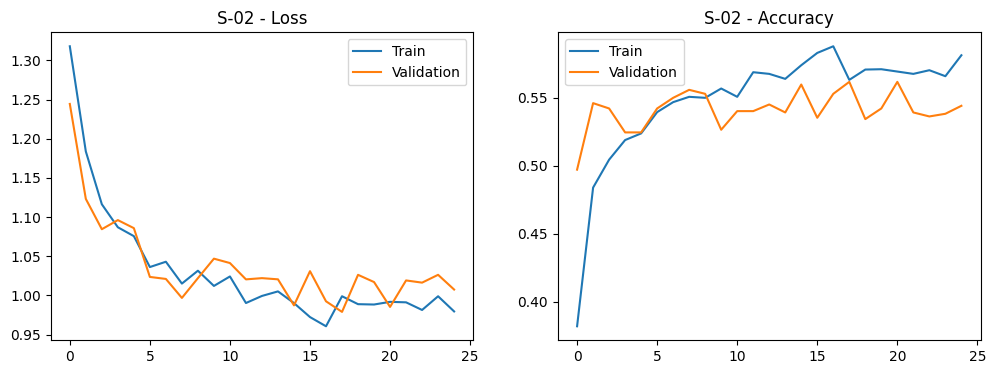


=== CLASSIFICATION REPORT: S-02 ===
              precision    recall  f1-score   support

           0       0.33      0.47      0.39       172
           1       0.13      1.00      0.23        15
           2       0.70      0.66      0.68       634
           3       0.52      0.37      0.43       459

    accuracy                           0.53      1280
   macro avg       0.42      0.62      0.43      1280
weighted avg       0.58      0.53      0.55      1280


STARTING: S-03 | Opt: AdamW | Sched: ReduceLROnPlateau
Epoch 01/25 | LR: 1.00e-04 | Train Loss: 1.3045 Acc: 0.4062 | Val Loss: 1.2147 Acc: 0.4912
Epoch 02/25 | LR: 1.00e-04 | Train Loss: 1.1795 Acc: 0.4878 | Val Loss: 1.1350 Acc: 0.5117
Epoch 03/25 | LR: 1.00e-04 | Train Loss: 1.1119 Acc: 0.5171 | Val Loss: 1.1285 Acc: 0.4902
Epoch 04/25 | LR: 1.00e-04 | Train Loss: 1.0705 Acc: 0.5298 | Val Loss: 1.0693 Acc: 0.5303
Epoch 05/25 | LR: 1.00e-04 | Train Loss: 1.0827 Acc: 0.5200 | Val Loss: 1.0737 Acc: 0.5195
Epoch 06/25 | LR:

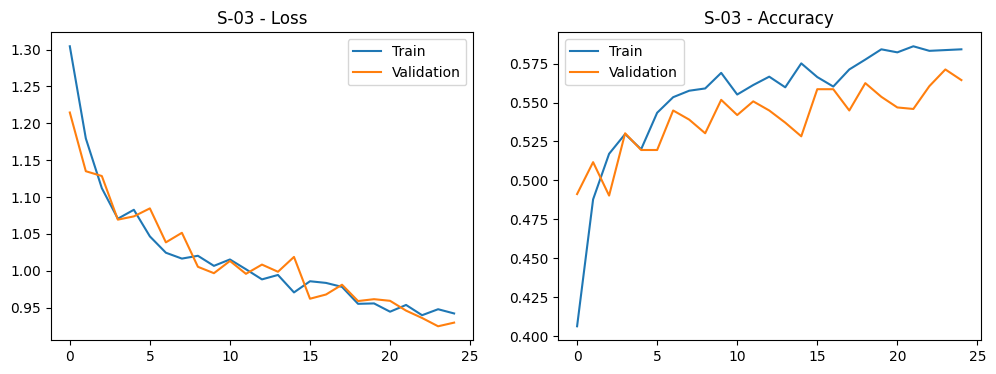


=== CLASSIFICATION REPORT: S-03 ===
              precision    recall  f1-score   support

           0       0.36      0.51      0.42       172
           1       0.16      1.00      0.27        15
           2       0.68      0.70      0.69       634
           3       0.56      0.36      0.44       459

    accuracy                           0.56      1280
   macro avg       0.44      0.64      0.46      1280
weighted avg       0.59      0.56      0.56      1280



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CONFIG & SETUP
# ==========================================
CONFIG = {
    "lr": 1e-4,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"] # 5120 data
test_data = hf_dataset["test"]      # 1280 data

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

train_labels = np.array(train_data["label"])

# ==========================================
# 3. WEIGHTED SAMPLER (IMBALANCE)
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1. / class_counts
sample_weights = class_weights[train_labels]

# ==========================================
# 4. DATASET WRAPPER
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

# ==========================================
# 5. DEFINE TRANSFORMS (AUG & NO AUG)
# ==========================================
base_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

aug_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==========================================
# 6. EXPERIMENT FUNCTION (ALL LAYERS FROZEN)
# ==========================================
def run_experiment(experiment_name, train_transform, opt_type, sched_type):
    print(f"\n{'='*60}")
    print(f"STARTING: {experiment_name} | Opt: {opt_type} | Sched: {sched_type}")
    print(f"{'='*60}")

    # --- Setup DataLoaders (Menggunakan WeightedRandomSampler) ---
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )

    train_ds = AlzheimerDataset(train_data, train_transform)
    val_ds   = AlzheimerDataset(val_data, base_transform)
    test_ds  = AlzheimerDataset(test_data, base_transform)

    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, num_workers=CONFIG["num_workers"])
    val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
    test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

    # --- Setup Model ---
    model = efficientnet_b2(weights=EfficientNet_B2_Weights.DEFAULT)

    # PERUBAHAN DI SINI: Freeze SEMUA layer, tidak ada yang di-unfreeze
    for param in model.features.parameters():
        param.requires_grad = False

    num_classes = len(np.unique(train_labels))
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(1408, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )
    model = model.to(device)

    # --- Loss ---
    criterion = nn.CrossEntropyLoss()

    # --- Dynamic Optimizer ---
    # filter(lambda p: p.requires_grad) otomatis HANYA mengambil model.classifier karena fitur lainnya sudah False
    trainable_params = filter(lambda p: p.requires_grad, model.parameters())
    if opt_type == 'Adam':
        optimizer = optim.Adam(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'AdamW':
        optimizer = optim.AdamW(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'SGD':
        optimizer = optim.SGD(trainable_params, lr=CONFIG["lr"], momentum=0.9)
    else:
        raise ValueError("Optimizer tidak dikenali!")

    # --- Dynamic Scheduler ---
    if sched_type == 'CosineAnnealingLR':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])
    elif sched_type == 'ReduceLROnPlateau':
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
    else:
        raise ValueError("Scheduler tidak dikenali!")

    # --- Training Loop ---
    train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []
    best_model = copy.deepcopy(model.state_dict())
    best_loss = float("inf")
    counter = 0

    for epoch in range(CONFIG["epochs"]):
        # ===== Train =====
        model.train()
        train_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss /= total
        train_acc = correct / total

        # CosineAnnealingLR di-step setiap akhir epoch training (tidak butuh val_loss)
        if sched_type == 'CosineAnnealingLR':
            scheduler.step()

        # ===== Validation =====
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        # ReduceLROnPlateau di-step setiap akhir epoch validation (butuh val_loss)
        if sched_type == 'ReduceLROnPlateau':
            scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:02d}/{CONFIG['epochs']} | LR: {current_lr:.2e} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        # ===== Early Stopping =====
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= CONFIG["patience"]:
                print("-> Early stopping triggered!")
                break

    # --- Load Best Model & Test ---
    print(f"\nLoading best model for testing...")
    model.load_state_dict(best_model)

    model.eval()
    all_probs, all_labels, all_preds = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())

    # --- Plotting & Metrics ---
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Validation")
    plt.title(f"{experiment_name} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label="Train")
    plt.plot(val_accuracies, label="Validation")
    plt.title(f"{experiment_name} - Accuracy")
    plt.legend()
    plt.show()

    print(f"\n=== CLASSIFICATION REPORT: {experiment_name} ===")
    print(classification_report(all_labels, all_preds))

# ==========================================
# 7. RUN PIPELINES (SCENARIOS S-01 to S-06)
# ==========================================
# Menggunakan Augmentasi dan Weighted Random Sampler untuk semua skenario

scenarios = [
    {"name": "S-01", "opt": "Adam",  "sched": "ReduceLROnPlateau"},
    {"name": "S-02", "opt": "Adam",  "sched": "CosineAnnealingLR"},
    {"name": "S-03", "opt": "AdamW", "sched": "ReduceLROnPlateau"},
    # {"name": "S-04", "opt": "AdamW", "sched": "CosineAnnealingLR"},
    # {"name": "S-05", "opt": "SGD",   "sched": "ReduceLROnPlateau"},
    # {"name": "S-06", "opt": "SGD",   "sched": "CosineAnnealingLR"}
]

for scenario in scenarios:
    run_experiment(
        experiment_name=scenario["name"],
        train_transform=aug_transform,
        opt_type=scenario["opt"],
        sched_type=scenario["sched"]
    )

Device: cuda
Loading dataset...
Train: 4096 | Val: 1024 | Test: 1280

STARTING: S-04 | Opt: AdamW | Sched: CosineAnnealingLR
Epoch 01/25 | LR: 9.96e-05 | Train Loss: 1.3108 Acc: 0.4026 | Val Loss: 1.2445 Acc: 0.4785
Epoch 02/25 | LR: 9.84e-05 | Train Loss: 1.1864 Acc: 0.4807 | Val Loss: 1.1664 Acc: 0.5029
Epoch 03/25 | LR: 9.65e-05 | Train Loss: 1.1276 Acc: 0.4980 | Val Loss: 1.1297 Acc: 0.5127
Epoch 04/25 | LR: 9.38e-05 | Train Loss: 1.0770 Acc: 0.5298 | Val Loss: 1.0865 Acc: 0.5156
Epoch 05/25 | LR: 9.05e-05 | Train Loss: 1.0719 Acc: 0.5264 | Val Loss: 1.0617 Acc: 0.5352
Epoch 06/25 | LR: 8.64e-05 | Train Loss: 1.0316 Acc: 0.5586 | Val Loss: 1.0191 Acc: 0.5410
Epoch 07/25 | LR: 8.19e-05 | Train Loss: 1.0371 Acc: 0.5403 | Val Loss: 1.0199 Acc: 0.5391
Epoch 08/25 | LR: 7.68e-05 | Train Loss: 1.0234 Acc: 0.5630 | Val Loss: 0.9872 Acc: 0.5693
Epoch 09/25 | LR: 7.13e-05 | Train Loss: 1.0282 Acc: 0.5442 | Val Loss: 1.0248 Acc: 0.5498
Epoch 10/25 | LR: 6.55e-05 | Train Loss: 1.0131 Acc: 0.5

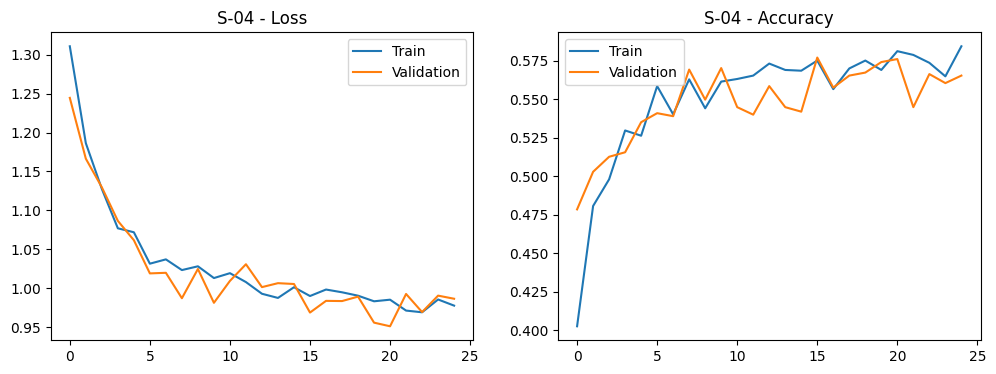


=== CLASSIFICATION REPORT: S-04 ===
              precision    recall  f1-score   support

           0       0.36      0.47      0.41       172
           1       0.18      1.00      0.30        15
           2       0.67      0.72      0.70       634
           3       0.57      0.36      0.44       459

    accuracy                           0.56      1280
   macro avg       0.44      0.64      0.46      1280
weighted avg       0.59      0.56      0.56      1280


STARTING: S-05 | Opt: SGD | Sched: ReduceLROnPlateau
Epoch 01/25 | LR: 1.00e-04 | Train Loss: 1.3897 Acc: 0.2661 | Val Loss: 1.3858 Acc: 0.2295
Epoch 02/25 | LR: 1.00e-04 | Train Loss: 1.3826 Acc: 0.2766 | Val Loss: 1.3818 Acc: 0.2812
Epoch 03/25 | LR: 1.00e-04 | Train Loss: 1.3794 Acc: 0.2837 | Val Loss: 1.3745 Acc: 0.3633
Epoch 04/25 | LR: 1.00e-04 | Train Loss: 1.3752 Acc: 0.3035 | Val Loss: 1.3649 Acc: 0.4346
Epoch 05/25 | LR: 1.00e-04 | Train Loss: 1.3639 Acc: 0.3345 | Val Loss: 1.3592 Acc: 0.4619
Epoch 06/25 | LR: 1

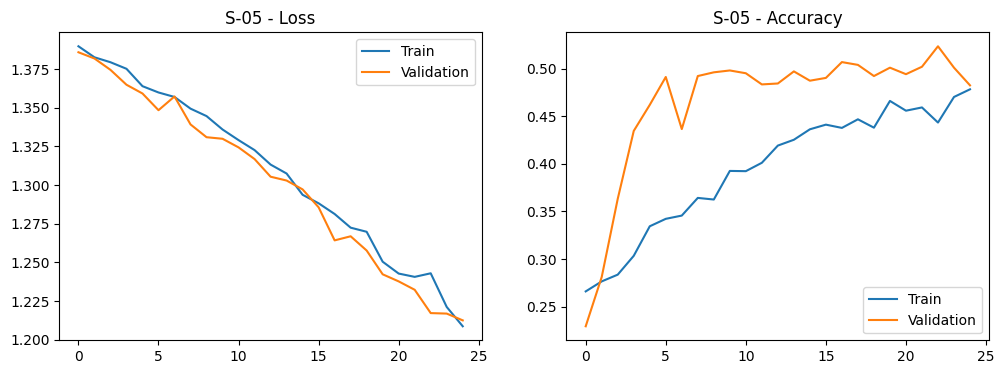


=== CLASSIFICATION REPORT: S-05 ===
              precision    recall  f1-score   support

           0       0.32      0.33      0.32       172
           1       0.06      1.00      0.11        15
           2       0.64      0.76      0.69       634
           3       0.55      0.12      0.20       459

    accuracy                           0.47      1280
   macro avg       0.39      0.55      0.33      1280
weighted avg       0.56      0.47      0.46      1280


STARTING: S-06 | Opt: SGD | Sched: CosineAnnealingLR
Epoch 01/25 | LR: 9.96e-05 | Train Loss: 1.3913 Acc: 0.2595 | Val Loss: 1.3817 Acc: 0.3047
Epoch 02/25 | LR: 9.84e-05 | Train Loss: 1.3850 Acc: 0.2703 | Val Loss: 1.3779 Acc: 0.3545
Epoch 03/25 | LR: 9.65e-05 | Train Loss: 1.3743 Acc: 0.3005 | Val Loss: 1.3785 Acc: 0.3213
Epoch 04/25 | LR: 9.38e-05 | Train Loss: 1.3680 Acc: 0.3181 | Val Loss: 1.3738 Acc: 0.3486
Epoch 05/25 | LR: 9.05e-05 | Train Loss: 1.3637 Acc: 0.3342 | Val Loss: 1.3671 Acc: 0.4004
Epoch 06/25 | LR: 8

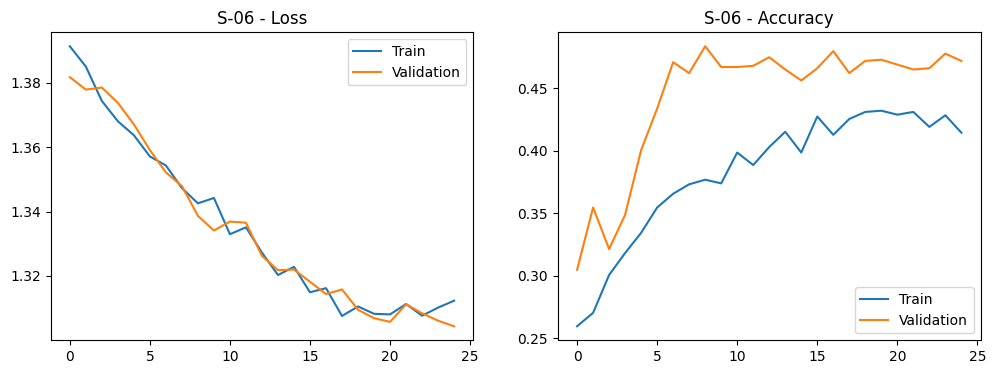


=== CLASSIFICATION REPORT: S-06 ===
              precision    recall  f1-score   support

           0       0.28      0.25      0.26       172
           1       0.06      0.93      0.11        15
           2       0.62      0.71      0.66       634
           3       0.43      0.14      0.21       459

    accuracy                           0.45      1280
   macro avg       0.35      0.51      0.31      1280
weighted avg       0.50      0.45      0.44      1280



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CONFIG & SETUP
# ==========================================
CONFIG = {
    "lr": 1e-4,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"] # 5120 data
test_data = hf_dataset["test"]      # 1280 data

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

train_labels = np.array(train_data["label"])

# ==========================================
# 3. WEIGHTED SAMPLER (IMBALANCE)
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1. / class_counts
sample_weights = class_weights[train_labels]

# ==========================================
# 4. DATASET WRAPPER
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

# ==========================================
# 5. DEFINE TRANSFORMS (AUG & NO AUG)
# ==========================================
base_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

aug_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==========================================
# 6. EXPERIMENT FUNCTION (ALL LAYERS FROZEN)
# ==========================================
def run_experiment(experiment_name, train_transform, opt_type, sched_type):
    print(f"\n{'='*60}")
    print(f"STARTING: {experiment_name} | Opt: {opt_type} | Sched: {sched_type}")
    print(f"{'='*60}")

    # --- Setup DataLoaders (Menggunakan WeightedRandomSampler) ---
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )

    train_ds = AlzheimerDataset(train_data, train_transform)
    val_ds   = AlzheimerDataset(val_data, base_transform)
    test_ds  = AlzheimerDataset(test_data, base_transform)

    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, num_workers=CONFIG["num_workers"])
    val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
    test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

    # --- Setup Model ---
    model = efficientnet_b2(weights=EfficientNet_B2_Weights.DEFAULT)

    # PERUBAHAN DI SINI: Freeze SEMUA layer, tidak ada yang di-unfreeze
    for param in model.features.parameters():
        param.requires_grad = False

    num_classes = len(np.unique(train_labels))
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(1408, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )
    model = model.to(device)

    # --- Loss ---
    criterion = nn.CrossEntropyLoss()

    # --- Dynamic Optimizer ---
    # filter(lambda p: p.requires_grad) otomatis HANYA mengambil model.classifier karena fitur lainnya sudah False
    trainable_params = filter(lambda p: p.requires_grad, model.parameters())
    if opt_type == 'Adam':
        optimizer = optim.Adam(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'AdamW':
        optimizer = optim.AdamW(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'SGD':
        optimizer = optim.SGD(trainable_params, lr=CONFIG["lr"], momentum=0.9)
    else:
        raise ValueError("Optimizer tidak dikenali!")

    # --- Dynamic Scheduler ---
    if sched_type == 'CosineAnnealingLR':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])
    elif sched_type == 'ReduceLROnPlateau':
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
    else:
        raise ValueError("Scheduler tidak dikenali!")

    # --- Training Loop ---
    train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []
    best_model = copy.deepcopy(model.state_dict())
    best_loss = float("inf")
    counter = 0

    for epoch in range(CONFIG["epochs"]):
        # ===== Train =====
        model.train()
        train_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss /= total
        train_acc = correct / total

        # CosineAnnealingLR di-step setiap akhir epoch training (tidak butuh val_loss)
        if sched_type == 'CosineAnnealingLR':
            scheduler.step()

        # ===== Validation =====
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        # ReduceLROnPlateau di-step setiap akhir epoch validation (butuh val_loss)
        if sched_type == 'ReduceLROnPlateau':
            scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:02d}/{CONFIG['epochs']} | LR: {current_lr:.2e} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        # ===== Early Stopping =====
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= CONFIG["patience"]:
                print("-> Early stopping triggered!")
                break

    # --- Load Best Model & Test ---
    print(f"\nLoading best model for testing...")
    model.load_state_dict(best_model)

    model.eval()
    all_probs, all_labels, all_preds = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())

    # --- Plotting & Metrics ---
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Validation")
    plt.title(f"{experiment_name} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label="Train")
    plt.plot(val_accuracies, label="Validation")
    plt.title(f"{experiment_name} - Accuracy")
    plt.legend()
    plt.show()

    print(f"\n=== CLASSIFICATION REPORT: {experiment_name} ===")
    print(classification_report(all_labels, all_preds))

# ==========================================
# 7. RUN PIPELINES (SCENARIOS S-01 to S-06)
# ==========================================
# Menggunakan Augmentasi dan Weighted Random Sampler untuk semua skenario

scenarios = [
    # {"name": "S-01", "opt": "Adam",  "sched": "ReduceLROnPlateau"},
    # {"name": "S-02", "opt": "Adam",  "sched": "CosineAnnealingLR"},
    # {"name": "S-03", "opt": "AdamW", "sched": "ReduceLROnPlateau"},
    {"name": "S-04", "opt": "AdamW", "sched": "CosineAnnealingLR"},
    {"name": "S-05", "opt": "SGD",   "sched": "ReduceLROnPlateau"},
    {"name": "S-06", "opt": "SGD",   "sched": "CosineAnnealingLR"}
]

for scenario in scenarios:
    run_experiment(
        experiment_name=scenario["name"],
        train_transform=aug_transform,
        opt_type=scenario["opt"],
        sched_type=scenario["sched"]
    )

Device: cuda
Loading dataset...
Train: 4096 | Val: 1024 | Test: 1280

STARTING: S-07 | Opt: Adam | Sched: ReduceLROnPlateau
Epoch 01/25 | LR: 1.00e-04 | Train Loss: 0.9825 Acc: 0.5532 | Val Loss: 0.8164 Acc: 0.5938
Epoch 02/25 | LR: 1.00e-04 | Train Loss: 0.6544 Acc: 0.7134 | Val Loss: 0.7096 Acc: 0.6777
Epoch 03/25 | LR: 1.00e-04 | Train Loss: 0.5701 Acc: 0.7444 | Val Loss: 0.6542 Acc: 0.7139
Epoch 04/25 | LR: 1.00e-04 | Train Loss: 0.4780 Acc: 0.8074 | Val Loss: 0.5196 Acc: 0.7676
Epoch 05/25 | LR: 1.00e-04 | Train Loss: 0.3818 Acc: 0.8469 | Val Loss: 0.4293 Acc: 0.8223
Epoch 06/25 | LR: 1.00e-04 | Train Loss: 0.3329 Acc: 0.8674 | Val Loss: 0.5483 Acc: 0.7773
Epoch 07/25 | LR: 1.00e-04 | Train Loss: 0.2924 Acc: 0.8806 | Val Loss: 0.3847 Acc: 0.8350
Epoch 08/25 | LR: 1.00e-04 | Train Loss: 0.2796 Acc: 0.8901 | Val Loss: 0.3007 Acc: 0.8721
Epoch 09/25 | LR: 1.00e-04 | Train Loss: 0.2172 Acc: 0.9128 | Val Loss: 0.2935 Acc: 0.8789
Epoch 10/25 | LR: 1.00e-04 | Train Loss: 0.1972 Acc: 0.92

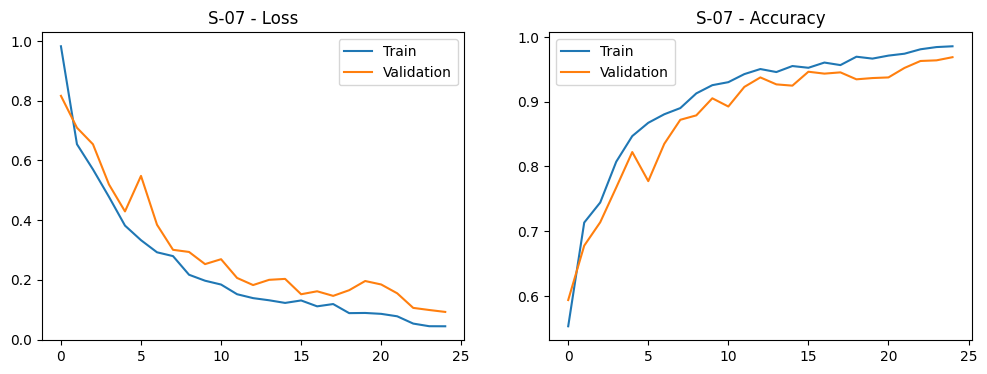


=== CLASSIFICATION REPORT: S-07 ===
              precision    recall  f1-score   support

           0       0.99      0.96      0.98       172
           1       1.00      1.00      1.00        15
           2       0.98      0.97      0.98       634
           3       0.95      0.97      0.96       459

    accuracy                           0.97      1280
   macro avg       0.98      0.98      0.98      1280
weighted avg       0.97      0.97      0.97      1280


STARTING: S-08 | Opt: Adam | Sched: CosineAnnealingLR
Epoch 01/25 | LR: 9.96e-05 | Train Loss: 1.0124 Acc: 0.5337 | Val Loss: 0.8398 Acc: 0.6055
Epoch 02/25 | LR: 9.84e-05 | Train Loss: 0.6509 Acc: 0.7119 | Val Loss: 0.6721 Acc: 0.6934
Epoch 03/25 | LR: 9.65e-05 | Train Loss: 0.5474 Acc: 0.7676 | Val Loss: 0.5962 Acc: 0.7373
Epoch 04/25 | LR: 9.38e-05 | Train Loss: 0.4591 Acc: 0.8035 | Val Loss: 0.4810 Acc: 0.7959
Epoch 05/25 | LR: 9.05e-05 | Train Loss: 0.3701 Acc: 0.8530 | Val Loss: 0.4582 Acc: 0.8037
Epoch 06/25 | LR: 

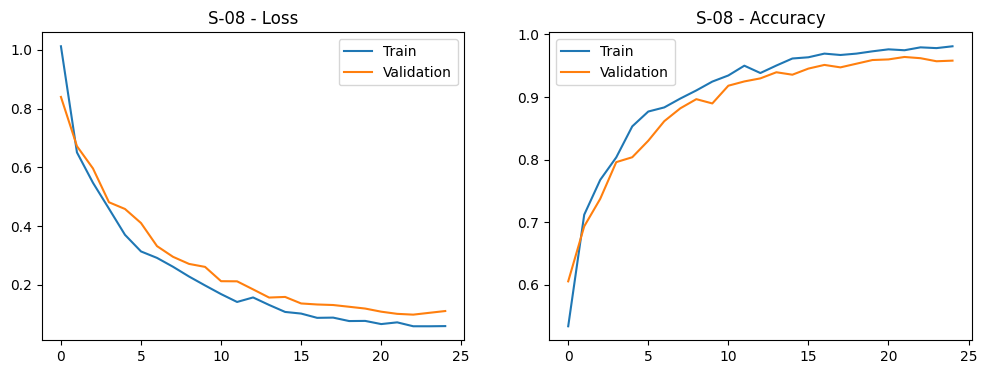


=== CLASSIFICATION REPORT: S-08 ===
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       172
           1       1.00      1.00      1.00        15
           2       0.97      0.95      0.96       634
           3       0.94      0.97      0.95       459

    accuracy                           0.96      1280
   macro avg       0.97      0.97      0.97      1280
weighted avg       0.96      0.96      0.96      1280


STARTING: S-09 | Opt: AdamW | Sched: ReduceLROnPlateau
Epoch 01/25 | LR: 1.00e-04 | Train Loss: 0.9794 Acc: 0.5588 | Val Loss: 0.8327 Acc: 0.6143
Epoch 02/25 | LR: 1.00e-04 | Train Loss: 0.6579 Acc: 0.7039 | Val Loss: 0.8087 Acc: 0.6191
Epoch 03/25 | LR: 1.00e-04 | Train Loss: 0.5824 Acc: 0.7512 | Val Loss: 0.6287 Acc: 0.7100
Epoch 04/25 | LR: 1.00e-04 | Train Loss: 0.4741 Acc: 0.7957 | Val Loss: 0.5831 Acc: 0.7354
Epoch 05/25 | LR: 1.00e-04 | Train Loss: 0.4010 Acc: 0.8408 | Val Loss: 0.5050 Acc: 0.7803
Epoch 06/25 | LR:

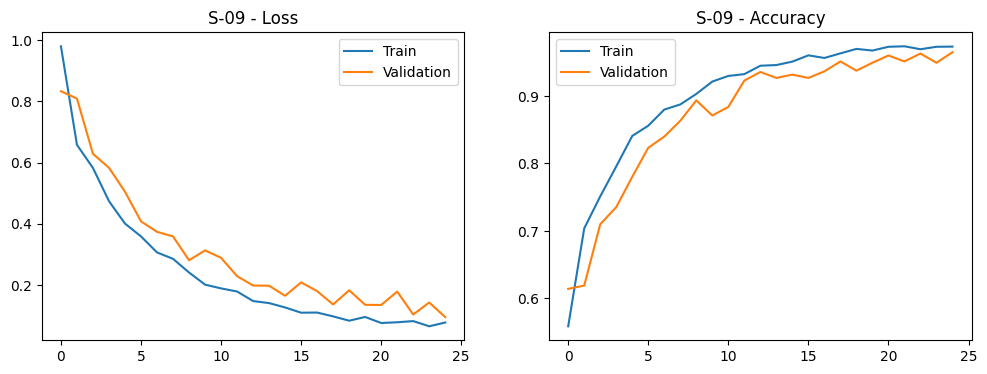


=== CLASSIFICATION REPORT: S-09 ===
              precision    recall  f1-score   support

           0       0.96      0.95      0.95       172
           1       1.00      0.93      0.97        15
           2       0.98      0.97      0.97       634
           3       0.94      0.97      0.96       459

    accuracy                           0.96      1280
   macro avg       0.97      0.95      0.96      1280
weighted avg       0.96      0.96      0.96      1280



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CONFIG & SETUP
# ==========================================
CONFIG = {
    "lr": 1e-4,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"] # 5120 data
test_data = hf_dataset["test"]      # 1280 data

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

train_labels = np.array(train_data["label"])

# ==========================================
# 3. WEIGHTED SAMPLER (IMBALANCE)
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1. / class_counts
sample_weights = class_weights[train_labels]

# ==========================================
# 4. DATASET WRAPPER
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

# ==========================================
# 5. DEFINE TRANSFORMS (AUG & NO AUG)
# ==========================================
base_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

aug_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==========================================
# 6. EXPERIMENT FUNCTION (UNFREEZE LAST LAYERS)
# ==========================================
def run_experiment(experiment_name, train_transform, opt_type, sched_type):
    print(f"\n{'='*60}")
    print(f"STARTING: {experiment_name} | Opt: {opt_type} | Sched: {sched_type}")
    print(f"{'='*60}")

    # --- Setup DataLoaders (WeightedRandomSampler) ---
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )

    train_ds = AlzheimerDataset(train_data, train_transform)
    val_ds   = AlzheimerDataset(val_data, base_transform)
    test_ds  = AlzheimerDataset(test_data, base_transform)

    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, num_workers=CONFIG["num_workers"])
    val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
    test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

    # --- Setup Model ---
    model = efficientnet_b2(weights=EfficientNet_B2_Weights.DEFAULT)

    # 1. Freeze semua layer features terlebih dahulu
    for param in model.features.parameters():
        param.requires_grad = False

    # 2. PERUBAHAN DI SINI: Unfreeze 4 layer terakhir di block features
    for param in model.features[-4:].parameters():
        param.requires_grad = True

    num_classes = len(np.unique(train_labels))
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(1408, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )
    model = model.to(device)

    # --- Loss ---
    criterion = nn.CrossEntropyLoss()

    # --- Dynamic Optimizer ---
    # trainable_params sekarang mencakup model.classifier DAN model.features[-4:]
    trainable_params = filter(lambda p: p.requires_grad, model.parameters())

    if opt_type == 'Adam':
        optimizer = optim.Adam(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'AdamW':
        optimizer = optim.AdamW(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'SGD':
        optimizer = optim.SGD(trainable_params, lr=CONFIG["lr"], momentum=0.9)
    else:
        raise ValueError("Optimizer tidak dikenali!")

    # --- Dynamic Scheduler ---
    if sched_type == 'CosineAnnealingLR':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])
    elif sched_type == 'ReduceLROnPlateau':
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
    else:
        raise ValueError("Scheduler tidak dikenali!")

    # --- Training Loop ---
    train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []
    best_model = copy.deepcopy(model.state_dict())
    best_loss = float("inf")
    counter = 0

    for epoch in range(CONFIG["epochs"]):
        # ===== Train =====
        model.train()
        train_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss /= total
        train_acc = correct / total

        # CosineAnnealingLR di-step setiap akhir epoch training
        if sched_type == 'CosineAnnealingLR':
            scheduler.step()

        # ===== Validation =====
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        # ReduceLROnPlateau di-step setiap akhir epoch validation
        if sched_type == 'ReduceLROnPlateau':
            scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:02d}/{CONFIG['epochs']} | LR: {current_lr:.2e} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        # ===== Early Stopping =====
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= CONFIG["patience"]:
                print("-> Early stopping triggered!")
                break

    # --- Load Best Model & Test ---
    print(f"\nLoading best model for testing...")
    model.load_state_dict(best_model)

    model.eval()
    all_probs, all_labels, all_preds = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())

    # --- Plotting & Metrics ---
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Validation")
    plt.title(f"{experiment_name} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label="Train")
    plt.plot(val_accuracies, label="Validation")
    plt.title(f"{experiment_name} - Accuracy")
    plt.legend()
    plt.show()

    print(f"\n=== CLASSIFICATION REPORT: {experiment_name} ===")
    print(classification_report(all_labels, all_preds))

# ==========================================
# 7. RUN PIPELINES (SCENARIOS S-07 to S-12)
# ==========================================
scenarios_unfreeze = [
    {"name": "S-07", "opt": "Adam",  "sched": "ReduceLROnPlateau"},
    {"name": "S-08", "opt": "Adam",  "sched": "CosineAnnealingLR"},
    {"name": "S-09", "opt": "AdamW", "sched": "ReduceLROnPlateau"},
    # {"name": "S-10", "opt": "AdamW", "sched": "CosineAnnealingLR"},
    # {"name": "S-11", "opt": "SGD",   "sched": "ReduceLROnPlateau"},
    # {"name": "S-12", "opt": "SGD",   "sched": "CosineAnnealingLR"}
]

for scenario in scenarios_unfreeze:
    run_experiment(
        experiment_name=scenario["name"],
        train_transform=aug_transform,  # Menggunakan data augmentasi sesuai request sebelumnya
        opt_type=scenario["opt"],
        sched_type=scenario["sched"]
    )

Device: cuda
Loading dataset...
Train: 4096 | Val: 1024 | Test: 1280

STARTING: S-10 | Opt: AdamW | Sched: CosineAnnealingLR
Epoch 01/25 | LR: 9.96e-05 | Train Loss: 0.9878 Acc: 0.5632 | Val Loss: 0.8011 Acc: 0.6152
Epoch 02/25 | LR: 9.84e-05 | Train Loss: 0.6713 Acc: 0.6931 | Val Loss: 0.7908 Acc: 0.6260
Epoch 03/25 | LR: 9.65e-05 | Train Loss: 0.5341 Acc: 0.7715 | Val Loss: 0.6312 Acc: 0.7246
Epoch 04/25 | LR: 9.38e-05 | Train Loss: 0.4558 Acc: 0.8013 | Val Loss: 0.5810 Acc: 0.7549
Epoch 05/25 | LR: 9.05e-05 | Train Loss: 0.4043 Acc: 0.8308 | Val Loss: 0.4844 Acc: 0.7949
Epoch 06/25 | LR: 8.64e-05 | Train Loss: 0.3486 Acc: 0.8606 | Val Loss: 0.4589 Acc: 0.7920
Epoch 07/25 | LR: 8.19e-05 | Train Loss: 0.2660 Acc: 0.8972 | Val Loss: 0.4112 Acc: 0.8428
Epoch 08/25 | LR: 7.68e-05 | Train Loss: 0.2482 Acc: 0.9041 | Val Loss: 0.4406 Acc: 0.8340
Epoch 09/25 | LR: 7.13e-05 | Train Loss: 0.2188 Acc: 0.9192 | Val Loss: 0.3260 Acc: 0.8721
Epoch 10/25 | LR: 6.55e-05 | Train Loss: 0.1909 Acc: 0.9

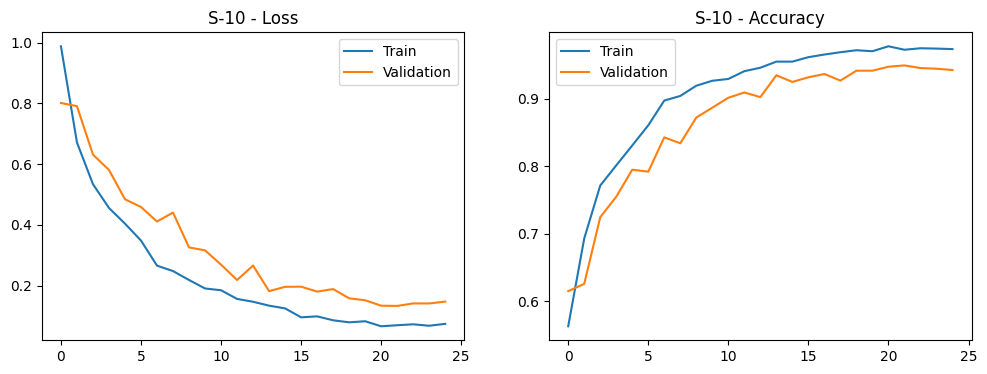


=== CLASSIFICATION REPORT: S-10 ===
              precision    recall  f1-score   support

           0       0.98      0.95      0.96       172
           1       1.00      1.00      1.00        15
           2       0.96      0.95      0.96       634
           3       0.94      0.95      0.94       459

    accuracy                           0.95      1280
   macro avg       0.97      0.96      0.97      1280
weighted avg       0.95      0.95      0.95      1280


STARTING: S-11 | Opt: SGD | Sched: ReduceLROnPlateau
Epoch 01/25 | LR: 1.00e-04 | Train Loss: 1.3904 Acc: 0.2676 | Val Loss: 1.3896 Acc: 0.2041
Epoch 02/25 | LR: 1.00e-04 | Train Loss: 1.3816 Acc: 0.2791 | Val Loss: 1.3818 Acc: 0.2832
Epoch 03/25 | LR: 1.00e-04 | Train Loss: 1.3703 Acc: 0.3210 | Val Loss: 1.3822 Acc: 0.2920
Epoch 04/25 | LR: 1.00e-04 | Train Loss: 1.3644 Acc: 0.3374 | Val Loss: 1.3708 Acc: 0.3828
Epoch 05/25 | LR: 1.00e-04 | Train Loss: 1.3591 Acc: 0.3508 | Val Loss: 1.3684 Acc: 0.3760
Epoch 06/25 | LR: 1

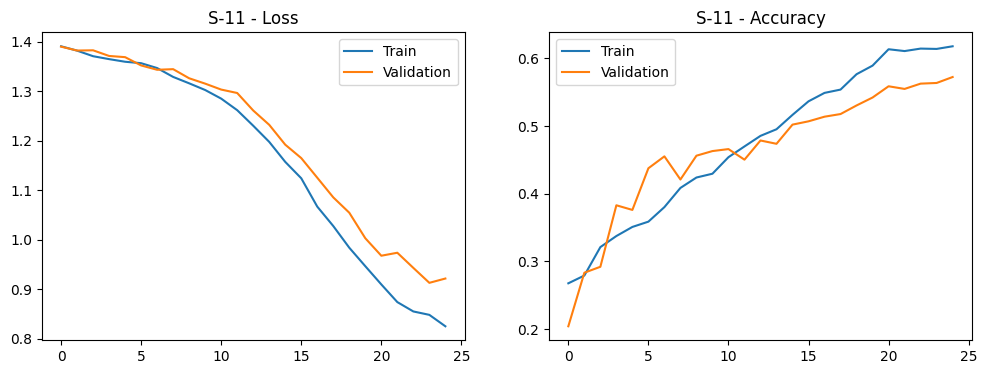


=== CLASSIFICATION REPORT: S-11 ===
              precision    recall  f1-score   support

           0       0.32      0.51      0.39       172
           1       0.52      0.93      0.67        15
           2       0.65      0.77      0.70       634
           3       0.51      0.25      0.34       459

    accuracy                           0.55      1280
   macro avg       0.50      0.62      0.52      1280
weighted avg       0.55      0.55      0.53      1280


STARTING: S-12 | Opt: SGD | Sched: CosineAnnealingLR
Epoch 01/25 | LR: 9.96e-05 | Train Loss: 1.3878 Acc: 0.2603 | Val Loss: 1.3855 Acc: 0.2939
Epoch 02/25 | LR: 9.84e-05 | Train Loss: 1.3851 Acc: 0.2703 | Val Loss: 1.3756 Acc: 0.3564
Epoch 03/25 | LR: 9.65e-05 | Train Loss: 1.3736 Acc: 0.3032 | Val Loss: 1.3786 Acc: 0.3193
Epoch 04/25 | LR: 9.38e-05 | Train Loss: 1.3647 Acc: 0.3276 | Val Loss: 1.3677 Acc: 0.3848
Epoch 05/25 | LR: 9.05e-05 | Train Loss: 1.3586 Acc: 0.3445 | Val Loss: 1.3643 Acc: 0.4004
Epoch 06/25 | LR: 8

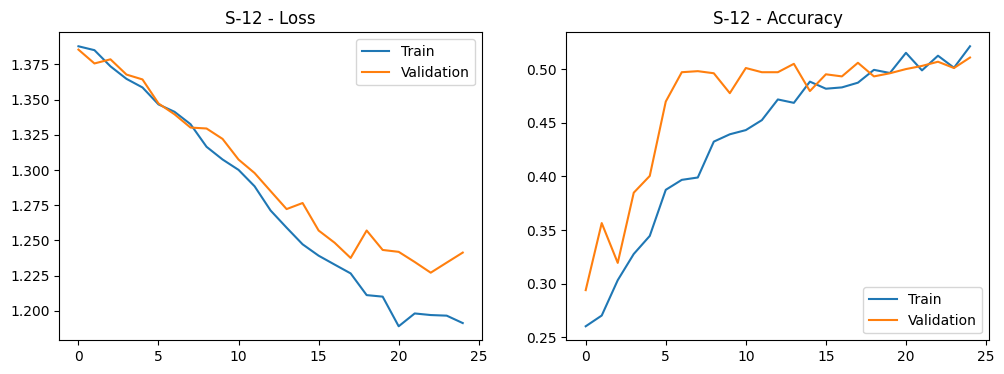


=== CLASSIFICATION REPORT: S-12 ===
              precision    recall  f1-score   support

           0       0.28      0.29      0.29       172
           1       0.07      1.00      0.12        15
           2       0.64      0.74      0.69       634
           3       0.53      0.16      0.24       459

    accuracy                           0.48      1280
   macro avg       0.38      0.55      0.33      1280
weighted avg       0.54      0.48      0.47      1280



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CONFIG & SETUP
# ==========================================
CONFIG = {
    "lr": 1e-4,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"] # 5120 data
test_data = hf_dataset["test"]      # 1280 data

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

train_labels = np.array(train_data["label"])

# ==========================================
# 3. WEIGHTED SAMPLER (IMBALANCE)
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1. / class_counts
sample_weights = class_weights[train_labels]

# ==========================================
# 4. DATASET WRAPPER
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

# ==========================================
# 5. DEFINE TRANSFORMS (AUG & NO AUG)
# ==========================================
base_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

aug_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==========================================
# 6. EXPERIMENT FUNCTION (UNFREEZE LAST LAYERS)
# ==========================================
def run_experiment(experiment_name, train_transform, opt_type, sched_type):
    print(f"\n{'='*60}")
    print(f"STARTING: {experiment_name} | Opt: {opt_type} | Sched: {sched_type}")
    print(f"{'='*60}")

    # --- Setup DataLoaders (WeightedRandomSampler) ---
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )

    train_ds = AlzheimerDataset(train_data, train_transform)
    val_ds   = AlzheimerDataset(val_data, base_transform)
    test_ds  = AlzheimerDataset(test_data, base_transform)

    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, num_workers=CONFIG["num_workers"])
    val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
    test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

    # --- Setup Model ---
    model = efficientnet_b2(weights=EfficientNet_B2_Weights.DEFAULT)

    # 1. Freeze semua layer features terlebih dahulu
    for param in model.features.parameters():
        param.requires_grad = False

    # 2. PERUBAHAN DI SINI: Unfreeze 4 layer terakhir di block features
    for param in model.features[-4:].parameters():
        param.requires_grad = True

    num_classes = len(np.unique(train_labels))
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(1408, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )
    model = model.to(device)

    # --- Loss ---
    criterion = nn.CrossEntropyLoss()

    # --- Dynamic Optimizer ---
    # trainable_params sekarang mencakup model.classifier DAN model.features[-4:]
    trainable_params = filter(lambda p: p.requires_grad, model.parameters())

    if opt_type == 'Adam':
        optimizer = optim.Adam(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'AdamW':
        optimizer = optim.AdamW(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'SGD':
        optimizer = optim.SGD(trainable_params, lr=CONFIG["lr"], momentum=0.9)
    else:
        raise ValueError("Optimizer tidak dikenali!")

    # --- Dynamic Scheduler ---
    if sched_type == 'CosineAnnealingLR':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])
    elif sched_type == 'ReduceLROnPlateau':
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
    else:
        raise ValueError("Scheduler tidak dikenali!")

    # --- Training Loop ---
    train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []
    best_model = copy.deepcopy(model.state_dict())
    best_loss = float("inf")
    counter = 0

    for epoch in range(CONFIG["epochs"]):
        # ===== Train =====
        model.train()
        train_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss /= total
        train_acc = correct / total

        # CosineAnnealingLR di-step setiap akhir epoch training
        if sched_type == 'CosineAnnealingLR':
            scheduler.step()

        # ===== Validation =====
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        # ReduceLROnPlateau di-step setiap akhir epoch validation
        if sched_type == 'ReduceLROnPlateau':
            scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:02d}/{CONFIG['epochs']} | LR: {current_lr:.2e} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        # ===== Early Stopping =====
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= CONFIG["patience"]:
                print("-> Early stopping triggered!")
                break

    # --- Load Best Model & Test ---
    print(f"\nLoading best model for testing...")
    model.load_state_dict(best_model)

    model.eval()
    all_probs, all_labels, all_preds = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())

    # --- Plotting & Metrics ---
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Validation")
    plt.title(f"{experiment_name} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label="Train")
    plt.plot(val_accuracies, label="Validation")
    plt.title(f"{experiment_name} - Accuracy")
    plt.legend()
    plt.show()

    print(f"\n=== CLASSIFICATION REPORT: {experiment_name} ===")
    print(classification_report(all_labels, all_preds))

# ==========================================
# 7. RUN PIPELINES (SCENARIOS S-07 to S-12)
# ==========================================
scenarios_unfreeze = [
    # {"name": "S-07", "opt": "Adam",  "sched": "ReduceLROnPlateau"},
    # {"name": "S-08", "opt": "Adam",  "sched": "CosineAnnealingLR"},
    # {"name": "S-09", "opt": "AdamW", "sched": "ReduceLROnPlateau"},
    {"name": "S-10", "opt": "AdamW", "sched": "CosineAnnealingLR"},
    {"name": "S-11", "opt": "SGD",   "sched": "ReduceLROnPlateau"},
    {"name": "S-12", "opt": "SGD",   "sched": "CosineAnnealingLR"}
]

for scenario in scenarios_unfreeze:
    run_experiment(
        experiment_name=scenario["name"],
        train_transform=aug_transform,  # Menggunakan data augmentasi sesuai request sebelumnya
        opt_type=scenario["opt"],
        sched_type=scenario["sched"]
    )

Device: cuda
Loading dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/2.13k [00:00<?, ?B/s]

data/train-00000-of-00001-c08a401c53fe53(…):   0%|          | 0.00/22.6M [00:00<?, ?B/s]

data/test-00000-of-00001-44110b9df98c558(…):   0%|          | 0.00/5.65M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5120 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1280 [00:00<?, ? examples/s]

Train: 4096 | Val: 1024 | Test: 1280

STARTING: S-13 | Opt: Adam | Sched: ReduceLROnPlateau
Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 158MB/s]


Epoch 01/25 | LR: 1.00e-04 | Train Loss: 0.9690 Acc: 0.5613 | Val Loss: 0.8033 Acc: 0.5977
Epoch 02/25 | LR: 1.00e-04 | Train Loss: 0.6140 Acc: 0.7222 | Val Loss: 0.7293 Acc: 0.6729
Epoch 03/25 | LR: 1.00e-04 | Train Loss: 0.5107 Acc: 0.7859 | Val Loss: 0.5778 Acc: 0.7471
Epoch 04/25 | LR: 1.00e-04 | Train Loss: 0.3828 Acc: 0.8462 | Val Loss: 0.4299 Acc: 0.8066
Epoch 05/25 | LR: 1.00e-04 | Train Loss: 0.2970 Acc: 0.8794 | Val Loss: 0.4205 Acc: 0.8232
Epoch 06/25 | LR: 1.00e-04 | Train Loss: 0.2508 Acc: 0.9060 | Val Loss: 0.2981 Acc: 0.8799
Epoch 07/25 | LR: 1.00e-04 | Train Loss: 0.1958 Acc: 0.9275 | Val Loss: 0.2353 Acc: 0.9072
Epoch 08/25 | LR: 1.00e-04 | Train Loss: 0.1571 Acc: 0.9421 | Val Loss: 0.2154 Acc: 0.9209
Epoch 09/25 | LR: 1.00e-04 | Train Loss: 0.1361 Acc: 0.9482 | Val Loss: 0.1484 Acc: 0.9434
Epoch 10/25 | LR: 1.00e-04 | Train Loss: 0.1262 Acc: 0.9529 | Val Loss: 0.1464 Acc: 0.9385
Epoch 11/25 | LR: 1.00e-04 | Train Loss: 0.0994 Acc: 0.9651 | Val Loss: 0.1370 Acc: 0.9512

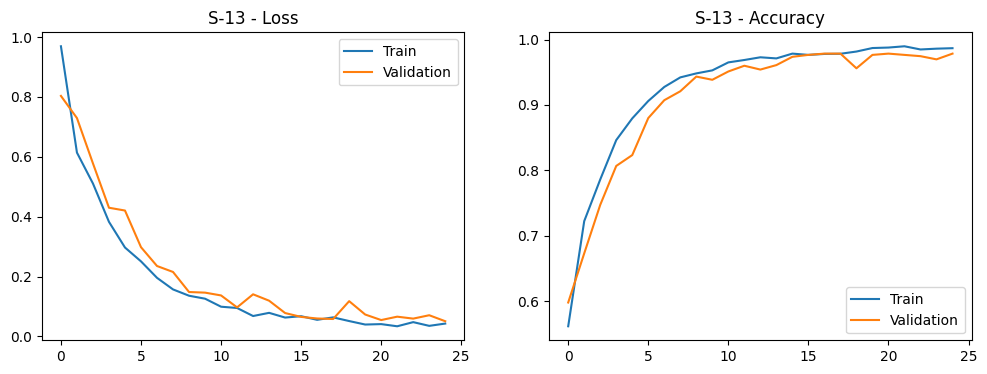


=== CLASSIFICATION REPORT: S-13 ===
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       172
           1       1.00      1.00      1.00        15
           2       1.00      0.97      0.98       634
           3       0.95      1.00      0.97       459

    accuracy                           0.98      1280
   macro avg       0.99      0.98      0.98      1280
weighted avg       0.98      0.98      0.98      1280


STARTING: S-14 | Opt: Adam | Sched: CosineAnnealingLR
Epoch 01/25 | LR: 9.96e-05 | Train Loss: 0.9824 Acc: 0.5503 | Val Loss: 0.8251 Acc: 0.5869
Epoch 02/25 | LR: 9.84e-05 | Train Loss: 0.6288 Acc: 0.7200 | Val Loss: 0.6659 Acc: 0.6973
Epoch 03/25 | LR: 9.65e-05 | Train Loss: 0.4898 Acc: 0.7949 | Val Loss: 0.5962 Acc: 0.7529
Epoch 04/25 | LR: 9.38e-05 | Train Loss: 0.4007 Acc: 0.8430 | Val Loss: 0.4182 Acc: 0.8184
Epoch 05/25 | LR: 9.05e-05 | Train Loss: 0.2989 Acc: 0.8816 | Val Loss: 0.3529 Acc: 0.8477
Epoch 06/25 | LR: 

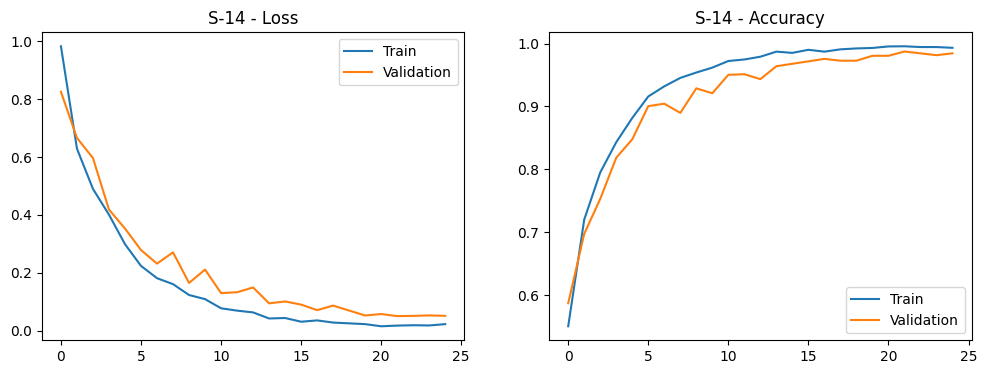


=== CLASSIFICATION REPORT: S-14 ===
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       172
           1       1.00      1.00      1.00        15
           2       0.98      0.99      0.98       634
           3       0.97      0.97      0.97       459

    accuracy                           0.98      1280
   macro avg       0.99      0.98      0.98      1280
weighted avg       0.98      0.98      0.98      1280


STARTING: S-15 | Opt: AdamW | Sched: ReduceLROnPlateau
Epoch 01/25 | LR: 1.00e-04 | Train Loss: 0.9467 Acc: 0.5730 | Val Loss: 0.7854 Acc: 0.6299
Epoch 02/25 | LR: 1.00e-04 | Train Loss: 0.6264 Acc: 0.7224 | Val Loss: 0.6822 Acc: 0.6826
Epoch 03/25 | LR: 1.00e-04 | Train Loss: 0.4888 Acc: 0.7939 | Val Loss: 0.5159 Acc: 0.7539
Epoch 04/25 | LR: 1.00e-04 | Train Loss: 0.3655 Acc: 0.8555 | Val Loss: 0.4467 Acc: 0.8027
Epoch 05/25 | LR: 1.00e-04 | Train Loss: 0.2657 Acc: 0.8965 | Val Loss: 0.3234 Acc: 0.8672
Epoch 06/25 | LR:

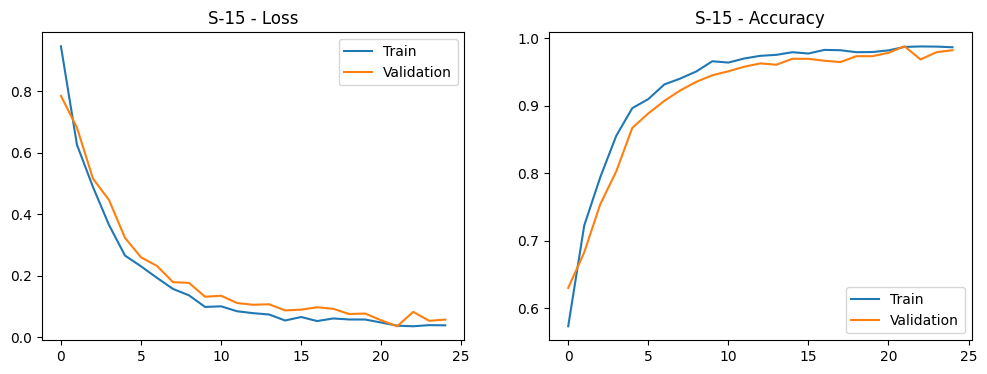


=== CLASSIFICATION REPORT: S-15 ===
              precision    recall  f1-score   support

           0       0.99      0.96      0.98       172
           1       1.00      1.00      1.00        15
           2       0.97      0.99      0.98       634
           3       0.97      0.96      0.97       459

    accuracy                           0.98      1280
   macro avg       0.99      0.98      0.98      1280
weighted avg       0.98      0.98      0.98      1280



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CONFIG & SETUP
# ==========================================
CONFIG = {
    "lr": 1e-4,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"] # 5120 data
test_data = hf_dataset["test"]      # 1280 data

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

train_labels = np.array(train_data["label"])

# ==========================================
# 3. WEIGHTED SAMPLER (IMBALANCE)
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1. / class_counts
sample_weights = class_weights[train_labels]

# ==========================================
# 4. DATASET WRAPPER
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

# ==========================================
# 5. DEFINE TRANSFORMS (AUG & NO AUG)
# ==========================================
base_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

aug_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==========================================
# 6. EXPERIMENT FUNCTION (FULL FINE-TUNING)
# ==========================================
def run_experiment(experiment_name, train_transform, opt_type, sched_type):
    print(f"\n{'='*60}")
    print(f"STARTING: {experiment_name} | Opt: {opt_type} | Sched: {sched_type}")
    print(f"{'='*60}")

    # --- Setup DataLoaders (WeightedRandomSampler) ---
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )

    train_ds = AlzheimerDataset(train_data, train_transform)
    val_ds   = AlzheimerDataset(val_data, base_transform)
    test_ds  = AlzheimerDataset(test_data, base_transform)

    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, num_workers=CONFIG["num_workers"])
    val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
    test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

    # --- Setup Model ---
    model = efficientnet_b2(weights=EfficientNet_B2_Weights.DEFAULT)

    # PERUBAHAN DI SINI: Pastikan SEMUA layer terbuka (Full Fine-Tuning)
    # Secara default, bobot pre-trained PyTorch sudah True, tapi kita pastikan ulang di sini
    for param in model.parameters():
        param.requires_grad = True

    num_classes = len(np.unique(train_labels))
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(1408, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )
    model = model.to(device)

    # --- Loss ---
    criterion = nn.CrossEntropyLoss()

    # --- Dynamic Optimizer ---
    # trainable_params sekarang mencakup KESELURUHAN model (fitur awal hingga classifier akhir)
    trainable_params = filter(lambda p: p.requires_grad, model.parameters())

    if opt_type == 'Adam':
        optimizer = optim.Adam(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'AdamW':
        optimizer = optim.AdamW(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'SGD':
        optimizer = optim.SGD(trainable_params, lr=CONFIG["lr"], momentum=0.9)
    else:
        raise ValueError("Optimizer tidak dikenali!")

    # --- Dynamic Scheduler ---
    if sched_type == 'CosineAnnealingLR':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])
    elif sched_type == 'ReduceLROnPlateau':
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
    else:
        raise ValueError("Scheduler tidak dikenali!")

    # --- Training Loop ---
    train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []
    best_model = copy.deepcopy(model.state_dict())
    best_loss = float("inf")
    counter = 0

    for epoch in range(CONFIG["epochs"]):
        # ===== Train =====
        model.train()
        train_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss /= total
        train_acc = correct / total

        # CosineAnnealingLR di-step setiap akhir epoch training
        if sched_type == 'CosineAnnealingLR':
            scheduler.step()

        # ===== Validation =====
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        # ReduceLROnPlateau di-step setiap akhir epoch validation
        if sched_type == 'ReduceLROnPlateau':
            scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:02d}/{CONFIG['epochs']} | LR: {current_lr:.2e} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        # ===== Early Stopping =====
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= CONFIG["patience"]:
                print("-> Early stopping triggered!")
                break

    # --- Load Best Model & Test ---
    print(f"\nLoading best model for testing...")
    model.load_state_dict(best_model)

    model.eval()
    all_probs, all_labels, all_preds = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())

    # --- Plotting & Metrics ---
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Validation")
    plt.title(f"{experiment_name} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label="Train")
    plt.plot(val_accuracies, label="Validation")
    plt.title(f"{experiment_name} - Accuracy")
    plt.legend()
    plt.show()

    print(f"\n=== CLASSIFICATION REPORT: {experiment_name} ===")
    print(classification_report(all_labels, all_preds))

# ==========================================
# 7. RUN PIPELINES (SCENARIOS S-13 to S-18)
# ==========================================
scenarios_full_tuning = [
    {"name": "S-13", "opt": "Adam",  "sched": "ReduceLROnPlateau"},
    {"name": "S-14", "opt": "Adam",  "sched": "CosineAnnealingLR"},
    {"name": "S-15", "opt": "AdamW", "sched": "ReduceLROnPlateau"},
    # {"name": "S-16", "opt": "AdamW", "sched": "CosineAnnealingLR"},
    # {"name": "S-17", "opt": "SGD",   "sched": "ReduceLROnPlateau"},
    # {"name": "S-18", "opt": "SGD",   "sched": "CosineAnnealingLR"}
]

for scenario in scenarios_full_tuning:
    run_experiment(
        experiment_name=scenario["name"],
        train_transform=aug_transform,
        opt_type=scenario["opt"],
        sched_type=scenario["sched"]
    )


STARTING: S-16 | Opt: AdamW | Sched: CosineAnnealingLR
Epoch 01/25 | LR: 9.96e-05 | Train Loss: 0.9772 Acc: 0.5635 | Val Loss: 0.8298 Acc: 0.6016
Epoch 02/25 | LR: 9.84e-05 | Train Loss: 0.6110 Acc: 0.7332 | Val Loss: 0.7338 Acc: 0.6729
Epoch 03/25 | LR: 9.65e-05 | Train Loss: 0.4938 Acc: 0.7939 | Val Loss: 0.6146 Acc: 0.7090
Epoch 04/25 | LR: 9.38e-05 | Train Loss: 0.3859 Acc: 0.8423 | Val Loss: 0.4950 Acc: 0.8008
Epoch 05/25 | LR: 9.05e-05 | Train Loss: 0.2938 Acc: 0.8845 | Val Loss: 0.3806 Acc: 0.8428
Epoch 06/25 | LR: 8.64e-05 | Train Loss: 0.2326 Acc: 0.9084 | Val Loss: 0.2748 Acc: 0.8838
Epoch 07/25 | LR: 8.19e-05 | Train Loss: 0.1774 Acc: 0.9370 | Val Loss: 0.3396 Acc: 0.8730
Epoch 08/25 | LR: 7.68e-05 | Train Loss: 0.1309 Acc: 0.9521 | Val Loss: 0.2074 Acc: 0.9258
Epoch 09/25 | LR: 7.13e-05 | Train Loss: 0.1276 Acc: 0.9561 | Val Loss: 0.1883 Acc: 0.9346
Epoch 10/25 | LR: 6.55e-05 | Train Loss: 0.0985 Acc: 0.9670 | Val Loss: 0.1405 Acc: 0.9502
Epoch 11/25 | LR: 5.94e-05 | Train

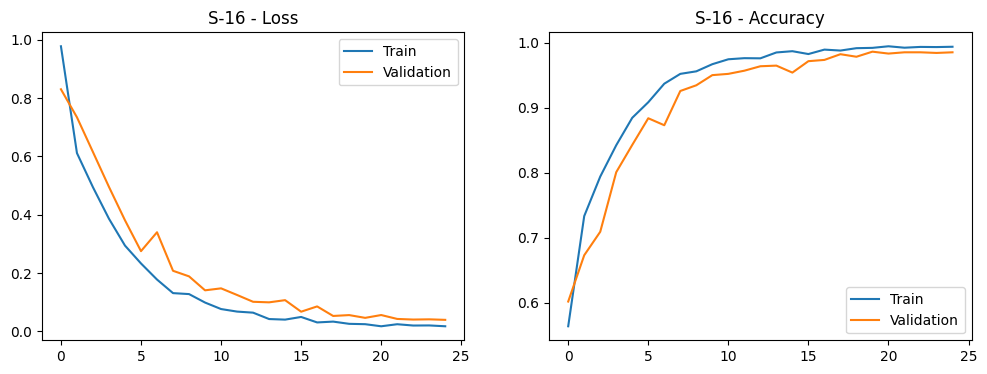


=== CLASSIFICATION REPORT: S-16 ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       172
           1       1.00      0.93      0.97        15
           2       0.98      0.99      0.99       634
           3       0.98      0.98      0.98       459

    accuracy                           0.98      1280
   macro avg       0.99      0.97      0.98      1280
weighted avg       0.98      0.98      0.98      1280



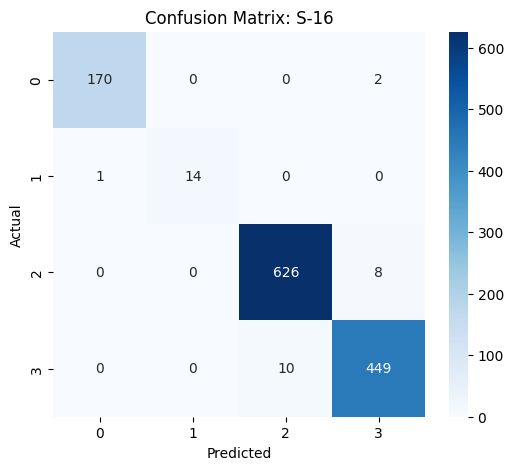


STARTING: S-17 | Opt: SGD | Sched: ReduceLROnPlateau
Epoch 01/25 | LR: 1.00e-04 | Train Loss: 1.3884 Acc: 0.2642 | Val Loss: 1.3824 Acc: 0.2910
Epoch 02/25 | LR: 1.00e-04 | Train Loss: 1.3793 Acc: 0.2893 | Val Loss: 1.3865 Acc: 0.2432
Epoch 03/25 | LR: 1.00e-04 | Train Loss: 1.3728 Acc: 0.3181 | Val Loss: 1.3807 Acc: 0.2588
Epoch 04/25 | LR: 1.00e-04 | Train Loss: 1.3673 Acc: 0.3269 | Val Loss: 1.3749 Acc: 0.2959
Epoch 05/25 | LR: 1.00e-04 | Train Loss: 1.3559 Acc: 0.3501 | Val Loss: 1.3610 Acc: 0.3877
Epoch 06/25 | LR: 1.00e-04 | Train Loss: 1.3416 Acc: 0.3855 | Val Loss: 1.3568 Acc: 0.3857
Epoch 07/25 | LR: 1.00e-04 | Train Loss: 1.3274 Acc: 0.4133 | Val Loss: 1.3545 Acc: 0.3662
Epoch 08/25 | LR: 1.00e-04 | Train Loss: 1.3105 Acc: 0.4307 | Val Loss: 1.3315 Acc: 0.4180
Epoch 09/25 | LR: 1.00e-04 | Train Loss: 1.2825 Acc: 0.4609 | Val Loss: 1.3140 Acc: 0.4463
Epoch 10/25 | LR: 1.00e-04 | Train Loss: 1.2487 Acc: 0.4841 | Val Loss: 1.2786 Acc: 0.4736
Epoch 11/25 | LR: 1.00e-04 | Train L

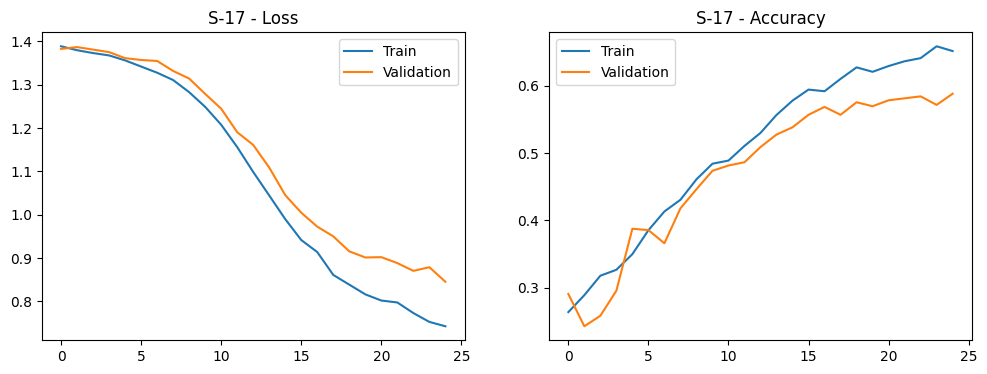


=== CLASSIFICATION REPORT: S-17 ===
              precision    recall  f1-score   support

           0       0.33      0.63      0.43       172
           1       0.79      1.00      0.88        15
           2       0.67      0.76      0.72       634
           3       0.53      0.24      0.33       459

    accuracy                           0.56      1280
   macro avg       0.58      0.66      0.59      1280
weighted avg       0.58      0.56      0.54      1280



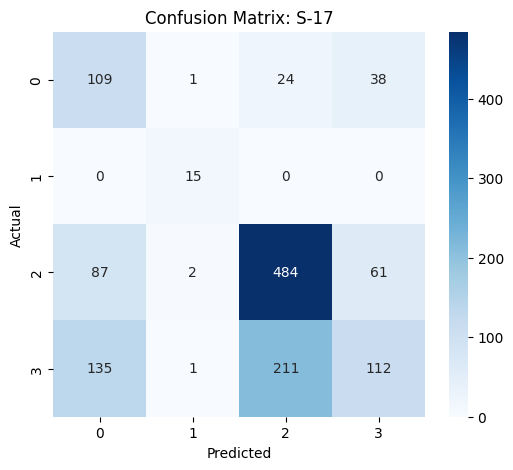


STARTING: S-18 | Opt: SGD | Sched: CosineAnnealingLR
Epoch 01/25 | LR: 9.96e-05 | Train Loss: 1.3899 Acc: 0.2717 | Val Loss: 1.3890 Acc: 0.1904
Epoch 02/25 | LR: 9.84e-05 | Train Loss: 1.3794 Acc: 0.3003 | Val Loss: 1.3864 Acc: 0.2363
Epoch 03/25 | LR: 9.65e-05 | Train Loss: 1.3712 Acc: 0.3206 | Val Loss: 1.3785 Acc: 0.3164
Epoch 04/25 | LR: 9.38e-05 | Train Loss: 1.3621 Acc: 0.3335 | Val Loss: 1.3782 Acc: 0.3232
Epoch 05/25 | LR: 9.05e-05 | Train Loss: 1.3558 Acc: 0.3418 | Val Loss: 1.3621 Acc: 0.3887
Epoch 06/25 | LR: 8.64e-05 | Train Loss: 1.3406 Acc: 0.3850 | Val Loss: 1.3580 Acc: 0.3916
Epoch 07/25 | LR: 8.19e-05 | Train Loss: 1.3285 Acc: 0.4136 | Val Loss: 1.3632 Acc: 0.3535
Epoch 08/25 | LR: 7.68e-05 | Train Loss: 1.3101 Acc: 0.4246 | Val Loss: 1.3439 Acc: 0.3896
Epoch 09/25 | LR: 7.13e-05 | Train Loss: 1.2867 Acc: 0.4539 | Val Loss: 1.3261 Acc: 0.4082
Epoch 10/25 | LR: 6.55e-05 | Train Loss: 1.2686 Acc: 0.4688 | Val Loss: 1.2942 Acc: 0.4473
Epoch 11/25 | LR: 5.94e-05 | Train L

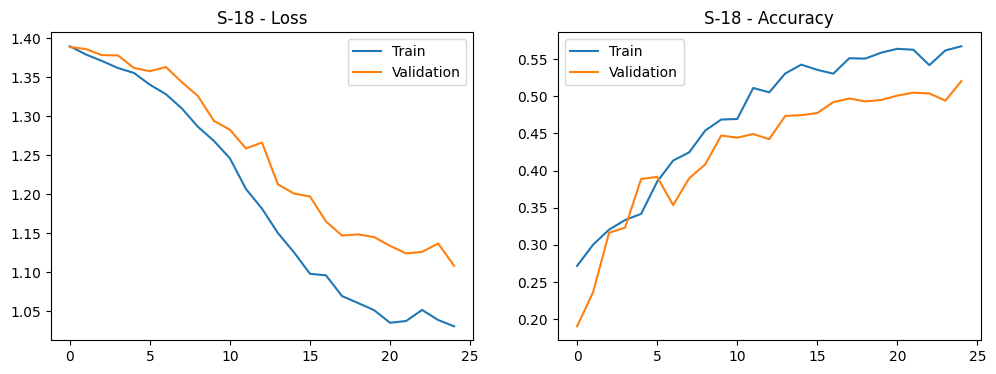


=== CLASSIFICATION REPORT: S-18 ===
              precision    recall  f1-score   support

           0       0.34      0.50      0.40       172
           1       0.14      1.00      0.25        15
           2       0.61      0.82      0.70       634
           3       0.57      0.09      0.15       459

    accuracy                           0.51      1280
   macro avg       0.42      0.60      0.38      1280
weighted avg       0.55      0.51      0.46      1280



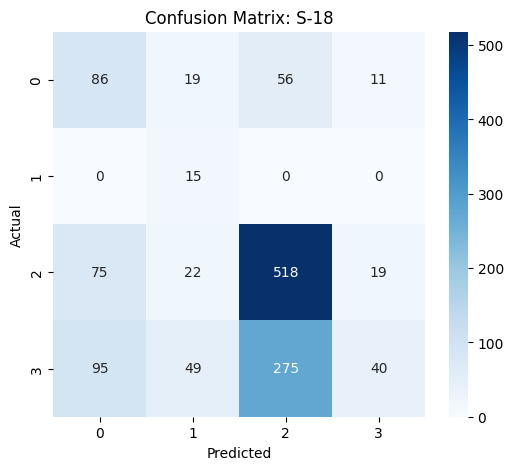

In [ ]:
# ==========================================
# 6. EXPERIMENT FUNCTION (FULL FINE-TUNING)
# ==========================================
def run_experiment(experiment_name, train_transform, opt_type, sched_type):
    print(f"\n{'='*60}")
    print(f"STARTING: {experiment_name} | Opt: {opt_type} | Sched: {sched_type}")
    print(f"{'='*60}")

    # --- Setup DataLoaders (WeightedRandomSampler) ---
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )

    train_ds = AlzheimerDataset(train_data, train_transform)
    val_ds   = AlzheimerDataset(val_data, base_transform)
    test_ds  = AlzheimerDataset(test_data, base_transform)

    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, num_workers=CONFIG["num_workers"])
    val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
    test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

    # --- Setup Model ---
    model = efficientnet_b2(weights=EfficientNet_B2_Weights.DEFAULT)

    # Pastikan SEMUA layer terbuka (Full Fine-Tuning)
    for param in model.parameters():
        param.requires_grad = True

    num_classes = len(np.unique(train_labels))
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(1408, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )
    model = model.to(device)

    # --- Loss ---
    criterion = nn.CrossEntropyLoss()

    # --- Dynamic Optimizer ---
    trainable_params = filter(lambda p: p.requires_grad, model.parameters())

    if opt_type == 'Adam':
        optimizer = optim.Adam(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'AdamW':
        optimizer = optim.AdamW(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'SGD':
        optimizer = optim.SGD(trainable_params, lr=CONFIG["lr"], momentum=0.9)
    else:
        raise ValueError("Optimizer tidak dikenali!")

    # --- Dynamic Scheduler ---
    if sched_type == 'CosineAnnealingLR':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])
    elif sched_type == 'ReduceLROnPlateau':
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
    else:
        raise ValueError("Scheduler tidak dikenali!")

    # --- Training Loop ---
    train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []
    best_model = copy.deepcopy(model.state_dict())
    best_loss = float("inf")
    counter = 0

    for epoch in range(CONFIG["epochs"]):
        # ===== Train =====
        model.train()
        train_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss /= total
        train_acc = correct / total

        # CosineAnnealingLR di-step setiap akhir epoch training
        if sched_type == 'CosineAnnealingLR':
            scheduler.step()

        # ===== Validation =====
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        # ReduceLROnPlateau di-step setiap akhir epoch validation
        if sched_type == 'ReduceLROnPlateau':
            scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:02d}/{CONFIG['epochs']} | LR: {current_lr:.2e} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        # ===== Early Stopping =====
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= CONFIG["patience"]:
                print("-> Early stopping triggered!")
                break

    # --- Load Best Model & Test ---
    print(f"\nLoading best model for testing...")
    model.load_state_dict(best_model)

    model.eval()
    all_probs, all_labels, all_preds = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())

    # --- Plotting & Metrics ---
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Validation")
    plt.title(f"{experiment_name} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label="Train")
    plt.plot(val_accuracies, label="Validation")
    plt.title(f"{experiment_name} - Accuracy")
    plt.legend()
    plt.show()

    print(f"\n=== CLASSIFICATION REPORT: {experiment_name} ===")
    print(classification_report(all_labels, all_preds))

    # --- CONFUSION MATRIX DITAMBAHKAN DI SINI ---
    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix: {experiment_name}")
    plt.show()

# ==========================================
# 7. RUN PIPELINES (SCENARIOS S-13 to S-18)
# ==========================================
scenarios_full_tuning = [
    # {"name": "S-13", "opt": "Adam",  "sched": "ReduceLROnPlateau"},
    # {"name": "S-14", "opt": "Adam",  "sched": "CosineAnnealingLR"},
    # {"name": "S-15", "opt": "AdamW", "sched": "ReduceLROnPlateau"},
    {"name": "S-16", "opt": "AdamW", "sched": "CosineAnnealingLR"},
    {"name": "S-17", "opt": "SGD",   "sched": "ReduceLROnPlateau"},
    {"name": "S-18", "opt": "SGD",   "sched": "CosineAnnealingLR"}
]

for scenario in scenarios_full_tuning:
    run_experiment(
        experiment_name=scenario["name"],
        train_transform=aug_transform,
        opt_type=scenario["opt"],
        sched_type=scenario["sched"]
    )

# AUG + Class Weight (All Skenario)

Device: cuda
Loading dataset...
Train: 4096 | Val: 1024 | Test: 1280

Menghitung Class Weights...
Class Weights Tensor: tensor([0.2419, 3.5916, 0.0682, 0.0983], device='cuda:0')

STARTING: S-01 | Opt: Adam | Sched: ReduceLROnPlateau
Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 161MB/s]


Epoch 01/25 | LR: 1.00e-04 | Train Loss: 1.3065 Acc: 0.4617 | Val Loss: 1.2715 Acc: 0.5547
Epoch 02/25 | LR: 1.00e-04 | Train Loss: 1.2326 Acc: 0.5125 | Val Loss: 1.2170 Acc: 0.5537
Epoch 03/25 | LR: 1.00e-04 | Train Loss: 1.2067 Acc: 0.4966 | Val Loss: 1.1873 Acc: 0.5674
Epoch 04/25 | LR: 1.00e-04 | Train Loss: 1.1871 Acc: 0.5220 | Val Loss: 1.1511 Acc: 0.5723
Epoch 05/25 | LR: 1.00e-04 | Train Loss: 1.1586 Acc: 0.5176 | Val Loss: 1.1281 Acc: 0.5615
Epoch 06/25 | LR: 1.00e-04 | Train Loss: 1.1526 Acc: 0.5168 | Val Loss: 1.0929 Acc: 0.5566
Epoch 07/25 | LR: 1.00e-04 | Train Loss: 1.1430 Acc: 0.5186 | Val Loss: 1.0936 Acc: 0.5684
Epoch 08/25 | LR: 1.00e-04 | Train Loss: 1.1258 Acc: 0.5317 | Val Loss: 1.0755 Acc: 0.5625
Epoch 09/25 | LR: 1.00e-04 | Train Loss: 1.1359 Acc: 0.5278 | Val Loss: 1.0578 Acc: 0.5645
Epoch 10/25 | LR: 1.00e-04 | Train Loss: 1.1225 Acc: 0.5176 | Val Loss: 1.0519 Acc: 0.5791
Epoch 11/25 | LR: 1.00e-04 | Train Loss: 1.1114 Acc: 0.5396 | Val Loss: 1.0374 Acc: 0.5703

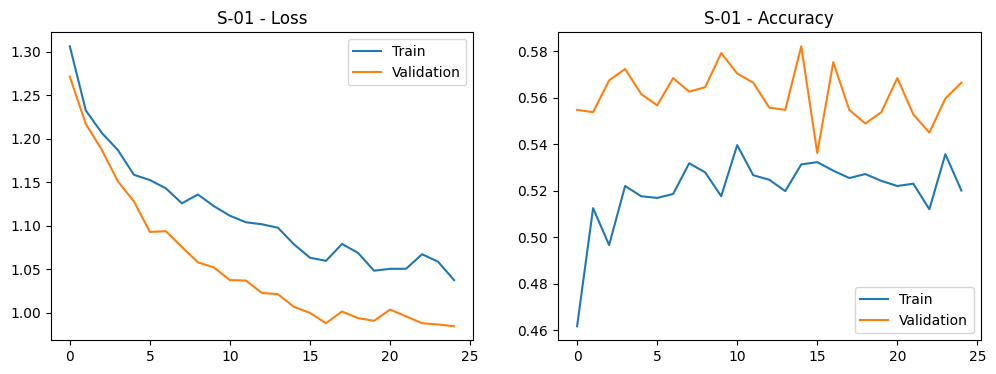


=== CLASSIFICATION REPORT: S-01 ===
              precision    recall  f1-score   support

           0       0.35      0.49      0.41       172
           1       0.17      0.80      0.28        15
           2       0.69      0.66      0.68       634
           3       0.53      0.41      0.46       459

    accuracy                           0.55      1280
   macro avg       0.44      0.59      0.46      1280
weighted avg       0.58      0.55      0.56      1280



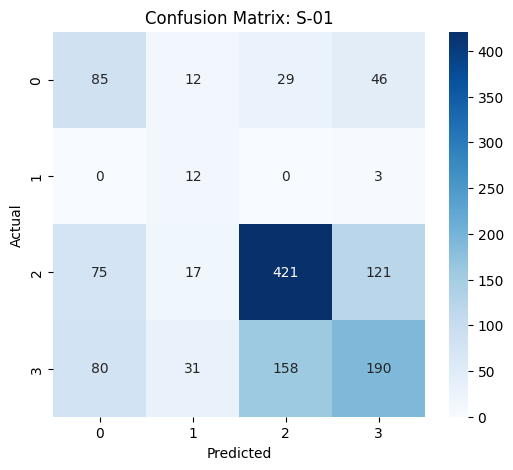


STARTING: S-02 | Opt: Adam | Sched: CosineAnnealingLR
Epoch 01/25 | LR: 9.96e-05 | Train Loss: 1.3177 Acc: 0.4514 | Val Loss: 1.2540 Acc: 0.5654
Epoch 02/25 | LR: 9.84e-05 | Train Loss: 1.2468 Acc: 0.4910 | Val Loss: 1.1999 Acc: 0.5488
Epoch 03/25 | LR: 9.65e-05 | Train Loss: 1.1965 Acc: 0.5046 | Val Loss: 1.1558 Acc: 0.5264
Epoch 04/25 | LR: 9.38e-05 | Train Loss: 1.1862 Acc: 0.5129 | Val Loss: 1.1299 Acc: 0.5742
Epoch 05/25 | LR: 9.05e-05 | Train Loss: 1.1530 Acc: 0.5237 | Val Loss: 1.1084 Acc: 0.5781
Epoch 06/25 | LR: 8.64e-05 | Train Loss: 1.1573 Acc: 0.5244 | Val Loss: 1.1051 Acc: 0.5752
Epoch 07/25 | LR: 8.19e-05 | Train Loss: 1.1341 Acc: 0.5305 | Val Loss: 1.0842 Acc: 0.5576
Epoch 08/25 | LR: 7.68e-05 | Train Loss: 1.1331 Acc: 0.5146 | Val Loss: 1.0837 Acc: 0.5625
Epoch 09/25 | LR: 7.13e-05 | Train Loss: 1.1167 Acc: 0.5254 | Val Loss: 1.0732 Acc: 0.5811
Epoch 10/25 | LR: 6.55e-05 | Train Loss: 1.1231 Acc: 0.5222 | Val Loss: 1.0650 Acc: 0.5869
Epoch 11/25 | LR: 5.94e-05 | Train 

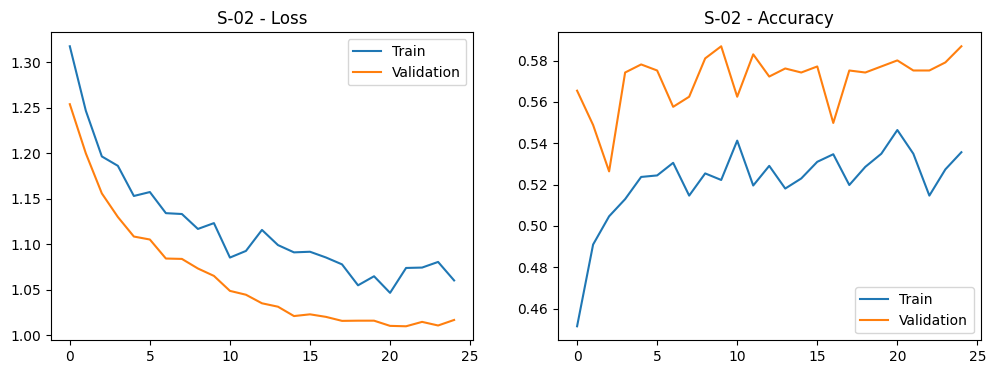


=== CLASSIFICATION REPORT: S-02 ===
              precision    recall  f1-score   support

           0       0.32      0.53      0.40       172
           1       0.34      0.80      0.48        15
           2       0.69      0.66      0.68       634
           3       0.53      0.40      0.46       459

    accuracy                           0.55      1280
   macro avg       0.47      0.60      0.50      1280
weighted avg       0.58      0.55      0.56      1280



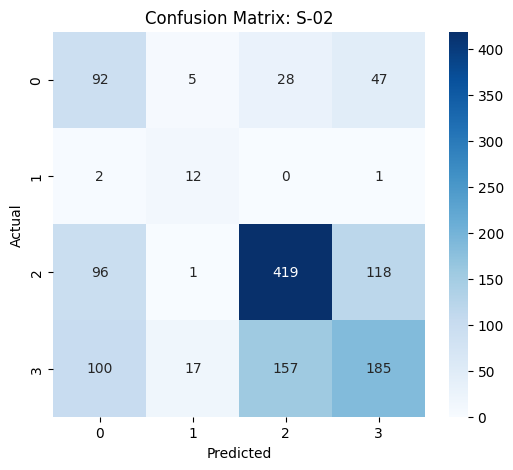


STARTING: S-03 | Opt: AdamW | Sched: ReduceLROnPlateau
Epoch 01/25 | LR: 1.00e-04 | Train Loss: 1.3084 Acc: 0.4705 | Val Loss: 1.2689 Acc: 0.5469
Epoch 02/25 | LR: 1.00e-04 | Train Loss: 1.2402 Acc: 0.5034 | Val Loss: 1.2083 Acc: 0.5479
Epoch 03/25 | LR: 1.00e-04 | Train Loss: 1.2215 Acc: 0.5007 | Val Loss: 1.1623 Acc: 0.5342
Epoch 04/25 | LR: 1.00e-04 | Train Loss: 1.1902 Acc: 0.5093 | Val Loss: 1.1355 Acc: 0.5732
Epoch 05/25 | LR: 1.00e-04 | Train Loss: 1.1790 Acc: 0.5073 | Val Loss: 1.1189 Acc: 0.5596
Epoch 06/25 | LR: 1.00e-04 | Train Loss: 1.1575 Acc: 0.5249 | Val Loss: 1.1031 Acc: 0.5518
Epoch 07/25 | LR: 1.00e-04 | Train Loss: 1.1413 Acc: 0.5271 | Val Loss: 1.0801 Acc: 0.5449
Epoch 08/25 | LR: 1.00e-04 | Train Loss: 1.1185 Acc: 0.5269 | Val Loss: 1.0659 Acc: 0.5488
Epoch 09/25 | LR: 1.00e-04 | Train Loss: 1.1330 Acc: 0.5251 | Val Loss: 1.0736 Acc: 0.5488
Epoch 10/25 | LR: 1.00e-04 | Train Loss: 1.1272 Acc: 0.5178 | Val Loss: 1.0403 Acc: 0.5859
Epoch 11/25 | LR: 1.00e-04 | Train

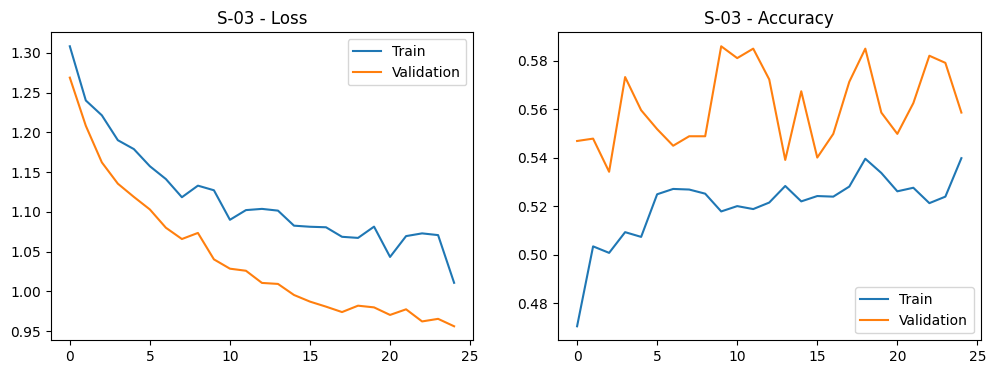


=== CLASSIFICATION REPORT: S-03 ===
              precision    recall  f1-score   support

           0       0.30      0.63      0.41       172
           1       0.26      0.80      0.39        15
           2       0.70      0.64      0.67       634
           3       0.54      0.34      0.42       459

    accuracy                           0.53      1280
   macro avg       0.45      0.60      0.47      1280
weighted avg       0.58      0.53      0.54      1280



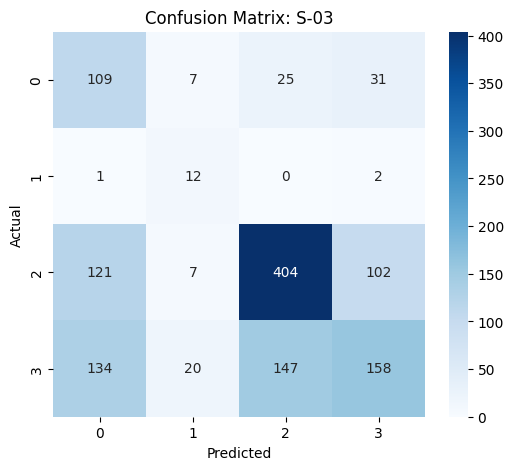

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import numpy as np
import copy
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CONFIG & SETUP
# ==========================================
CONFIG = {
    "lr": 1e-4,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"] # 5120 data
test_data = hf_dataset["test"]      # 1280 data

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

train_labels = np.array(train_data["label"])

# ==========================================
# 3. CLASS WEIGHTS UNTUK LOSS FUNCTION
# ==========================================
print("\nMenghitung Class Weights...")
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts

# Normalisasi bobot agar tidak terlalu besar/kecil (best practice)
class_weights = class_weights / class_weights.sum() * len(class_counts)

# Konversi ke Tensor dan pindahkan ke device
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"Class Weights Tensor: {class_weights_tensor}")

# ==========================================
# 4. DATASET WRAPPER
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

# ==========================================
# 5. DEFINE TRANSFORMS (AUG & NO AUG)
# ==========================================
base_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

aug_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==========================================
# 6. EXPERIMENT FUNCTION (S-01 to S-06 LOGIC)
# ==========================================
def run_experiment(experiment_name, train_transform, opt_type, sched_type):
    print(f"\n{'='*60}")
    print(f"STARTING: {experiment_name} | Opt: {opt_type} | Sched: {sched_type}")
    print(f"{'='*60}")

    # --- Setup DataLoaders (Normal Shuffle, NO WeightedRandomSampler) ---
    train_ds = AlzheimerDataset(train_data, train_transform)
    val_ds   = AlzheimerDataset(val_data, base_transform)
    test_ds  = AlzheimerDataset(test_data, base_transform)

    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])
    val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
    test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

    # --- Setup Model ---
    model = efficientnet_b2(weights=EfficientNet_B2_Weights.DEFAULT)

    # FREEZE SEMUA LAYER FEATURES (Feature Extraction murni)
    for param in model.features.parameters():
        param.requires_grad = False

    num_classes = len(np.unique(train_labels))
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(1408, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )
    model = model.to(device)

    # --- Loss & Optimizers ---
    # CLASS WEIGHT PADA LOSS FUNCTION
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

    trainable_params = filter(lambda p: p.requires_grad, model.parameters())

    if opt_type == 'Adam':
        optimizer = optim.Adam(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'AdamW':
        optimizer = optim.AdamW(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'SGD':
        optimizer = optim.SGD(trainable_params, lr=CONFIG["lr"], momentum=0.9)
    else:
        raise ValueError("Optimizer tidak dikenali!")

    # --- Dynamic Scheduler ---
    if sched_type == 'CosineAnnealingLR':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])
    elif sched_type == 'ReduceLROnPlateau':
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
    else:
        raise ValueError("Scheduler tidak dikenali!")

    # --- Training Loop ---
    train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []
    best_model = copy.deepcopy(model.state_dict())
    best_loss = float("inf")
    counter = 0

    for epoch in range(CONFIG["epochs"]):
        # ===== Train =====
        model.train()
        train_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss /= total
        train_acc = correct / total

        # Step Scheduler (CosineAnnealingLR)
        if sched_type == 'CosineAnnealingLR':
            scheduler.step()

        # ===== Validation =====
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        # Step Scheduler (ReduceLROnPlateau)
        if sched_type == 'ReduceLROnPlateau':
            scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:02d}/{CONFIG['epochs']} | LR: {current_lr:.2e} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        # ===== Early Stopping =====
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= CONFIG["patience"]:
                print("-> Early stopping triggered!")
                break

    # --- Load Best Model & Test ---
    print(f"\nLoading best model for {experiment_name} testing...")
    model.load_state_dict(best_model)

    model.eval()
    all_probs, all_labels, all_preds = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())

    # --- Plotting & Metrics ---
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Validation")
    plt.title(f"{experiment_name} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label="Train")
    plt.plot(val_accuracies, label="Validation")
    plt.title(f"{experiment_name} - Accuracy")
    plt.legend()
    plt.show()

    print(f"\n=== CLASSIFICATION REPORT: {experiment_name} ===")
    print(classification_report(all_labels, all_preds))

    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix: {experiment_name}")
    plt.show()

# ==========================================
# 7. RUN PIPELINES (SCENARIOS S-01 to S-06)
# ==========================================
scenarios = [
    {"name": "S-01", "opt": "Adam",  "sched": "ReduceLROnPlateau"},
    {"name": "S-02", "opt": "Adam",  "sched": "CosineAnnealingLR"},
    {"name": "S-03", "opt": "AdamW", "sched": "ReduceLROnPlateau"},
    # {"name": "S-04", "opt": "AdamW", "sched": "CosineAnnealingLR"},
    # {"name": "S-05", "opt": "SGD",   "sched": "ReduceLROnPlateau"},
    # {"name": "S-06", "opt": "SGD",   "sched": "CosineAnnealingLR"}
]

# Eksekusi loop
for scenario in scenarios:
    run_experiment(
        experiment_name=scenario["name"],
        train_transform=aug_transform, # Wajib augmentasi sesuai request
        opt_type=scenario["opt"],
        sched_type=scenario["sched"]
    )

Device: cuda
Loading dataset...
Train: 4096 | Val: 1024 | Test: 1280

Menghitung Class Weights...
Class Weights Tensor: tensor([0.2419, 3.5916, 0.0682, 0.0983], device='cuda:0')

STARTING: S-04 | Opt: AdamW | Sched: CosineAnnealingLR
Epoch 01/25 | LR: 9.96e-05 | Train Loss: 1.2927 Acc: 0.4673 | Val Loss: 1.2569 Acc: 0.5566
Epoch 02/25 | LR: 9.84e-05 | Train Loss: 1.2352 Acc: 0.5015 | Val Loss: 1.2071 Acc: 0.5596
Epoch 03/25 | LR: 9.65e-05 | Train Loss: 1.2061 Acc: 0.5042 | Val Loss: 1.1652 Acc: 0.5254
Epoch 04/25 | LR: 9.38e-05 | Train Loss: 1.1802 Acc: 0.5164 | Val Loss: 1.1430 Acc: 0.5449
Epoch 05/25 | LR: 9.05e-05 | Train Loss: 1.1699 Acc: 0.5232 | Val Loss: 1.1240 Acc: 0.5527
Epoch 06/25 | LR: 8.64e-05 | Train Loss: 1.1536 Acc: 0.5144 | Val Loss: 1.1141 Acc: 0.5459
Epoch 07/25 | LR: 8.19e-05 | Train Loss: 1.1402 Acc: 0.5210 | Val Loss: 1.0996 Acc: 0.5645
Epoch 08/25 | LR: 7.68e-05 | Train Loss: 1.1414 Acc: 0.5288 | Val Loss: 1.0979 Acc: 0.5713
Epoch 09/25 | LR: 7.13e-05 | Train Los

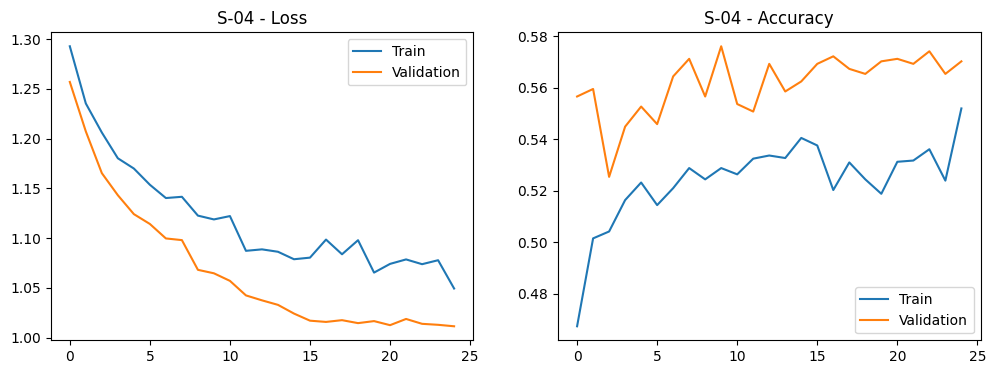


=== CLASSIFICATION REPORT: S-04 ===
              precision    recall  f1-score   support

           0       0.32      0.53      0.40       172
           1       0.21      0.53      0.30        15
           2       0.72      0.63      0.67       634
           3       0.52      0.46      0.49       459

    accuracy                           0.55      1280
   macro avg       0.44      0.54      0.47      1280
weighted avg       0.59      0.55      0.57      1280



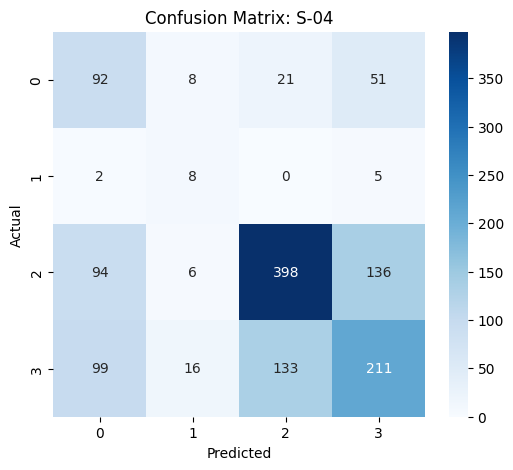


STARTING: S-05 | Opt: SGD | Sched: ReduceLROnPlateau
Epoch 01/25 | LR: 1.00e-04 | Train Loss: 1.3681 Acc: 0.3713 | Val Loss: 1.3522 Acc: 0.4785
Epoch 02/25 | LR: 1.00e-04 | Train Loss: 1.3327 Acc: 0.4036 | Val Loss: 1.3349 Acc: 0.4990
Epoch 03/25 | LR: 1.00e-04 | Train Loss: 1.3202 Acc: 0.4204 | Val Loss: 1.3272 Acc: 0.5029
Epoch 04/25 | LR: 1.00e-04 | Train Loss: 1.3086 Acc: 0.4329 | Val Loss: 1.3173 Acc: 0.5273
Epoch 05/25 | LR: 1.00e-04 | Train Loss: 1.3106 Acc: 0.4426 | Val Loss: 1.3119 Acc: 0.5488
Epoch 06/25 | LR: 1.00e-04 | Train Loss: 1.3078 Acc: 0.4277 | Val Loss: 1.3060 Acc: 0.5498
Epoch 07/25 | LR: 1.00e-04 | Train Loss: 1.2943 Acc: 0.4724 | Val Loss: 1.2991 Acc: 0.5645
Epoch 08/25 | LR: 1.00e-04 | Train Loss: 1.2992 Acc: 0.4653 | Val Loss: 1.2952 Acc: 0.5518
Epoch 09/25 | LR: 1.00e-04 | Train Loss: 1.2882 Acc: 0.4773 | Val Loss: 1.2871 Acc: 0.5674
Epoch 10/25 | LR: 1.00e-04 | Train Loss: 1.2784 Acc: 0.4875 | Val Loss: 1.2816 Acc: 0.5645
Epoch 11/25 | LR: 1.00e-04 | Train L

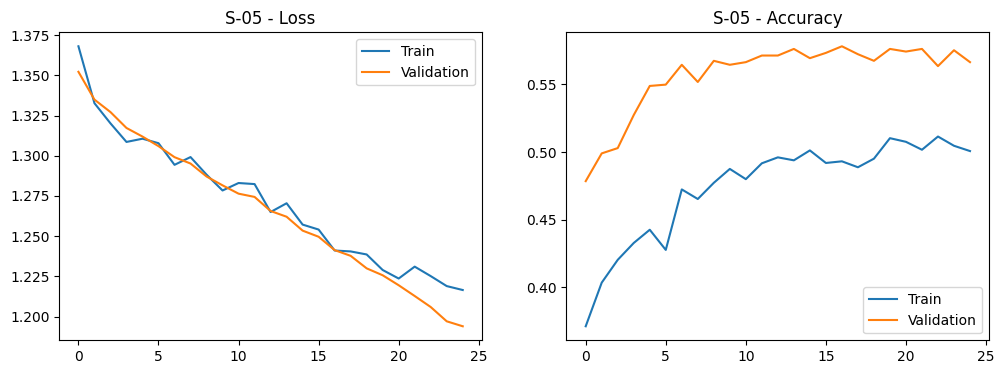


=== CLASSIFICATION REPORT: S-05 ===
              precision    recall  f1-score   support

           0       0.30      0.48      0.37       172
           1       0.00      0.00      0.00        15
           2       0.65      0.68      0.66       634
           3       0.48      0.36      0.41       459

    accuracy                           0.53      1280
   macro avg       0.36      0.38      0.36      1280
weighted avg       0.53      0.53      0.53      1280



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


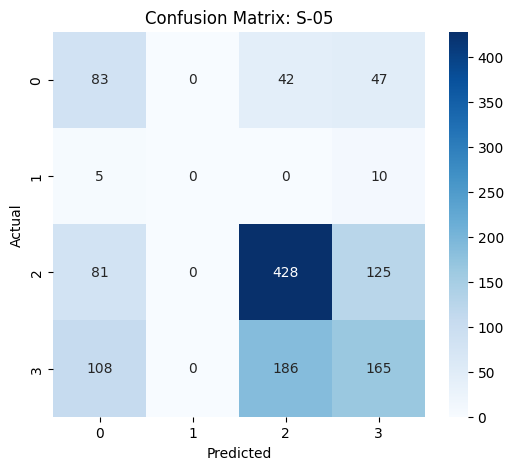


STARTING: S-06 | Opt: SGD | Sched: CosineAnnealingLR
Epoch 01/25 | LR: 9.96e-05 | Train Loss: 1.3722 Acc: 0.3179 | Val Loss: 1.3564 Acc: 0.4199
Epoch 02/25 | LR: 9.84e-05 | Train Loss: 1.3303 Acc: 0.3743 | Val Loss: 1.3403 Acc: 0.4639
Epoch 03/25 | LR: 9.65e-05 | Train Loss: 1.3229 Acc: 0.3953 | Val Loss: 1.3296 Acc: 0.4980
Epoch 04/25 | LR: 9.38e-05 | Train Loss: 1.3152 Acc: 0.4153 | Val Loss: 1.3213 Acc: 0.5039
Epoch 05/25 | LR: 9.05e-05 | Train Loss: 1.3024 Acc: 0.4573 | Val Loss: 1.3150 Acc: 0.5244
Epoch 06/25 | LR: 8.64e-05 | Train Loss: 1.2969 Acc: 0.4473 | Val Loss: 1.3097 Acc: 0.5166
Epoch 07/25 | LR: 8.19e-05 | Train Loss: 1.2927 Acc: 0.4478 | Val Loss: 1.3058 Acc: 0.5322
Epoch 08/25 | LR: 7.68e-05 | Train Loss: 1.2874 Acc: 0.4658 | Val Loss: 1.2993 Acc: 0.5547
Epoch 09/25 | LR: 7.13e-05 | Train Loss: 1.2970 Acc: 0.4695 | Val Loss: 1.2947 Acc: 0.5527
Epoch 10/25 | LR: 6.55e-05 | Train Loss: 1.2932 Acc: 0.4597 | Val Loss: 1.2907 Acc: 0.5537
Epoch 11/25 | LR: 5.94e-05 | Train L

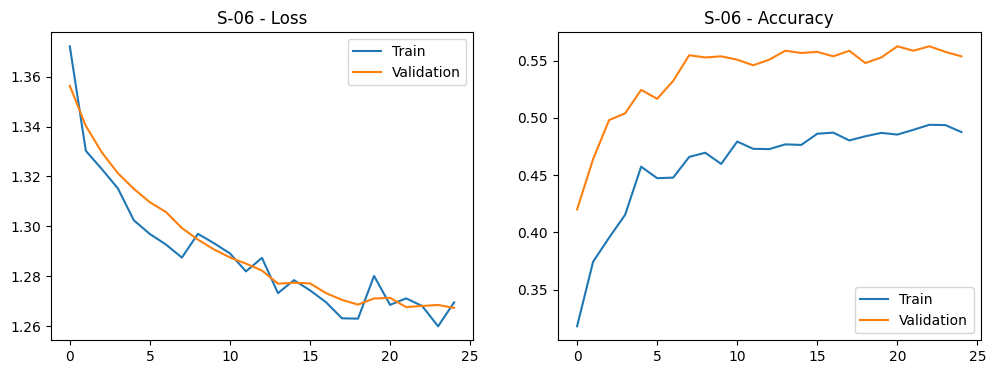


=== CLASSIFICATION REPORT: S-06 ===
              precision    recall  f1-score   support

           0       0.28      0.35      0.31       172
           1       0.00      0.00      0.00        15
           2       0.63      0.68      0.66       634
           3       0.46      0.38      0.42       459

    accuracy                           0.52      1280
   macro avg       0.34      0.35      0.35      1280
weighted avg       0.52      0.52      0.52      1280



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


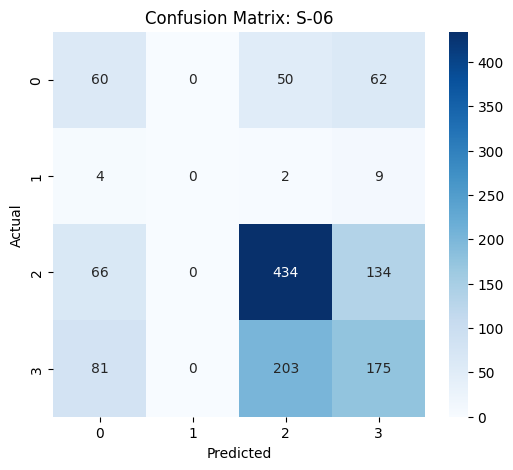

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import numpy as np
import copy
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CONFIG & SETUP
# ==========================================
CONFIG = {
    "lr": 1e-4,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"] # 5120 data
test_data = hf_dataset["test"]      # 1280 data

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

train_labels = np.array(train_data["label"])

# ==========================================
# 3. CLASS WEIGHTS UNTUK LOSS FUNCTION
# ==========================================
print("\nMenghitung Class Weights...")
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts

# Normalisasi bobot agar tidak terlalu besar/kecil (best practice)
class_weights = class_weights / class_weights.sum() * len(class_counts)

# Konversi ke Tensor dan pindahkan ke device
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"Class Weights Tensor: {class_weights_tensor}")

# ==========================================
# 4. DATASET WRAPPER
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

# ==========================================
# 5. DEFINE TRANSFORMS (AUG & NO AUG)
# ==========================================
base_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

aug_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==========================================
# 6. EXPERIMENT FUNCTION (S-01 to S-06 LOGIC)
# ==========================================
def run_experiment(experiment_name, train_transform, opt_type, sched_type):
    print(f"\n{'='*60}")
    print(f"STARTING: {experiment_name} | Opt: {opt_type} | Sched: {sched_type}")
    print(f"{'='*60}")

    # --- Setup DataLoaders (Normal Shuffle, NO WeightedRandomSampler) ---
    train_ds = AlzheimerDataset(train_data, train_transform)
    val_ds   = AlzheimerDataset(val_data, base_transform)
    test_ds  = AlzheimerDataset(test_data, base_transform)

    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])
    val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
    test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

    # --- Setup Model ---
    model = efficientnet_b2(weights=EfficientNet_B2_Weights.DEFAULT)

    # FREEZE SEMUA LAYER FEATURES (Feature Extraction murni)
    for param in model.features.parameters():
        param.requires_grad = False

    num_classes = len(np.unique(train_labels))
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(1408, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )
    model = model.to(device)

    # --- Loss & Optimizers ---
    # CLASS WEIGHT PADA LOSS FUNCTION
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

    trainable_params = filter(lambda p: p.requires_grad, model.parameters())

    if opt_type == 'Adam':
        optimizer = optim.Adam(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'AdamW':
        optimizer = optim.AdamW(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'SGD':
        optimizer = optim.SGD(trainable_params, lr=CONFIG["lr"], momentum=0.9)
    else:
        raise ValueError("Optimizer tidak dikenali!")

    # --- Dynamic Scheduler ---
    if sched_type == 'CosineAnnealingLR':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])
    elif sched_type == 'ReduceLROnPlateau':
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
    else:
        raise ValueError("Scheduler tidak dikenali!")

    # --- Training Loop ---
    train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []
    best_model = copy.deepcopy(model.state_dict())
    best_loss = float("inf")
    counter = 0

    for epoch in range(CONFIG["epochs"]):
        # ===== Train =====
        model.train()
        train_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss /= total
        train_acc = correct / total

        # Step Scheduler (CosineAnnealingLR)
        if sched_type == 'CosineAnnealingLR':
            scheduler.step()

        # ===== Validation =====
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        # Step Scheduler (ReduceLROnPlateau)
        if sched_type == 'ReduceLROnPlateau':
            scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:02d}/{CONFIG['epochs']} | LR: {current_lr:.2e} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        # ===== Early Stopping =====
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= CONFIG["patience"]:
                print("-> Early stopping triggered!")
                break

    # --- Load Best Model & Test ---
    print(f"\nLoading best model for {experiment_name} testing...")
    model.load_state_dict(best_model)

    model.eval()
    all_probs, all_labels, all_preds = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())

    # --- Plotting & Metrics ---
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Validation")
    plt.title(f"{experiment_name} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label="Train")
    plt.plot(val_accuracies, label="Validation")
    plt.title(f"{experiment_name} - Accuracy")
    plt.legend()
    plt.show()

    print(f"\n=== CLASSIFICATION REPORT: {experiment_name} ===")
    print(classification_report(all_labels, all_preds))

    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix: {experiment_name}")
    plt.show()

# ==========================================
# 7. RUN PIPELINES (SCENARIOS S-01 to S-06)
# ==========================================
scenarios = [
    # {"name": "S-01", "opt": "Adam",  "sched": "ReduceLROnPlateau"},
    # {"name": "S-02", "opt": "Adam",  "sched": "CosineAnnealingLR"},
    # {"name": "S-03", "opt": "AdamW", "sched": "ReduceLROnPlateau"},
    {"name": "S-04", "opt": "AdamW", "sched": "CosineAnnealingLR"},
    {"name": "S-05", "opt": "SGD",   "sched": "ReduceLROnPlateau"},
    {"name": "S-06", "opt": "SGD",   "sched": "CosineAnnealingLR"}
]

# Eksekusi loop
for scenario in scenarios:
    run_experiment(
        experiment_name=scenario["name"],
        train_transform=aug_transform, # Wajib augmentasi sesuai request
        opt_type=scenario["opt"],
        sched_type=scenario["sched"]
    )

Device: cuda
Loading dataset...
Train: 4096 | Val: 1024 | Test: 1280

Menghitung Class Weights...
Class Weights Tensor: tensor([0.2419, 3.5916, 0.0682, 0.0983], device='cuda:0')

STARTING: S-07 | Opt: Adam | Sched: ReduceLROnPlateau
Epoch 01/25 | LR: 1.00e-04 | Train Loss: 1.1932 Acc: 0.4963 | Val Loss: 1.0198 Acc: 0.5225
Epoch 02/25 | LR: 1.00e-04 | Train Loss: 0.9689 Acc: 0.5464 | Val Loss: 0.7875 Acc: 0.5879
Epoch 03/25 | LR: 1.00e-04 | Train Loss: 0.8118 Acc: 0.5977 | Val Loss: 0.7309 Acc: 0.6719
Epoch 04/25 | LR: 1.00e-04 | Train Loss: 0.6887 Acc: 0.6519 | Val Loss: 0.6404 Acc: 0.7148
Epoch 05/25 | LR: 1.00e-04 | Train Loss: 0.6847 Acc: 0.6897 | Val Loss: 0.5375 Acc: 0.7393
Epoch 06/25 | LR: 1.00e-04 | Train Loss: 0.5585 Acc: 0.7375 | Val Loss: 0.4779 Acc: 0.7148
Epoch 07/25 | LR: 1.00e-04 | Train Loss: 0.4689 Acc: 0.7681 | Val Loss: 0.3913 Acc: 0.7861
Epoch 08/25 | LR: 1.00e-04 | Train Loss: 0.4460 Acc: 0.7932 | Val Loss: 0.4669 Acc: 0.7559
Epoch 09/25 | LR: 1.00e-04 | Train Loss

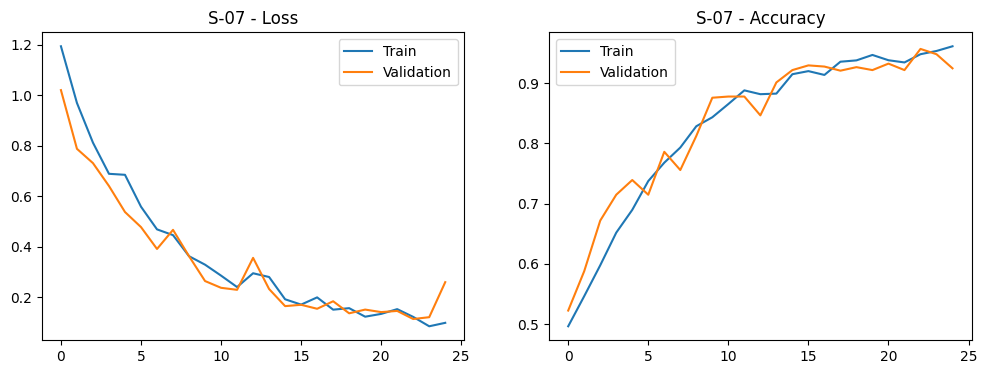


=== CLASSIFICATION REPORT: S-07 ===
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       172
           1       1.00      1.00      1.00        15
           2       0.96      0.98      0.97       634
           3       0.98      0.95      0.96       459

    accuracy                           0.97      1280
   macro avg       0.97      0.97      0.97      1280
weighted avg       0.97      0.97      0.97      1280



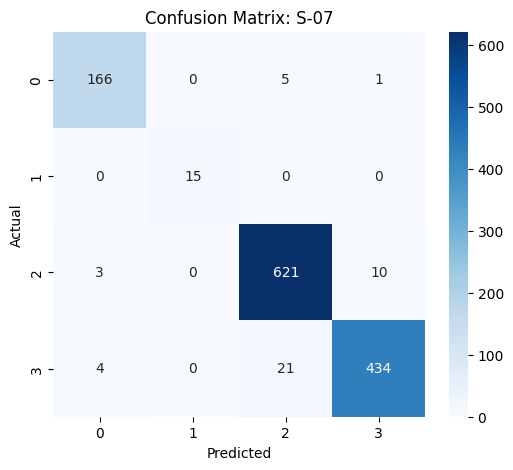


STARTING: S-08 | Opt: Adam | Sched: CosineAnnealingLR
Epoch 01/25 | LR: 9.96e-05 | Train Loss: 1.1928 Acc: 0.4705 | Val Loss: 0.9923 Acc: 0.5342
Epoch 02/25 | LR: 9.84e-05 | Train Loss: 0.9654 Acc: 0.5496 | Val Loss: 0.8596 Acc: 0.5918
Epoch 03/25 | LR: 9.65e-05 | Train Loss: 0.8165 Acc: 0.5947 | Val Loss: 0.7397 Acc: 0.6592
Epoch 04/25 | LR: 9.38e-05 | Train Loss: 0.7236 Acc: 0.6509 | Val Loss: 0.6628 Acc: 0.6768
Epoch 05/25 | LR: 9.05e-05 | Train Loss: 0.6246 Acc: 0.6895 | Val Loss: 0.5184 Acc: 0.7549
Epoch 06/25 | LR: 8.64e-05 | Train Loss: 0.5552 Acc: 0.7363 | Val Loss: 0.4404 Acc: 0.7871
Epoch 07/25 | LR: 8.19e-05 | Train Loss: 0.4904 Acc: 0.7646 | Val Loss: 0.4007 Acc: 0.7949
Epoch 08/25 | LR: 7.68e-05 | Train Loss: 0.4183 Acc: 0.7993 | Val Loss: 0.3582 Acc: 0.8184
Epoch 09/25 | LR: 7.13e-05 | Train Loss: 0.3495 Acc: 0.8333 | Val Loss: 0.3118 Acc: 0.8564
Epoch 10/25 | LR: 6.55e-05 | Train Loss: 0.3208 Acc: 0.8474 | Val Loss: 0.2695 Acc: 0.8594
Epoch 11/25 | LR: 5.94e-05 | Train 

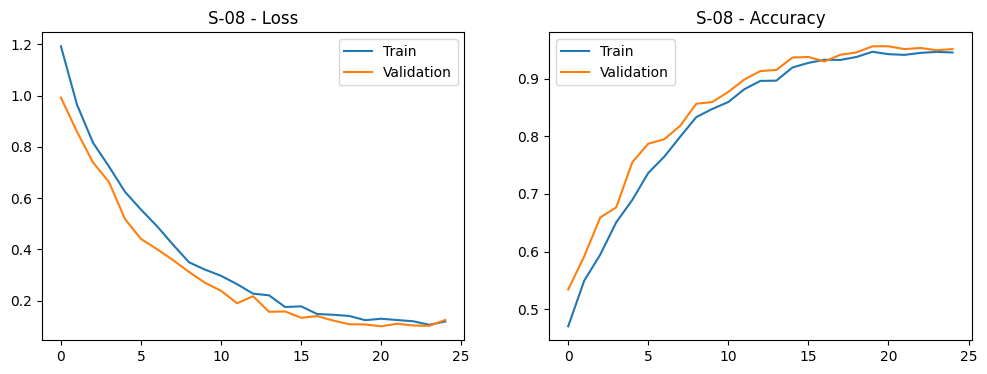


=== CLASSIFICATION REPORT: S-08 ===
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       172
           1       1.00      1.00      1.00        15
           2       0.97      0.96      0.96       634
           3       0.95      0.95      0.95       459

    accuracy                           0.96      1280
   macro avg       0.97      0.97      0.97      1280
weighted avg       0.96      0.96      0.96      1280



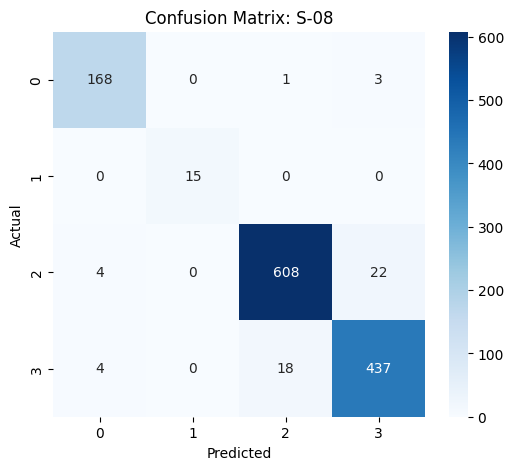


STARTING: S-09 | Opt: AdamW | Sched: ReduceLROnPlateau
Epoch 01/25 | LR: 1.00e-04 | Train Loss: 1.1865 Acc: 0.4790 | Val Loss: 0.9952 Acc: 0.5312
Epoch 02/25 | LR: 1.00e-04 | Train Loss: 0.9495 Acc: 0.5596 | Val Loss: 0.7637 Acc: 0.6514
Epoch 03/25 | LR: 1.00e-04 | Train Loss: 0.7896 Acc: 0.6147 | Val Loss: 0.7900 Acc: 0.6426
Epoch 04/25 | LR: 1.00e-04 | Train Loss: 0.6952 Acc: 0.6697 | Val Loss: 0.5796 Acc: 0.7373
Epoch 05/25 | LR: 1.00e-04 | Train Loss: 0.6118 Acc: 0.7104 | Val Loss: 0.6300 Acc: 0.7373
Epoch 06/25 | LR: 1.00e-04 | Train Loss: 0.5502 Acc: 0.7427 | Val Loss: 0.4562 Acc: 0.7803
Epoch 07/25 | LR: 1.00e-04 | Train Loss: 0.4681 Acc: 0.7844 | Val Loss: 0.4672 Acc: 0.7949
Epoch 08/25 | LR: 1.00e-04 | Train Loss: 0.4093 Acc: 0.8167 | Val Loss: 0.3936 Acc: 0.8340
Epoch 09/25 | LR: 1.00e-04 | Train Loss: 0.3717 Acc: 0.8247 | Val Loss: 0.3189 Acc: 0.8633
Epoch 10/25 | LR: 1.00e-04 | Train Loss: 0.3226 Acc: 0.8499 | Val Loss: 0.2654 Acc: 0.8867
Epoch 11/25 | LR: 1.00e-04 | Train

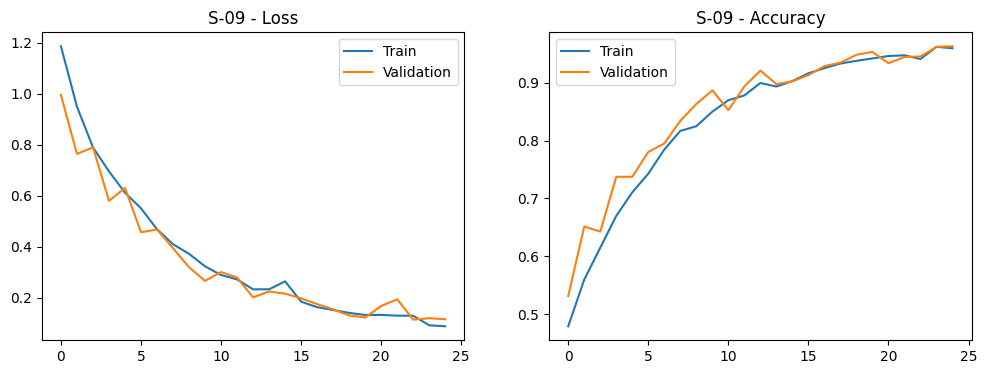


=== CLASSIFICATION REPORT: S-09 ===
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       172
           1       1.00      1.00      1.00        15
           2       0.99      0.93      0.96       634
           3       0.91      0.97      0.94       459

    accuracy                           0.95      1280
   macro avg       0.96      0.97      0.96      1280
weighted avg       0.95      0.95      0.95      1280



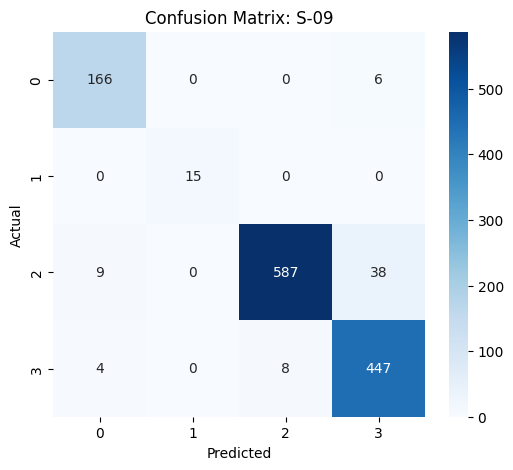

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import numpy as np
import copy
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CONFIG & SETUP
# ==========================================
CONFIG = {
    "lr": 1e-4,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"] # 5120 data
test_data = hf_dataset["test"]      # 1280 data

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

train_labels = np.array(train_data["label"])

# ==========================================
# 3. CLASS WEIGHTS UNTUK LOSS FUNCTION
# ==========================================
print("\nMenghitung Class Weights...")
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts

# Normalisasi bobot agar tidak terlalu besar/kecil (best practice)
class_weights = class_weights / class_weights.sum() * len(class_counts)

# Konversi ke Tensor dan pindahkan ke device
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"Class Weights Tensor: {class_weights_tensor}")

# ==========================================
# 4. DATASET WRAPPER
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

# ==========================================
# 5. DEFINE TRANSFORMS (AUG & NO AUG)
# ==========================================
base_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

aug_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==========================================
# 6. EXPERIMENT FUNCTION (UNFREEZE LAST LAYERS)
# ==========================================
def run_experiment(experiment_name, train_transform, opt_type, sched_type):
    print(f"\n{'='*60}")
    print(f"STARTING: {experiment_name} | Opt: {opt_type} | Sched: {sched_type}")
    print(f"{'='*60}")

    # --- Setup DataLoaders (Normal Shuffle, NO WeightedRandomSampler) ---
    train_ds = AlzheimerDataset(train_data, train_transform)
    val_ds   = AlzheimerDataset(val_data, base_transform)
    test_ds  = AlzheimerDataset(test_data, base_transform)

    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])
    val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
    test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

    # --- Setup Model ---
    model = efficientnet_b2(weights=EfficientNet_B2_Weights.DEFAULT)

    # 1. Freeze semua layer terlebih dahulu
    for param in model.features.parameters():
        param.requires_grad = False

    # 2. Unfreeze 4 layer terakhir di block features
    for param in model.features[-4:].parameters():
        param.requires_grad = True

    num_classes = len(np.unique(train_labels))
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(1408, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )
    model = model.to(device)

    # --- Loss & Optimizers ---
    # CLASS WEIGHT PADA LOSS FUNCTION
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

    # trainable_params akan otomatis mengambil classifier DAN 4 layer terakhir yang di-unfreeze
    trainable_params = filter(lambda p: p.requires_grad, model.parameters())

    if opt_type == 'Adam':
        optimizer = optim.Adam(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'AdamW':
        optimizer = optim.AdamW(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'SGD':
        optimizer = optim.SGD(trainable_params, lr=CONFIG["lr"], momentum=0.9)
    else:
        raise ValueError("Optimizer tidak dikenali!")

    # --- Dynamic Scheduler ---
    if sched_type == 'CosineAnnealingLR':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])
    elif sched_type == 'ReduceLROnPlateau':
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
    else:
        raise ValueError("Scheduler tidak dikenali!")

    # --- Training Loop ---
    train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []
    best_model = copy.deepcopy(model.state_dict())
    best_loss = float("inf")
    counter = 0

    for epoch in range(CONFIG["epochs"]):
        # ===== Train =====
        model.train()
        train_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss /= total
        train_acc = correct / total

        # Step Scheduler (CosineAnnealingLR)
        if sched_type == 'CosineAnnealingLR':
            scheduler.step()

        # ===== Validation =====
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        # Step Scheduler (ReduceLROnPlateau)
        if sched_type == 'ReduceLROnPlateau':
            scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:02d}/{CONFIG['epochs']} | LR: {current_lr:.2e} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        # ===== Early Stopping =====
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= CONFIG["patience"]:
                print("-> Early stopping triggered!")
                break

    # --- Load Best Model & Test ---
    print(f"\nLoading best model for {experiment_name} testing...")
    model.load_state_dict(best_model)

    model.eval()
    all_probs, all_labels, all_preds = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())

    # --- Plotting & Metrics ---
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Validation")
    plt.title(f"{experiment_name} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label="Train")
    plt.plot(val_accuracies, label="Validation")
    plt.title(f"{experiment_name} - Accuracy")
    plt.legend()
    plt.show()

    print(f"\n=== CLASSIFICATION REPORT: {experiment_name} ===")
    print(classification_report(all_labels, all_preds))

    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix: {experiment_name}")
    plt.show()

# ==========================================
# 7. RUN PIPELINES (SCENARIOS S-07 to S-12)
# ==========================================
scenarios_unfreeze = [
    {"name": "S-07", "opt": "Adam",  "sched": "ReduceLROnPlateau"},
    {"name": "S-08", "opt": "Adam",  "sched": "CosineAnnealingLR"},
    {"name": "S-09", "opt": "AdamW", "sched": "ReduceLROnPlateau"},
    # {"name": "S-10", "opt": "AdamW", "sched": "CosineAnnealingLR"},
    # {"name": "S-11", "opt": "SGD",   "sched": "ReduceLROnPlateau"},
    # {"name": "S-12", "opt": "SGD",   "sched": "CosineAnnealingLR"}
]

# Eksekusi loop untuk skenario Unfreeze Layer Terakhir
for scenario in scenarios_unfreeze:
    run_experiment(
        experiment_name=scenario["name"],
        train_transform=aug_transform, # Menggunakan augmentasi
        opt_type=scenario["opt"],
        sched_type=scenario["sched"]
    )

Device: cuda
Loading dataset...
Train: 4096 | Val: 1024 | Test: 1280

Menghitung Class Weights...
Class Weights Tensor: tensor([0.2419, 3.5916, 0.0682, 0.0983], device='cuda:0')

STARTING: S-10 | Opt: AdamW | Sched: CosineAnnealingLR
Epoch 01/25 | LR: 9.96e-05 | Train Loss: 1.1739 Acc: 0.4990 | Val Loss: 0.9443 Acc: 0.6074
Epoch 02/25 | LR: 9.84e-05 | Train Loss: 0.9086 Acc: 0.5642 | Val Loss: 0.7519 Acc: 0.6152
Epoch 03/25 | LR: 9.65e-05 | Train Loss: 0.7872 Acc: 0.6184 | Val Loss: 0.7395 Acc: 0.6387
Epoch 04/25 | LR: 9.38e-05 | Train Loss: 0.6922 Acc: 0.6799 | Val Loss: 0.5820 Acc: 0.7158
Epoch 05/25 | LR: 9.05e-05 | Train Loss: 0.6351 Acc: 0.6997 | Val Loss: 0.5273 Acc: 0.7422
Epoch 06/25 | LR: 8.64e-05 | Train Loss: 0.5108 Acc: 0.7542 | Val Loss: 0.4565 Acc: 0.7754
Epoch 07/25 | LR: 8.19e-05 | Train Loss: 0.4490 Acc: 0.7908 | Val Loss: 0.3978 Acc: 0.7832
Epoch 08/25 | LR: 7.68e-05 | Train Loss: 0.4120 Acc: 0.8103 | Val Loss: 0.3713 Acc: 0.8447
Epoch 09/25 | LR: 7.13e-05 | Train Los

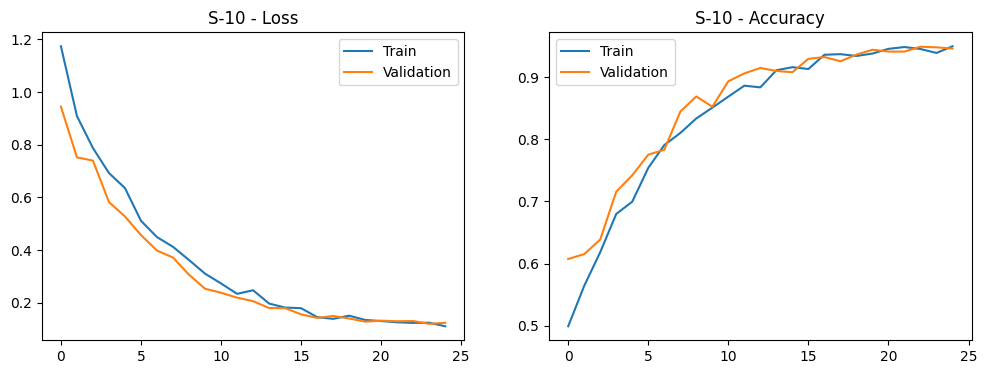


=== CLASSIFICATION REPORT: S-10 ===
              precision    recall  f1-score   support

           0       0.94      0.97      0.96       172
           1       1.00      1.00      1.00        15
           2       0.98      0.93      0.95       634
           3       0.91      0.97      0.94       459

    accuracy                           0.95      1280
   macro avg       0.96      0.97      0.96      1280
weighted avg       0.95      0.95      0.95      1280



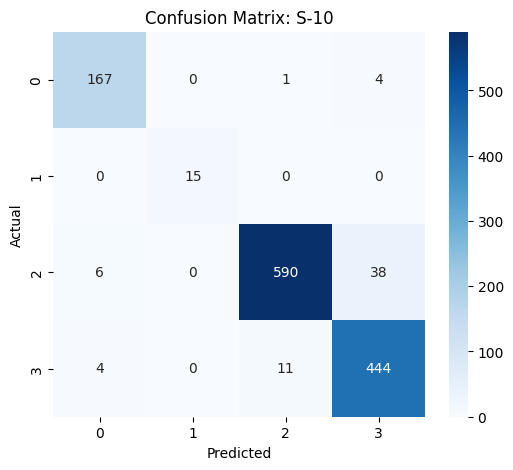


STARTING: S-11 | Opt: SGD | Sched: ReduceLROnPlateau
Epoch 01/25 | LR: 1.00e-04 | Train Loss: 1.3596 Acc: 0.3264 | Val Loss: 1.3537 Acc: 0.3125
Epoch 02/25 | LR: 1.00e-04 | Train Loss: 1.3373 Acc: 0.3979 | Val Loss: 1.3349 Acc: 0.4463
Epoch 03/25 | LR: 1.00e-04 | Train Loss: 1.3210 Acc: 0.4089 | Val Loss: 1.3234 Acc: 0.5195
Epoch 04/25 | LR: 1.00e-04 | Train Loss: 1.2970 Acc: 0.4705 | Val Loss: 1.3097 Acc: 0.5332
Epoch 05/25 | LR: 1.00e-04 | Train Loss: 1.3015 Acc: 0.4668 | Val Loss: 1.3002 Acc: 0.5332
Epoch 06/25 | LR: 1.00e-04 | Train Loss: 1.2914 Acc: 0.4592 | Val Loss: 1.2900 Acc: 0.5293
Epoch 07/25 | LR: 1.00e-04 | Train Loss: 1.2719 Acc: 0.4783 | Val Loss: 1.2766 Acc: 0.5469
Epoch 08/25 | LR: 1.00e-04 | Train Loss: 1.2701 Acc: 0.4980 | Val Loss: 1.2638 Acc: 0.5479
Epoch 09/25 | LR: 1.00e-04 | Train Loss: 1.2471 Acc: 0.4922 | Val Loss: 1.2518 Acc: 0.5488
Epoch 10/25 | LR: 1.00e-04 | Train Loss: 1.2355 Acc: 0.5046 | Val Loss: 1.2385 Acc: 0.5547
Epoch 11/25 | LR: 1.00e-04 | Train L

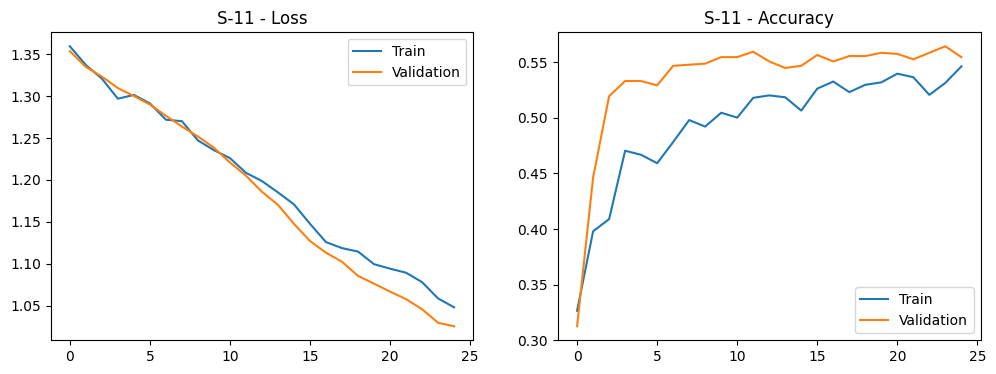


=== CLASSIFICATION REPORT: S-11 ===
              precision    recall  f1-score   support

           0       0.28      0.73      0.41       172
           1       0.00      0.00      0.00        15
           2       0.73      0.67      0.70       634
           3       0.50      0.28      0.36       459

    accuracy                           0.53      1280
   macro avg       0.38      0.42      0.37      1280
weighted avg       0.58      0.53      0.53      1280



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


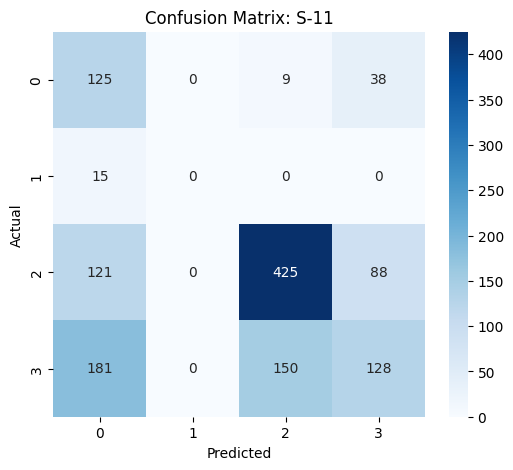


STARTING: S-12 | Opt: SGD | Sched: CosineAnnealingLR
Epoch 01/25 | LR: 9.96e-05 | Train Loss: 1.3609 Acc: 0.3474 | Val Loss: 1.3537 Acc: 0.4062
Epoch 02/25 | LR: 9.84e-05 | Train Loss: 1.3362 Acc: 0.3928 | Val Loss: 1.3375 Acc: 0.4902
Epoch 03/25 | LR: 9.65e-05 | Train Loss: 1.3180 Acc: 0.4346 | Val Loss: 1.3271 Acc: 0.5127
Epoch 04/25 | LR: 9.38e-05 | Train Loss: 1.3115 Acc: 0.4504 | Val Loss: 1.3161 Acc: 0.5264
Epoch 05/25 | LR: 9.05e-05 | Train Loss: 1.3054 Acc: 0.4590 | Val Loss: 1.3047 Acc: 0.5400
Epoch 06/25 | LR: 8.64e-05 | Train Loss: 1.2815 Acc: 0.4592 | Val Loss: 1.2944 Acc: 0.5400
Epoch 07/25 | LR: 8.19e-05 | Train Loss: 1.2844 Acc: 0.4741 | Val Loss: 1.2872 Acc: 0.5400
Epoch 08/25 | LR: 7.68e-05 | Train Loss: 1.2750 Acc: 0.4888 | Val Loss: 1.2782 Acc: 0.5537
Epoch 09/25 | LR: 7.13e-05 | Train Loss: 1.2715 Acc: 0.4856 | Val Loss: 1.2672 Acc: 0.5713
Epoch 10/25 | LR: 6.55e-05 | Train Loss: 1.2575 Acc: 0.4868 | Val Loss: 1.2595 Acc: 0.5723
Epoch 11/25 | LR: 5.94e-05 | Train L

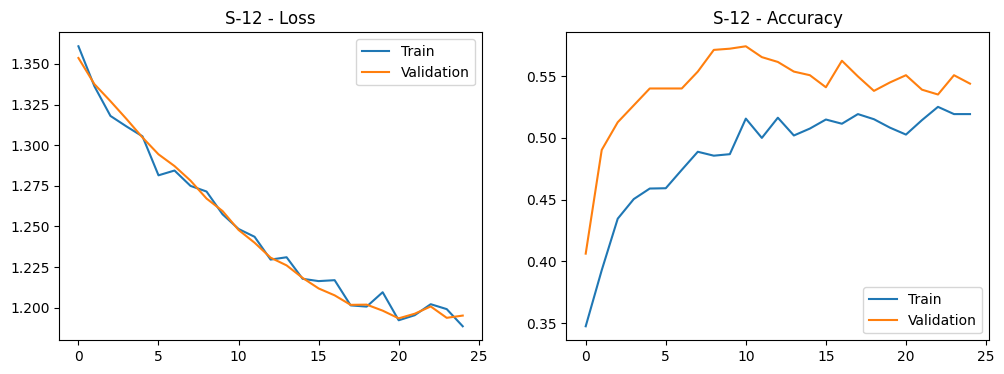


=== CLASSIFICATION REPORT: S-12 ===
              precision    recall  f1-score   support

           0       0.29      0.51      0.37       172
           1       0.00      0.00      0.00        15
           2       0.65      0.70      0.67       634
           3       0.46      0.29      0.35       459

    accuracy                           0.52      1280
   macro avg       0.35      0.37      0.35      1280
weighted avg       0.52      0.52      0.51      1280



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


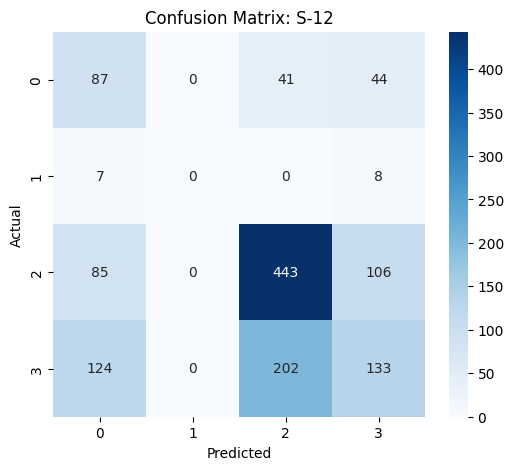

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import numpy as np
import copy
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CONFIG & SETUP
# ==========================================
CONFIG = {
    "lr": 1e-4,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"] # 5120 data
test_data = hf_dataset["test"]      # 1280 data

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

train_labels = np.array(train_data["label"])

# ==========================================
# 3. CLASS WEIGHTS UNTUK LOSS FUNCTION
# ==========================================
print("\nMenghitung Class Weights...")
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts

# Normalisasi bobot agar tidak terlalu besar/kecil (best practice)
class_weights = class_weights / class_weights.sum() * len(class_counts)

# Konversi ke Tensor dan pindahkan ke device
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"Class Weights Tensor: {class_weights_tensor}")

# ==========================================
# 4. DATASET WRAPPER
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

# ==========================================
# 5. DEFINE TRANSFORMS (AUG & NO AUG)
# ==========================================
base_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

aug_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==========================================
# 6. EXPERIMENT FUNCTION (UNFREEZE LAST LAYERS)
# ==========================================
def run_experiment(experiment_name, train_transform, opt_type, sched_type):
    print(f"\n{'='*60}")
    print(f"STARTING: {experiment_name} | Opt: {opt_type} | Sched: {sched_type}")
    print(f"{'='*60}")

    # --- Setup DataLoaders (Normal Shuffle, NO WeightedRandomSampler) ---
    train_ds = AlzheimerDataset(train_data, train_transform)
    val_ds   = AlzheimerDataset(val_data, base_transform)
    test_ds  = AlzheimerDataset(test_data, base_transform)

    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])
    val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
    test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

    # --- Setup Model ---
    model = efficientnet_b2(weights=EfficientNet_B2_Weights.DEFAULT)

    # 1. Freeze semua layer terlebih dahulu
    for param in model.features.parameters():
        param.requires_grad = False

    # 2. Unfreeze 4 layer terakhir di block features
    for param in model.features[-4:].parameters():
        param.requires_grad = True

    num_classes = len(np.unique(train_labels))
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(1408, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )
    model = model.to(device)

    # --- Loss & Optimizers ---
    # CLASS WEIGHT PADA LOSS FUNCTION
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

    # trainable_params akan otomatis mengambil classifier DAN 4 layer terakhir yang di-unfreeze
    trainable_params = filter(lambda p: p.requires_grad, model.parameters())

    if opt_type == 'Adam':
        optimizer = optim.Adam(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'AdamW':
        optimizer = optim.AdamW(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'SGD':
        optimizer = optim.SGD(trainable_params, lr=CONFIG["lr"], momentum=0.9)
    else:
        raise ValueError("Optimizer tidak dikenali!")

    # --- Dynamic Scheduler ---
    if sched_type == 'CosineAnnealingLR':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])
    elif sched_type == 'ReduceLROnPlateau':
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
    else:
        raise ValueError("Scheduler tidak dikenali!")

    # --- Training Loop ---
    train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []
    best_model = copy.deepcopy(model.state_dict())
    best_loss = float("inf")
    counter = 0

    for epoch in range(CONFIG["epochs"]):
        # ===== Train =====
        model.train()
        train_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss /= total
        train_acc = correct / total

        # Step Scheduler (CosineAnnealingLR)
        if sched_type == 'CosineAnnealingLR':
            scheduler.step()

        # ===== Validation =====
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        # Step Scheduler (ReduceLROnPlateau)
        if sched_type == 'ReduceLROnPlateau':
            scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:02d}/{CONFIG['epochs']} | LR: {current_lr:.2e} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        # ===== Early Stopping =====
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= CONFIG["patience"]:
                print("-> Early stopping triggered!")
                break

    # --- Load Best Model & Test ---
    print(f"\nLoading best model for {experiment_name} testing...")
    model.load_state_dict(best_model)

    model.eval()
    all_probs, all_labels, all_preds = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())

    # --- Plotting & Metrics ---
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Validation")
    plt.title(f"{experiment_name} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label="Train")
    plt.plot(val_accuracies, label="Validation")
    plt.title(f"{experiment_name} - Accuracy")
    plt.legend()
    plt.show()

    print(f"\n=== CLASSIFICATION REPORT: {experiment_name} ===")
    print(classification_report(all_labels, all_preds))

    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix: {experiment_name}")
    plt.show()

# ==========================================
# 7. RUN PIPELINES (SCENARIOS S-07 to S-12)
# ==========================================
scenarios_unfreeze = [
    # {"name": "S-07", "opt": "Adam",  "sched": "ReduceLROnPlateau"},
    # {"name": "S-08", "opt": "Adam",  "sched": "CosineAnnealingLR"},
    # {"name": "S-09", "opt": "AdamW", "sched": "ReduceLROnPlateau"},
    {"name": "S-10", "opt": "AdamW", "sched": "CosineAnnealingLR"},
    {"name": "S-11", "opt": "SGD",   "sched": "ReduceLROnPlateau"},
    {"name": "S-12", "opt": "SGD",   "sched": "CosineAnnealingLR"}
]

# Eksekusi loop untuk skenario Unfreeze Layer Terakhir
for scenario in scenarios_unfreeze:
    run_experiment(
        experiment_name=scenario["name"],
        train_transform=aug_transform, # Menggunakan augmentasi
        opt_type=scenario["opt"],
        sched_type=scenario["sched"]
    )

Device: cuda
Loading dataset...
Train: 4096 | Val: 1024 | Test: 1280

Menghitung Class Weights...
Class Weights Tensor: tensor([0.2419, 3.5916, 0.0682, 0.0983], device='cuda:0')

STARTING: S-13 | Opt: Adam | Sched: ReduceLROnPlateau
Epoch 01/25 | LR: 1.00e-04 | Train Loss: 1.1743 Acc: 0.4934 | Val Loss: 0.9403 Acc: 0.5283
Epoch 02/25 | LR: 1.00e-04 | Train Loss: 0.9171 Acc: 0.5613 | Val Loss: 0.7567 Acc: 0.6338
Epoch 03/25 | LR: 1.00e-04 | Train Loss: 0.7361 Acc: 0.6433 | Val Loss: 0.6270 Acc: 0.6777
Epoch 04/25 | LR: 1.00e-04 | Train Loss: 0.6347 Acc: 0.6934 | Val Loss: 0.4883 Acc: 0.7764
Epoch 05/25 | LR: 1.00e-04 | Train Loss: 0.5390 Acc: 0.7598 | Val Loss: 0.3585 Acc: 0.8320
Epoch 06/25 | LR: 1.00e-04 | Train Loss: 0.3835 Acc: 0.8184 | Val Loss: 0.3169 Acc: 0.8643
Epoch 07/25 | LR: 1.00e-04 | Train Loss: 0.3404 Acc: 0.8430 | Val Loss: 0.2383 Acc: 0.8789
Epoch 08/25 | LR: 1.00e-04 | Train Loss: 0.2964 Acc: 0.8745 | Val Loss: 0.1937 Acc: 0.9131
Epoch 09/25 | LR: 1.00e-04 | Train Loss

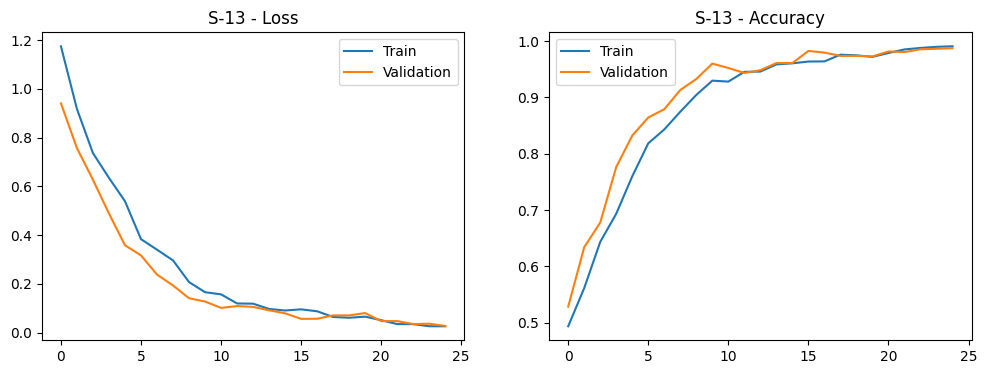


=== CLASSIFICATION REPORT: S-13 ===
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       172
           1       1.00      1.00      1.00        15
           2       0.99      1.00      0.99       634
           3       0.99      0.99      0.99       459

    accuracy                           0.99      1280
   macro avg       0.99      0.99      0.99      1280
weighted avg       0.99      0.99      0.99      1280



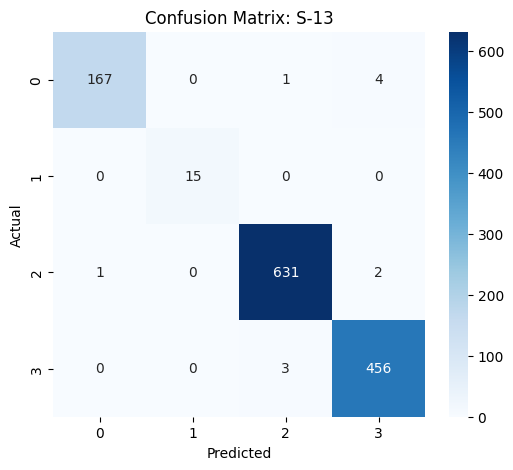


STARTING: S-14 | Opt: Adam | Sched: CosineAnnealingLR
Epoch 01/25 | LR: 9.96e-05 | Train Loss: 1.1613 Acc: 0.4724 | Val Loss: 0.9652 Acc: 0.5879
Epoch 02/25 | LR: 9.84e-05 | Train Loss: 0.9053 Acc: 0.5671 | Val Loss: 0.7525 Acc: 0.6396
Epoch 03/25 | LR: 9.65e-05 | Train Loss: 0.7075 Acc: 0.6548 | Val Loss: 0.5762 Acc: 0.6924
Epoch 04/25 | LR: 9.38e-05 | Train Loss: 0.5711 Acc: 0.7341 | Val Loss: 0.4468 Acc: 0.7852
Epoch 05/25 | LR: 9.05e-05 | Train Loss: 0.4612 Acc: 0.7927 | Val Loss: 0.3544 Acc: 0.8350
Epoch 06/25 | LR: 8.64e-05 | Train Loss: 0.3928 Acc: 0.8340 | Val Loss: 0.3189 Acc: 0.8359
Epoch 07/25 | LR: 8.19e-05 | Train Loss: 0.2900 Acc: 0.8660 | Val Loss: 0.1943 Acc: 0.9033
Epoch 08/25 | LR: 7.68e-05 | Train Loss: 0.2398 Acc: 0.8933 | Val Loss: 0.1602 Acc: 0.9082
Epoch 09/25 | LR: 7.13e-05 | Train Loss: 0.1621 Acc: 0.9209 | Val Loss: 0.1288 Acc: 0.9453
Epoch 10/25 | LR: 6.55e-05 | Train Loss: 0.1545 Acc: 0.9309 | Val Loss: 0.0888 Acc: 0.9580
Epoch 11/25 | LR: 5.94e-05 | Train 

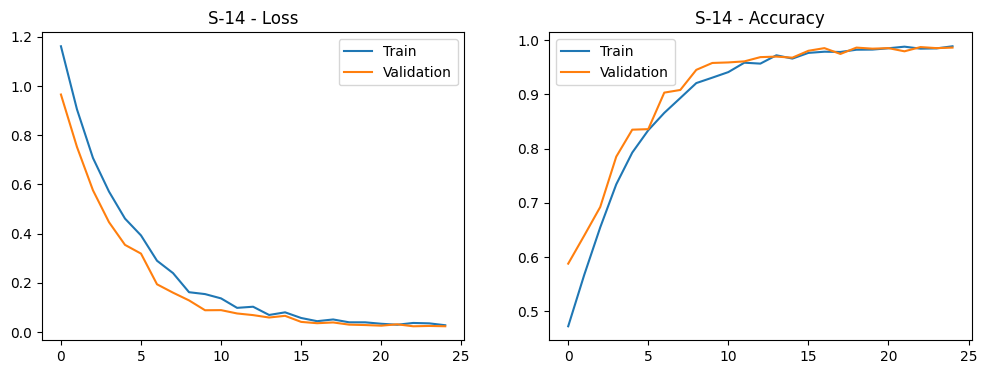


=== CLASSIFICATION REPORT: S-14 ===
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       172
           1       1.00      1.00      1.00        15
           2       1.00      0.98      0.99       634
           3       0.98      1.00      0.99       459

    accuracy                           0.99      1280
   macro avg       0.99      0.99      0.99      1280
weighted avg       0.99      0.99      0.99      1280



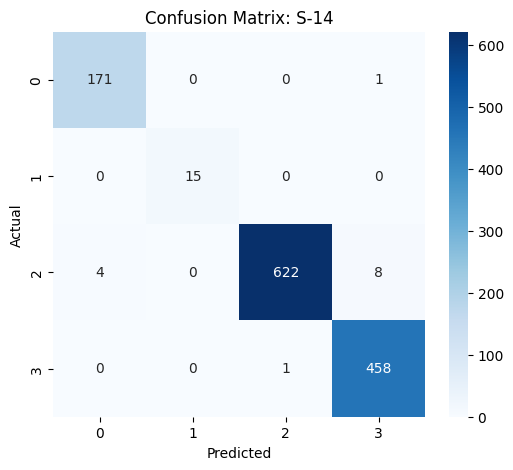

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import numpy as np
import copy
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CONFIG & SETUP
# ==========================================
CONFIG = {
    "lr": 1e-4,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"] # 5120 data
test_data = hf_dataset["test"]      # 1280 data

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

train_labels = np.array(train_data["label"])

# ==========================================
# 3. CLASS WEIGHTS UNTUK LOSS FUNCTION
# ==========================================
print("\nMenghitung Class Weights...")
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts

# Normalisasi bobot agar tidak terlalu besar/kecil (best practice)
class_weights = class_weights / class_weights.sum() * len(class_counts)

# Konversi ke Tensor dan pindahkan ke device
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"Class Weights Tensor: {class_weights_tensor}")

# ==========================================
# 4. DATASET WRAPPER
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

# ==========================================
# 5. DEFINE TRANSFORMS (AUG & NO AUG)
# ==========================================
base_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

aug_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==========================================
# 6. EXPERIMENT FUNCTION (FULL FINE-TUNING)
# ==========================================
def run_experiment(experiment_name, train_transform, opt_type, sched_type):
    print(f"\n{'='*60}")
    print(f"STARTING: {experiment_name} | Opt: {opt_type} | Sched: {sched_type}")
    print(f"{'='*60}")

    # --- Setup DataLoaders (Normal Shuffle, NO WeightedRandomSampler) ---
    train_ds = AlzheimerDataset(train_data, train_transform)
    val_ds   = AlzheimerDataset(val_data, base_transform)
    test_ds  = AlzheimerDataset(test_data, base_transform)

    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])
    val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
    test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

    # --- Setup Model ---
    model = efficientnet_b2(weights=EfficientNet_B2_Weights.DEFAULT)

    # PERUBAHAN DI SINI: Pastikan SEMUA layer terbuka (Full Fine-Tuning)
    for param in model.parameters():
        param.requires_grad = True

    num_classes = len(np.unique(train_labels))
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(1408, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )
    model = model.to(device)

    # --- Loss & Optimizers ---
    # CLASS WEIGHT PADA LOSS FUNCTION
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

    # trainable_params sekarang mencakup KESELURUHAN model
    trainable_params = filter(lambda p: p.requires_grad, model.parameters())

    if opt_type == 'Adam':
        optimizer = optim.Adam(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'AdamW':
        optimizer = optim.AdamW(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'SGD':
        optimizer = optim.SGD(trainable_params, lr=CONFIG["lr"], momentum=0.9)
    else:
        raise ValueError("Optimizer tidak dikenali!")

    # --- Dynamic Scheduler ---
    if sched_type == 'CosineAnnealingLR':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])
    elif sched_type == 'ReduceLROnPlateau':
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
    else:
        raise ValueError("Scheduler tidak dikenali!")

    # --- Training Loop ---
    train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []
    best_model = copy.deepcopy(model.state_dict())
    best_loss = float("inf")
    counter = 0

    for epoch in range(CONFIG["epochs"]):
        # ===== Train =====
        model.train()
        train_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss /= total
        train_acc = correct / total

        # Step Scheduler (CosineAnnealingLR)
        if sched_type == 'CosineAnnealingLR':
            scheduler.step()

        # ===== Validation =====
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        # Step Scheduler (ReduceLROnPlateau)
        if sched_type == 'ReduceLROnPlateau':
            scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:02d}/{CONFIG['epochs']} | LR: {current_lr:.2e} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        # ===== Early Stopping =====
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= CONFIG["patience"]:
                print("-> Early stopping triggered!")
                break

    # --- Load Best Model & Test ---
    print(f"\nLoading best model for {experiment_name} testing...")
    model.load_state_dict(best_model)

    model.eval()
    all_probs, all_labels, all_preds = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())

    # --- Plotting & Metrics ---
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Validation")
    plt.title(f"{experiment_name} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label="Train")
    plt.plot(val_accuracies, label="Validation")
    plt.title(f"{experiment_name} - Accuracy")
    plt.legend()
    plt.show()

    print(f"\n=== CLASSIFICATION REPORT: {experiment_name} ===")
    print(classification_report(all_labels, all_preds))

    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix: {experiment_name}")
    plt.show()

# ==========================================
# 7. RUN PIPELINES (SCENARIOS S-13 to S-18)
# ==========================================
scenarios_full_tuning = [
    {"name": "S-13", "opt": "Adam",  "sched": "ReduceLROnPlateau"},
    {"name": "S-14", "opt": "Adam",  "sched": "CosineAnnealingLR"},
    # {"name": "S-15", "opt": "AdamW", "sched": "ReduceLROnPlateau"},
    # {"name": "S-16", "opt": "AdamW", "sched": "CosineAnnealingLR"},
    # {"name": "S-17", "opt": "SGD",   "sched": "ReduceLROnPlateau"},
    # {"name": "S-18", "opt": "SGD",   "sched": "CosineAnnealingLR"}
]

# Eksekusi loop untuk skenario Full Fine-Tuning
for scenario in scenarios_full_tuning:
    run_experiment(
        experiment_name=scenario["name"],
        train_transform=aug_transform, # Menggunakan augmentasi
        opt_type=scenario["opt"],
        sched_type=scenario["sched"]
    )

Device: cuda
Loading dataset...
Train: 4096 | Val: 1024 | Test: 1280

Menghitung Class Weights...
Class Weights Tensor: tensor([0.2419, 3.5916, 0.0682, 0.0983], device='cuda:0')

STARTING: S-15 | Opt: AdamW | Sched: ReduceLROnPlateau
Epoch 01/25 | LR: 1.00e-04 | Train Loss: 1.1888 Acc: 0.4966 | Val Loss: 0.9661 Acc: 0.5684
Epoch 02/25 | LR: 1.00e-04 | Train Loss: 0.8995 Acc: 0.5723 | Val Loss: 0.7338 Acc: 0.6162
Epoch 03/25 | LR: 1.00e-04 | Train Loss: 0.7489 Acc: 0.6372 | Val Loss: 0.6375 Acc: 0.7021
Epoch 04/25 | LR: 1.00e-04 | Train Loss: 0.6014 Acc: 0.6985 | Val Loss: 0.5062 Acc: 0.7715
Epoch 05/25 | LR: 1.00e-04 | Train Loss: 0.5004 Acc: 0.7578 | Val Loss: 0.4483 Acc: 0.7812
Epoch 06/25 | LR: 1.00e-04 | Train Loss: 0.3835 Acc: 0.8333 | Val Loss: 0.3674 Acc: 0.8027
Epoch 07/25 | LR: 1.00e-04 | Train Loss: 0.2951 Acc: 0.8652 | Val Loss: 0.2194 Acc: 0.8955
Epoch 08/25 | LR: 1.00e-04 | Train Loss: 0.2478 Acc: 0.8896 | Val Loss: 0.1543 Acc: 0.9268
Epoch 09/25 | LR: 1.00e-04 | Train Los

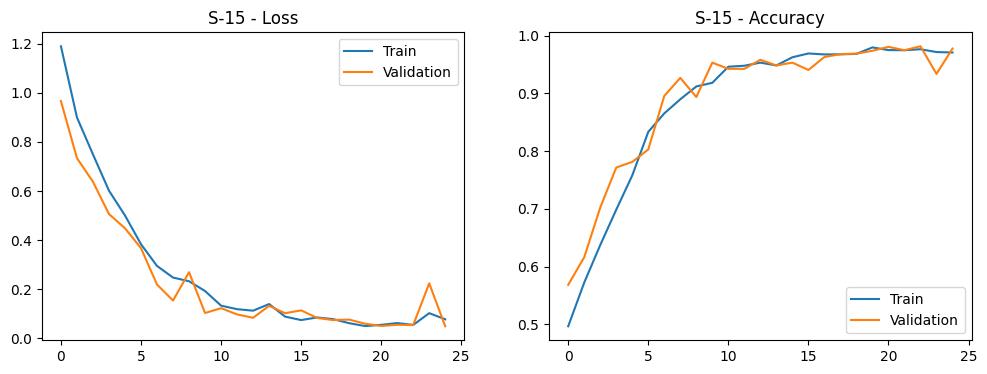


=== CLASSIFICATION REPORT: S-15 ===
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       172
           1       1.00      1.00      1.00        15
           2       0.99      0.96      0.98       634
           3       0.95      0.99      0.97       459

    accuracy                           0.97      1280
   macro avg       0.98      0.98      0.98      1280
weighted avg       0.98      0.97      0.98      1280



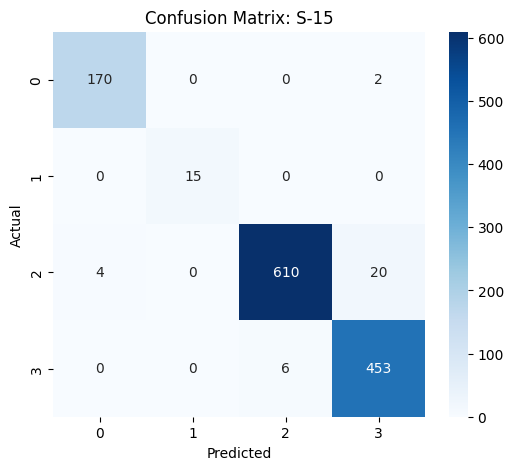


STARTING: S-16 | Opt: AdamW | Sched: CosineAnnealingLR
Epoch 01/25 | LR: 9.96e-05 | Train Loss: 1.1760 Acc: 0.4858 | Val Loss: 0.9871 Acc: 0.5850
Epoch 02/25 | LR: 9.84e-05 | Train Loss: 0.8933 Acc: 0.5881 | Val Loss: 0.7230 Acc: 0.6670
Epoch 03/25 | LR: 9.65e-05 | Train Loss: 0.7178 Acc: 0.6597 | Val Loss: 0.5823 Acc: 0.7061
Epoch 04/25 | LR: 9.38e-05 | Train Loss: 0.6137 Acc: 0.7126 | Val Loss: 0.4708 Acc: 0.7676
Epoch 05/25 | LR: 9.05e-05 | Train Loss: 0.4853 Acc: 0.7773 | Val Loss: 0.3667 Acc: 0.8311
Epoch 06/25 | LR: 8.64e-05 | Train Loss: 0.3754 Acc: 0.8235 | Val Loss: 0.2886 Acc: 0.8535
Epoch 07/25 | LR: 8.19e-05 | Train Loss: 0.3001 Acc: 0.8657 | Val Loss: 0.2094 Acc: 0.9023
Epoch 08/25 | LR: 7.68e-05 | Train Loss: 0.2556 Acc: 0.8958 | Val Loss: 0.2207 Acc: 0.9170
Epoch 09/25 | LR: 7.13e-05 | Train Loss: 0.2680 Acc: 0.9004 | Val Loss: 0.2644 Acc: 0.8730
Epoch 10/25 | LR: 6.55e-05 | Train Loss: 0.1753 Acc: 0.9238 | Val Loss: 0.1212 Acc: 0.9453
Epoch 11/25 | LR: 5.94e-05 | Train

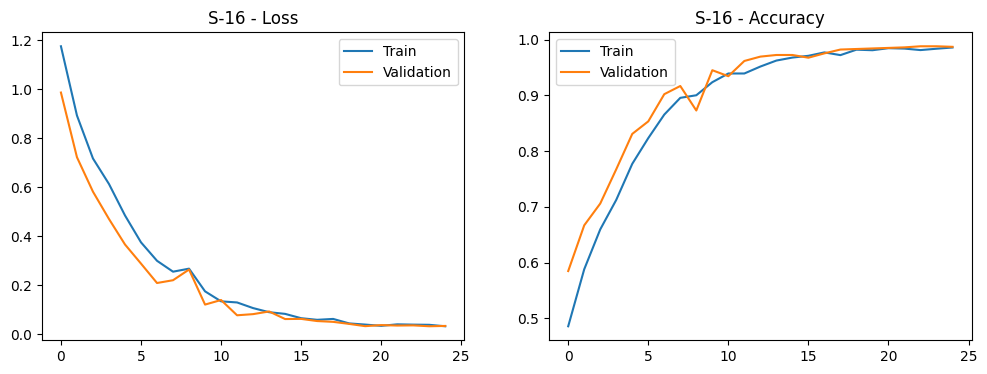


=== CLASSIFICATION REPORT: S-16 ===
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       172
           1       1.00      1.00      1.00        15
           2       0.99      0.99      0.99       634
           3       0.99      0.99      0.99       459

    accuracy                           0.99      1280
   macro avg       0.99      0.99      0.99      1280
weighted avg       0.99      0.99      0.99      1280



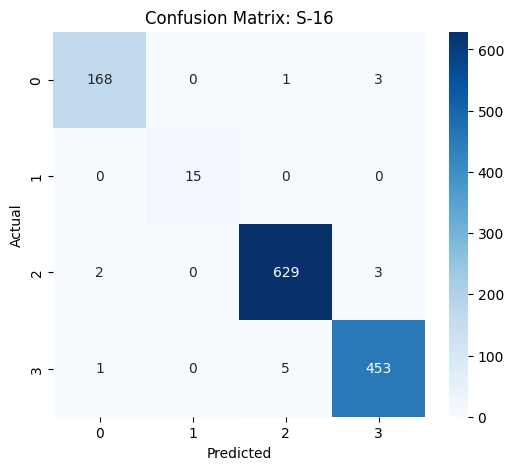

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import numpy as np
import copy
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CONFIG & SETUP
# ==========================================
CONFIG = {
    "lr": 1e-4,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"] # 5120 data
test_data = hf_dataset["test"]      # 1280 data

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

train_labels = np.array(train_data["label"])

# ==========================================
# 3. CLASS WEIGHTS UNTUK LOSS FUNCTION
# ==========================================
print("\nMenghitung Class Weights...")
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts

# Normalisasi bobot agar tidak terlalu besar/kecil (best practice)
class_weights = class_weights / class_weights.sum() * len(class_counts)

# Konversi ke Tensor dan pindahkan ke device
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"Class Weights Tensor: {class_weights_tensor}")

# ==========================================
# 4. DATASET WRAPPER
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

# ==========================================
# 5. DEFINE TRANSFORMS (AUG & NO AUG)
# ==========================================
base_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

aug_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==========================================
# 6. EXPERIMENT FUNCTION (FULL FINE-TUNING)
# ==========================================
def run_experiment(experiment_name, train_transform, opt_type, sched_type):
    print(f"\n{'='*60}")
    print(f"STARTING: {experiment_name} | Opt: {opt_type} | Sched: {sched_type}")
    print(f"{'='*60}")

    # --- Setup DataLoaders (Normal Shuffle, NO WeightedRandomSampler) ---
    train_ds = AlzheimerDataset(train_data, train_transform)
    val_ds   = AlzheimerDataset(val_data, base_transform)
    test_ds  = AlzheimerDataset(test_data, base_transform)

    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])
    val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
    test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

    # --- Setup Model ---
    model = efficientnet_b2(weights=EfficientNet_B2_Weights.DEFAULT)

    # PERUBAHAN DI SINI: Pastikan SEMUA layer terbuka (Full Fine-Tuning)
    for param in model.parameters():
        param.requires_grad = True

    num_classes = len(np.unique(train_labels))
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(1408, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )
    model = model.to(device)

    # --- Loss & Optimizers ---
    # CLASS WEIGHT PADA LOSS FUNCTION
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

    # trainable_params sekarang mencakup KESELURUHAN model
    trainable_params = filter(lambda p: p.requires_grad, model.parameters())

    if opt_type == 'Adam':
        optimizer = optim.Adam(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'AdamW':
        optimizer = optim.AdamW(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'SGD':
        optimizer = optim.SGD(trainable_params, lr=CONFIG["lr"], momentum=0.9)
    else:
        raise ValueError("Optimizer tidak dikenali!")

    # --- Dynamic Scheduler ---
    if sched_type == 'CosineAnnealingLR':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])
    elif sched_type == 'ReduceLROnPlateau':
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
    else:
        raise ValueError("Scheduler tidak dikenali!")

    # --- Training Loop ---
    train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []
    best_model = copy.deepcopy(model.state_dict())
    best_loss = float("inf")
    counter = 0

    for epoch in range(CONFIG["epochs"]):
        # ===== Train =====
        model.train()
        train_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss /= total
        train_acc = correct / total

        # Step Scheduler (CosineAnnealingLR)
        if sched_type == 'CosineAnnealingLR':
            scheduler.step()

        # ===== Validation =====
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        # Step Scheduler (ReduceLROnPlateau)
        if sched_type == 'ReduceLROnPlateau':
            scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:02d}/{CONFIG['epochs']} | LR: {current_lr:.2e} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        # ===== Early Stopping =====
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= CONFIG["patience"]:
                print("-> Early stopping triggered!")
                break

    # --- Load Best Model & Test ---
    print(f"\nLoading best model for {experiment_name} testing...")
    model.load_state_dict(best_model)

    model.eval()
    all_probs, all_labels, all_preds = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())

    # --- Plotting & Metrics ---
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Validation")
    plt.title(f"{experiment_name} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label="Train")
    plt.plot(val_accuracies, label="Validation")
    plt.title(f"{experiment_name} - Accuracy")
    plt.legend()
    plt.show()

    print(f"\n=== CLASSIFICATION REPORT: {experiment_name} ===")
    print(classification_report(all_labels, all_preds))

    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix: {experiment_name}")
    plt.show()

# ==========================================
# 7. RUN PIPELINES (SCENARIOS S-13 to S-18)
# ==========================================
scenarios_full_tuning = [
    # {"name": "S-13", "opt": "Adam",  "sched": "ReduceLROnPlateau"},
    # {"name": "S-14", "opt": "Adam",  "sched": "CosineAnnealingLR"},
    {"name": "S-15", "opt": "AdamW", "sched": "ReduceLROnPlateau"},
    {"name": "S-16", "opt": "AdamW", "sched": "CosineAnnealingLR"},
    # {"name": "S-17", "opt": "SGD",   "sched": "ReduceLROnPlateau"},
    # {"name": "S-18", "opt": "SGD",   "sched": "CosineAnnealingLR"}
]

# Eksekusi loop untuk skenario Full Fine-Tuning
for scenario in scenarios_full_tuning:
    run_experiment(
        experiment_name=scenario["name"],
        train_transform=aug_transform, # Menggunakan augmentasi
        opt_type=scenario["opt"],
        sched_type=scenario["sched"]
    )

Device: cuda
Loading dataset...


README.md:   0%|          | 0.00/2.13k [00:00<?, ?B/s]

data/train-00000-of-00001-c08a401c53fe53(…):   0%|          | 0.00/22.6M [00:00<?, ?B/s]

data/test-00000-of-00001-44110b9df98c558(…):   0%|          | 0.00/5.65M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5120 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1280 [00:00<?, ? examples/s]

Train: 4096 | Val: 1024 | Test: 1280

Menghitung Class Weights...
Class Weights Tensor: tensor([0.2419, 3.5916, 0.0682, 0.0983], device='cuda:0')

STARTING: S-17 | Opt: SGD | Sched: ReduceLROnPlateau
Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 127MB/s]


Epoch 01/25 | LR: 1.00e-04 | Train Loss: 1.3683 Acc: 0.3220 | Val Loss: 1.3509 Acc: 0.5137
Epoch 02/25 | LR: 1.00e-04 | Train Loss: 1.3203 Acc: 0.3828 | Val Loss: 1.3348 Acc: 0.4941
Epoch 03/25 | LR: 1.00e-04 | Train Loss: 1.3249 Acc: 0.4148 | Val Loss: 1.3177 Acc: 0.5098
Epoch 04/25 | LR: 1.00e-04 | Train Loss: 1.3099 Acc: 0.4319 | Val Loss: 1.3076 Acc: 0.5273
Epoch 05/25 | LR: 1.00e-04 | Train Loss: 1.2933 Acc: 0.4480 | Val Loss: 1.2978 Acc: 0.5371
Epoch 06/25 | LR: 1.00e-04 | Train Loss: 1.2876 Acc: 0.4600 | Val Loss: 1.2826 Acc: 0.5244
Epoch 07/25 | LR: 1.00e-04 | Train Loss: 1.2757 Acc: 0.4849 | Val Loss: 1.2707 Acc: 0.5391
Epoch 08/25 | LR: 1.00e-04 | Train Loss: 1.2670 Acc: 0.4912 | Val Loss: 1.2546 Acc: 0.5430
Epoch 09/25 | LR: 1.00e-04 | Train Loss: 1.2397 Acc: 0.4990 | Val Loss: 1.2298 Acc: 0.5293
Epoch 10/25 | LR: 1.00e-04 | Train Loss: 1.2348 Acc: 0.5125 | Val Loss: 1.2111 Acc: 0.5176
Epoch 11/25 | LR: 1.00e-04 | Train Loss: 1.2151 Acc: 0.5132 | Val Loss: 1.2069 Acc: 0.5273

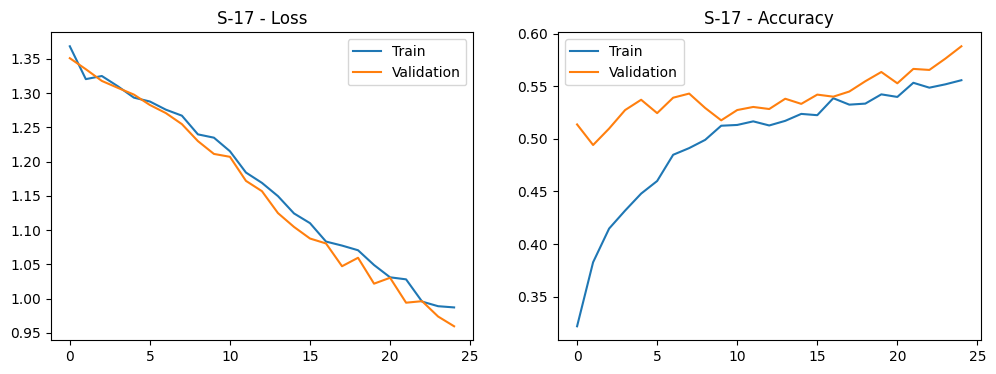


=== CLASSIFICATION REPORT: S-17 ===
              precision    recall  f1-score   support

           0       0.31      0.76      0.44       172
           1       0.60      0.60      0.60        15
           2       0.72      0.69      0.71       634
           3       0.54      0.29      0.37       459

    accuracy                           0.55      1280
   macro avg       0.54      0.58      0.53      1280
weighted avg       0.60      0.55      0.55      1280



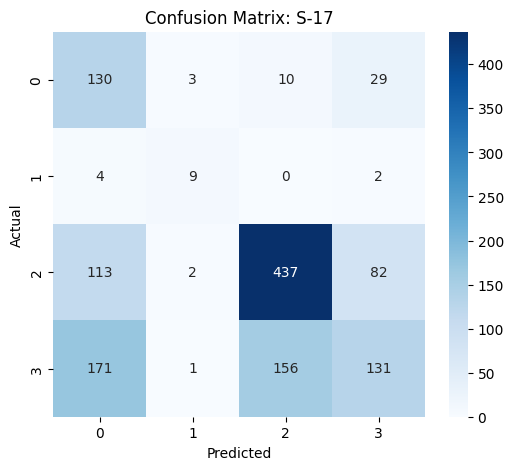


STARTING: S-18 | Opt: SGD | Sched: CosineAnnealingLR
Epoch 01/25 | LR: 9.96e-05 | Train Loss: 1.3624 Acc: 0.3674 | Val Loss: 1.3550 Acc: 0.4346
Epoch 02/25 | LR: 9.84e-05 | Train Loss: 1.3325 Acc: 0.3989 | Val Loss: 1.3381 Acc: 0.4756
Epoch 03/25 | LR: 9.65e-05 | Train Loss: 1.3093 Acc: 0.4160 | Val Loss: 1.3224 Acc: 0.5137
Epoch 04/25 | LR: 9.38e-05 | Train Loss: 1.3026 Acc: 0.4382 | Val Loss: 1.3175 Acc: 0.5488
Epoch 05/25 | LR: 9.05e-05 | Train Loss: 1.2968 Acc: 0.4651 | Val Loss: 1.3023 Acc: 0.5566
Epoch 06/25 | LR: 8.64e-05 | Train Loss: 1.2920 Acc: 0.4692 | Val Loss: 1.2910 Acc: 0.5410
Epoch 07/25 | LR: 8.19e-05 | Train Loss: 1.2756 Acc: 0.4858 | Val Loss: 1.2773 Acc: 0.5566
Epoch 08/25 | LR: 7.68e-05 | Train Loss: 1.2662 Acc: 0.4802 | Val Loss: 1.2712 Acc: 0.5508
Epoch 09/25 | LR: 7.13e-05 | Train Loss: 1.2579 Acc: 0.4897 | Val Loss: 1.2587 Acc: 0.5352
Epoch 10/25 | LR: 6.55e-05 | Train Loss: 1.2432 Acc: 0.5112 | Val Loss: 1.2415 Acc: 0.5322
Epoch 11/25 | LR: 5.94e-05 | Train L

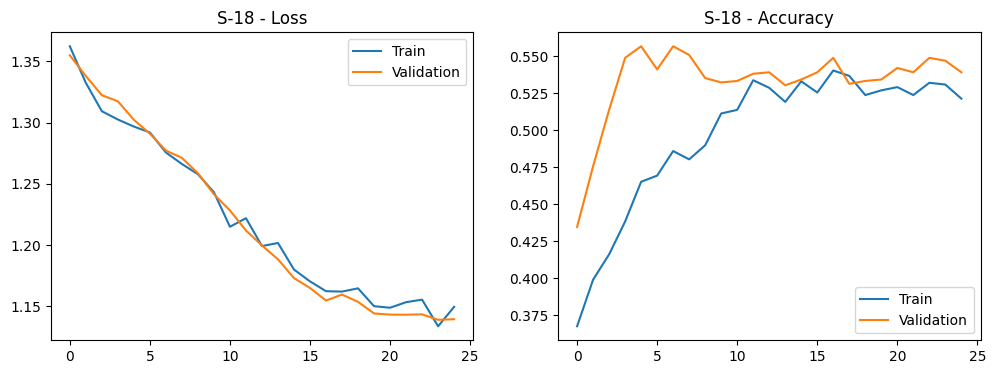


=== CLASSIFICATION REPORT: S-18 ===
              precision    recall  f1-score   support

           0       0.30      0.61      0.40       172
           1       0.00      0.00      0.00        15
           2       0.64      0.75      0.69       634
           3       0.51      0.20      0.29       459

    accuracy                           0.53      1280
   macro avg       0.36      0.39      0.35      1280
weighted avg       0.54      0.53      0.50      1280



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


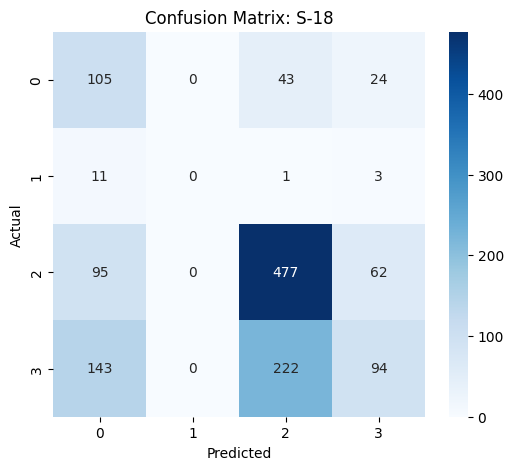

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import numpy as np
import copy
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CONFIG & SETUP
# ==========================================
CONFIG = {
    "lr": 1e-4,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"] # 5120 data
test_data = hf_dataset["test"]      # 1280 data

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

train_labels = np.array(train_data["label"])

# ==========================================
# 3. CLASS WEIGHTS UNTUK LOSS FUNCTION
# ==========================================
print("\nMenghitung Class Weights...")
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts

# Normalisasi bobot agar tidak terlalu besar/kecil (best practice)
class_weights = class_weights / class_weights.sum() * len(class_counts)

# Konversi ke Tensor dan pindahkan ke device
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"Class Weights Tensor: {class_weights_tensor}")

# ==========================================
# 4. DATASET WRAPPER
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

# ==========================================
# 5. DEFINE TRANSFORMS (AUG & NO AUG)
# ==========================================
base_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

aug_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==========================================
# 6. EXPERIMENT FUNCTION (FULL FINE-TUNING)
# ==========================================
def run_experiment(experiment_name, train_transform, opt_type, sched_type):
    print(f"\n{'='*60}")
    print(f"STARTING: {experiment_name} | Opt: {opt_type} | Sched: {sched_type}")
    print(f"{'='*60}")

    # --- Setup DataLoaders (Normal Shuffle, NO WeightedRandomSampler) ---
    train_ds = AlzheimerDataset(train_data, train_transform)
    val_ds   = AlzheimerDataset(val_data, base_transform)
    test_ds  = AlzheimerDataset(test_data, base_transform)

    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])
    val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
    test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

    # --- Setup Model ---
    model = efficientnet_b2(weights=EfficientNet_B2_Weights.DEFAULT)

    # PERUBAHAN DI SINI: Pastikan SEMUA layer terbuka (Full Fine-Tuning)
    for param in model.parameters():
        param.requires_grad = True

    num_classes = len(np.unique(train_labels))
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(1408, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )
    model = model.to(device)

    # --- Loss & Optimizers ---
    # CLASS WEIGHT PADA LOSS FUNCTION
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

    # trainable_params sekarang mencakup KESELURUHAN model
    trainable_params = filter(lambda p: p.requires_grad, model.parameters())

    if opt_type == 'Adam':
        optimizer = optim.Adam(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'AdamW':
        optimizer = optim.AdamW(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'SGD':
        optimizer = optim.SGD(trainable_params, lr=CONFIG["lr"], momentum=0.9)
    else:
        raise ValueError("Optimizer tidak dikenali!")

    # --- Dynamic Scheduler ---
    if sched_type == 'CosineAnnealingLR':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])
    elif sched_type == 'ReduceLROnPlateau':
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
    else:
        raise ValueError("Scheduler tidak dikenali!")

    # --- Training Loop ---
    train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []
    best_model = copy.deepcopy(model.state_dict())
    best_loss = float("inf")
    counter = 0

    for epoch in range(CONFIG["epochs"]):
        # ===== Train =====
        model.train()
        train_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss /= total
        train_acc = correct / total

        # Step Scheduler (CosineAnnealingLR)
        if sched_type == 'CosineAnnealingLR':
            scheduler.step()

        # ===== Validation =====
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        # Step Scheduler (ReduceLROnPlateau)
        if sched_type == 'ReduceLROnPlateau':
            scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:02d}/{CONFIG['epochs']} | LR: {current_lr:.2e} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        # ===== Early Stopping =====
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= CONFIG["patience"]:
                print("-> Early stopping triggered!")
                break

    # --- Load Best Model & Test ---
    print(f"\nLoading best model for {experiment_name} testing...")
    model.load_state_dict(best_model)

    model.eval()
    all_probs, all_labels, all_preds = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())

    # --- Plotting & Metrics ---
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Validation")
    plt.title(f"{experiment_name} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label="Train")
    plt.plot(val_accuracies, label="Validation")
    plt.title(f"{experiment_name} - Accuracy")
    plt.legend()
    plt.show()

    print(f"\n=== CLASSIFICATION REPORT: {experiment_name} ===")
    print(classification_report(all_labels, all_preds))

    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix: {experiment_name}")
    plt.show()

# ==========================================
# 7. RUN PIPELINES (SCENARIOS S-13 to S-18)
# ==========================================
scenarios_full_tuning = [
    # {"name": "S-13", "opt": "Adam",  "sched": "ReduceLROnPlateau"},
    # {"name": "S-14", "opt": "Adam",  "sched": "CosineAnnealingLR"},
    # {"name": "S-15", "opt": "AdamW", "sched": "ReduceLROnPlateau"},
    # {"name": "S-16", "opt": "AdamW", "sched": "CosineAnnealingLR"},
    {"name": "S-17", "opt": "SGD",   "sched": "ReduceLROnPlateau"},
    {"name": "S-18", "opt": "SGD",   "sched": "CosineAnnealingLR"}
]

# Eksekusi loop untuk skenario Full Fine-Tuning
for scenario in scenarios_full_tuning:
    run_experiment(
        experiment_name=scenario["name"],
        train_transform=aug_transform, # Menggunakan augmentasi
        opt_type=scenario["opt"],
        sched_type=scenario["sched"]
    )

# Class Weight (D

Mounting Google Drive...
Mounted at /content/drive
Semua model akan disimpan di: /content/drive/MyDrive/Alzheimer_EfficientNet_Models
Device: cuda

Loading dataset...


README.md:   0%|          | 0.00/2.13k [00:00<?, ?B/s]

data/train-00000-of-00001-c08a401c53fe53(…):   0%|          | 0.00/22.6M [00:00<?, ?B/s]

data/test-00000-of-00001-44110b9df98c558(…):   0%|          | 0.00/5.65M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5120 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1280 [00:00<?, ? examples/s]

Train: 4096 | Val: 1024 | Test: 1280

STARTING: S-01 | Opt: Adam | Sched: ReduceLROnPlateau
Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 223MB/s]


Epoch 01/25 | LR: 1.00e-04 | Train Loss: 1.3131 Acc: 0.4536 | Val Loss: 1.2618 Acc: 0.5547
Epoch 02/25 | LR: 1.00e-04 | Train Loss: 1.2347 Acc: 0.5088 | Val Loss: 1.1964 Acc: 0.5479
Epoch 03/25 | LR: 1.00e-04 | Train Loss: 1.1963 Acc: 0.5144 | Val Loss: 1.1689 Acc: 0.5234
Epoch 04/25 | LR: 1.00e-04 | Train Loss: 1.1898 Acc: 0.5090 | Val Loss: 1.1535 Acc: 0.5586
Epoch 05/25 | LR: 1.00e-04 | Train Loss: 1.1579 Acc: 0.5325 | Val Loss: 1.1166 Acc: 0.5410
Epoch 06/25 | LR: 1.00e-04 | Train Loss: 1.1551 Acc: 0.5215 | Val Loss: 1.0960 Acc: 0.5742
Epoch 07/25 | LR: 1.00e-04 | Train Loss: 1.1121 Acc: 0.5190 | Val Loss: 1.0890 Acc: 0.5732
Epoch 08/25 | LR: 1.00e-04 | Train Loss: 1.1125 Acc: 0.5312 | Val Loss: 1.0931 Acc: 0.5791
Epoch 09/25 | LR: 1.00e-04 | Train Loss: 1.1224 Acc: 0.5325 | Val Loss: 1.0633 Acc: 0.5586
Epoch 10/25 | LR: 1.00e-04 | Train Loss: 1.1100 Acc: 0.5249 | Val Loss: 1.0534 Acc: 0.5439
Epoch 11/25 | LR: 1.00e-04 | Train Loss: 1.1153 Acc: 0.5181 | Val Loss: 1.0470 Acc: 0.5596

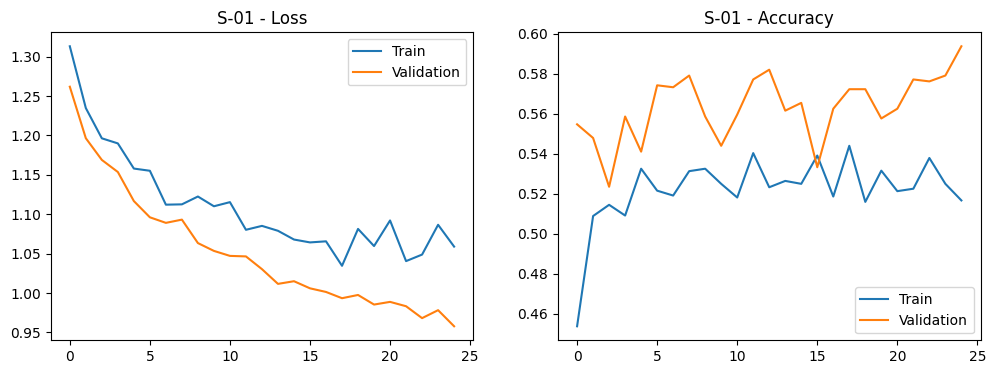


=== CLASSIFICATION REPORT: S-01 ===
              precision    recall  f1-score   support

           0       0.36      0.51      0.42       172
           1       0.30      0.73      0.42        15
           2       0.69      0.66      0.68       634
           3       0.53      0.46      0.49       459

    accuracy                           0.57      1280
   macro avg       0.47      0.59      0.50      1280
weighted avg       0.58      0.57      0.57      1280



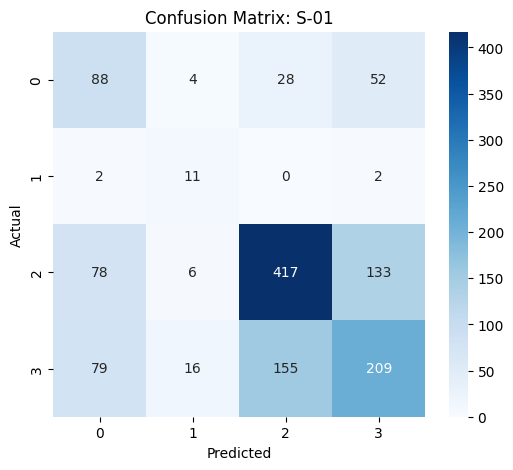


STARTING: S-02 | Opt: Adam | Sched: CosineAnnealingLR
Epoch 01/25 | LR: 9.96e-05 | Train Loss: 1.3081 Acc: 0.4695 | Val Loss: 1.2682 Acc: 0.5303
Epoch 02/25 | LR: 9.84e-05 | Train Loss: 1.2494 Acc: 0.5090 | Val Loss: 1.2068 Acc: 0.5352
Epoch 03/25 | LR: 9.65e-05 | Train Loss: 1.1921 Acc: 0.5120 | Val Loss: 1.1752 Acc: 0.5654
Epoch 04/25 | LR: 9.38e-05 | Train Loss: 1.1586 Acc: 0.5227 | Val Loss: 1.1481 Acc: 0.5400
Epoch 05/25 | LR: 9.05e-05 | Train Loss: 1.1619 Acc: 0.5188 | Val Loss: 1.1301 Acc: 0.5693
Epoch 06/25 | LR: 8.64e-05 | Train Loss: 1.1525 Acc: 0.5198 | Val Loss: 1.1047 Acc: 0.5420
Epoch 07/25 | LR: 8.19e-05 | Train Loss: 1.1365 Acc: 0.5212 | Val Loss: 1.0918 Acc: 0.5645
Epoch 08/25 | LR: 7.68e-05 | Train Loss: 1.1155 Acc: 0.5076 | Val Loss: 1.0792 Acc: 0.5801
Epoch 09/25 | LR: 7.13e-05 | Train Loss: 1.1125 Acc: 0.5210 | Val Loss: 1.0737 Acc: 0.5830
Epoch 10/25 | LR: 6.55e-05 | Train Loss: 1.1171 Acc: 0.5234 | Val Loss: 1.0483 Acc: 0.5596
Epoch 11/25 | LR: 5.94e-05 | Train 

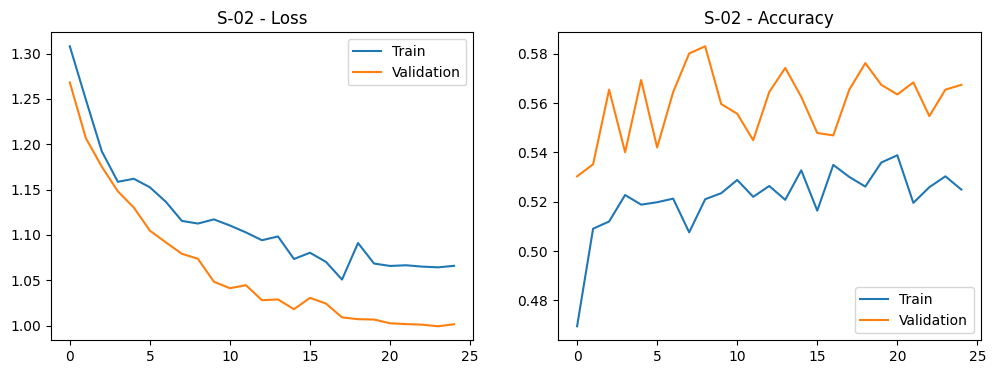


=== CLASSIFICATION REPORT: S-02 ===
              precision    recall  f1-score   support

           0       0.31      0.48      0.38       172
           1       0.38      0.73      0.50        15
           2       0.70      0.67      0.69       634
           3       0.53      0.44      0.48       459

    accuracy                           0.56      1280
   macro avg       0.48      0.58      0.51      1280
weighted avg       0.59      0.56      0.57      1280



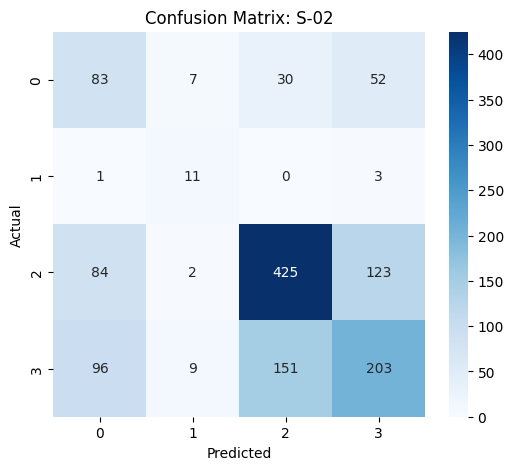


STARTING: S-03 | Opt: AdamW | Sched: ReduceLROnPlateau
Epoch 01/25 | LR: 1.00e-04 | Train Loss: 1.2992 Acc: 0.4517 | Val Loss: 1.2637 Acc: 0.5615
Epoch 02/25 | LR: 1.00e-04 | Train Loss: 1.2514 Acc: 0.4963 | Val Loss: 1.2089 Acc: 0.5586
Epoch 03/25 | LR: 1.00e-04 | Train Loss: 1.2034 Acc: 0.5154 | Val Loss: 1.1706 Acc: 0.5635
Epoch 04/25 | LR: 1.00e-04 | Train Loss: 1.1797 Acc: 0.5203 | Val Loss: 1.1504 Acc: 0.5801
Epoch 05/25 | LR: 1.00e-04 | Train Loss: 1.1711 Acc: 0.5188 | Val Loss: 1.1145 Acc: 0.5469
Epoch 06/25 | LR: 1.00e-04 | Train Loss: 1.1620 Acc: 0.5071 | Val Loss: 1.1106 Acc: 0.5742
Epoch 07/25 | LR: 1.00e-04 | Train Loss: 1.1419 Acc: 0.5237 | Val Loss: 1.0922 Acc: 0.5547
Epoch 08/25 | LR: 1.00e-04 | Train Loss: 1.1352 Acc: 0.5107 | Val Loss: 1.0740 Acc: 0.5586
Epoch 09/25 | LR: 1.00e-04 | Train Loss: 1.1060 Acc: 0.5317 | Val Loss: 1.0689 Acc: 0.5625
Epoch 10/25 | LR: 1.00e-04 | Train Loss: 1.1213 Acc: 0.5220 | Val Loss: 1.0578 Acc: 0.5527
Epoch 11/25 | LR: 1.00e-04 | Train

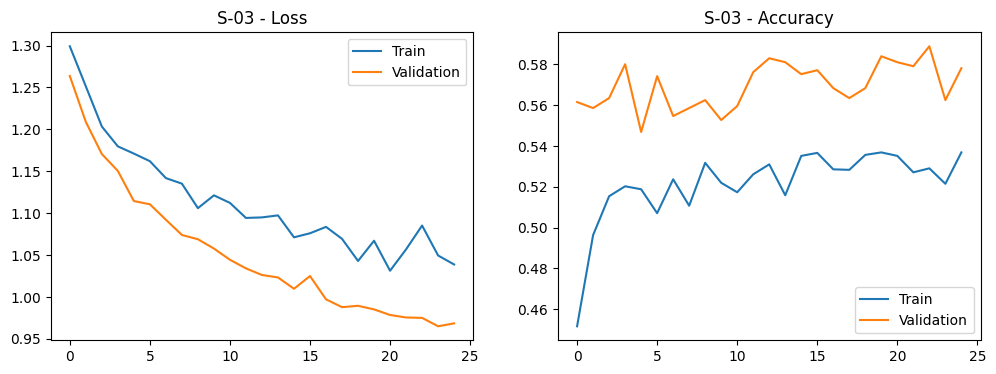


=== CLASSIFICATION REPORT: S-03 ===
              precision    recall  f1-score   support

           0       0.34      0.60      0.43       172
           1       0.23      0.87      0.37        15
           2       0.69      0.65      0.67       634
           3       0.54      0.38      0.45       459

    accuracy                           0.55      1280
   macro avg       0.45      0.62      0.48      1280
weighted avg       0.59      0.55      0.56      1280



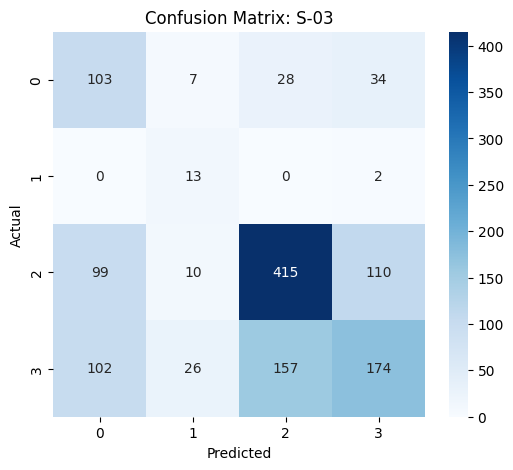


STARTING: S-04 | Opt: AdamW | Sched: CosineAnnealingLR
Epoch 01/25 | LR: 9.96e-05 | Train Loss: 1.3022 Acc: 0.4553 | Val Loss: 1.2597 Acc: 0.5693
Epoch 02/25 | LR: 9.84e-05 | Train Loss: 1.2437 Acc: 0.5007 | Val Loss: 1.2044 Acc: 0.5459
Epoch 03/25 | LR: 9.65e-05 | Train Loss: 1.2018 Acc: 0.5208 | Val Loss: 1.1731 Acc: 0.5430
Epoch 04/25 | LR: 9.38e-05 | Train Loss: 1.2030 Acc: 0.5156 | Val Loss: 1.1395 Acc: 0.5312
Epoch 05/25 | LR: 9.05e-05 | Train Loss: 1.1581 Acc: 0.5232 | Val Loss: 1.1143 Acc: 0.5586
Epoch 06/25 | LR: 8.64e-05 | Train Loss: 1.1532 Acc: 0.5193 | Val Loss: 1.1091 Acc: 0.5859
Epoch 07/25 | LR: 8.19e-05 | Train Loss: 1.1430 Acc: 0.5220 | Val Loss: 1.0888 Acc: 0.5586
Epoch 08/25 | LR: 7.68e-05 | Train Loss: 1.1281 Acc: 0.5125 | Val Loss: 1.0718 Acc: 0.5518
Epoch 09/25 | LR: 7.13e-05 | Train Loss: 1.1128 Acc: 0.5186 | Val Loss: 1.0784 Acc: 0.5645
Epoch 10/25 | LR: 6.55e-05 | Train Loss: 1.1177 Acc: 0.5291 | Val Loss: 1.0592 Acc: 0.5537
Epoch 11/25 | LR: 5.94e-05 | Train

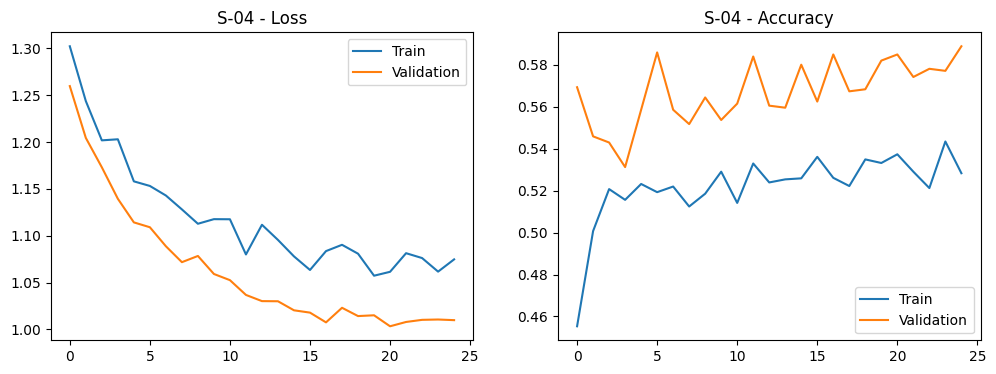


=== CLASSIFICATION REPORT: S-04 ===
              precision    recall  f1-score   support

           0       0.31      0.50      0.39       172
           1       0.30      0.60      0.40        15
           2       0.69      0.65      0.67       634
           3       0.52      0.43      0.47       459

    accuracy                           0.55      1280
   macro avg       0.46      0.55      0.48      1280
weighted avg       0.58      0.55      0.56      1280



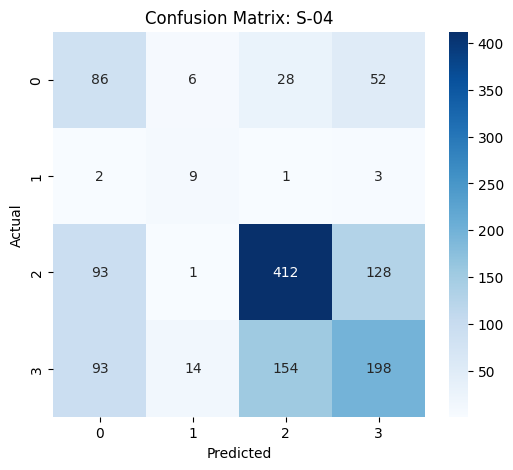


STARTING: S-05 | Opt: SGD | Sched: ReduceLROnPlateau
Epoch 01/25 | LR: 1.00e-04 | Train Loss: 1.3530 Acc: 0.3364 | Val Loss: 1.3452 Acc: 0.3701
Epoch 02/25 | LR: 1.00e-04 | Train Loss: 1.3282 Acc: 0.3816 | Val Loss: 1.3309 Acc: 0.4551
Epoch 03/25 | LR: 1.00e-04 | Train Loss: 1.3098 Acc: 0.4155 | Val Loss: 1.3209 Acc: 0.5146
Epoch 04/25 | LR: 1.00e-04 | Train Loss: 1.3117 Acc: 0.4287 | Val Loss: 1.3176 Acc: 0.5146
Epoch 05/25 | LR: 1.00e-04 | Train Loss: 1.2996 Acc: 0.4392 | Val Loss: 1.3076 Acc: 0.5391
Epoch 06/25 | LR: 1.00e-04 | Train Loss: 1.2924 Acc: 0.4548 | Val Loss: 1.3031 Acc: 0.5420
Epoch 07/25 | LR: 1.00e-04 | Train Loss: 1.2960 Acc: 0.4592 | Val Loss: 1.2949 Acc: 0.5537
Epoch 08/25 | LR: 1.00e-04 | Train Loss: 1.2955 Acc: 0.4646 | Val Loss: 1.2930 Acc: 0.5518
Epoch 09/25 | LR: 1.00e-04 | Train Loss: 1.2987 Acc: 0.4573 | Val Loss: 1.2866 Acc: 0.5596
Epoch 10/25 | LR: 1.00e-04 | Train Loss: 1.2633 Acc: 0.4773 | Val Loss: 1.2787 Acc: 0.5586
Epoch 11/25 | LR: 1.00e-04 | Train L

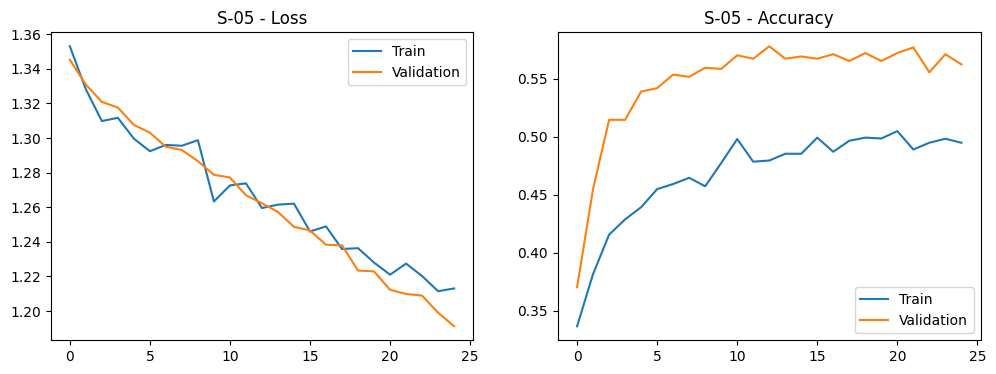


=== CLASSIFICATION REPORT: S-05 ===
              precision    recall  f1-score   support

           0       0.30      0.45      0.36       172
           1       0.00      0.00      0.00        15
           2       0.64      0.71      0.67       634
           3       0.48      0.33      0.39       459

    accuracy                           0.53      1280
   macro avg       0.35      0.37      0.36      1280
weighted avg       0.53      0.53      0.52      1280



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


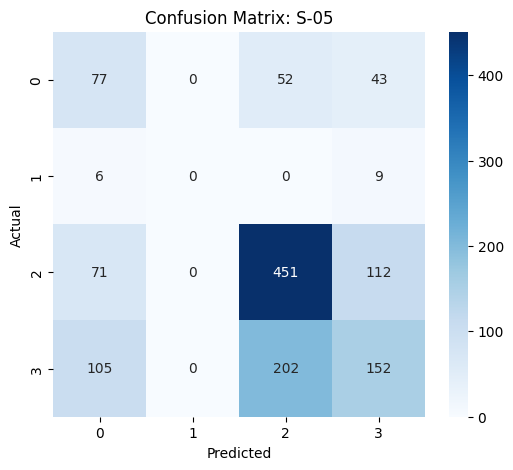


STARTING: S-06 | Opt: SGD | Sched: CosineAnnealingLR
Epoch 01/25 | LR: 9.96e-05 | Train Loss: 1.3721 Acc: 0.3247 | Val Loss: 1.3607 Acc: 0.3955
Epoch 02/25 | LR: 9.84e-05 | Train Loss: 1.3363 Acc: 0.3975 | Val Loss: 1.3435 Acc: 0.4707
Epoch 03/25 | LR: 9.65e-05 | Train Loss: 1.3179 Acc: 0.4275 | Val Loss: 1.3339 Acc: 0.4688
Epoch 04/25 | LR: 9.38e-05 | Train Loss: 1.3180 Acc: 0.4038 | Val Loss: 1.3241 Acc: 0.4785
Epoch 05/25 | LR: 9.05e-05 | Train Loss: 1.3140 Acc: 0.4272 | Val Loss: 1.3194 Acc: 0.4990
Epoch 06/25 | LR: 8.64e-05 | Train Loss: 1.3107 Acc: 0.4158 | Val Loss: 1.3143 Acc: 0.5254
Epoch 07/25 | LR: 8.19e-05 | Train Loss: 1.2876 Acc: 0.4602 | Val Loss: 1.3085 Acc: 0.5264
Epoch 08/25 | LR: 7.68e-05 | Train Loss: 1.2910 Acc: 0.4570 | Val Loss: 1.3026 Acc: 0.5322
Epoch 09/25 | LR: 7.13e-05 | Train Loss: 1.2879 Acc: 0.4717 | Val Loss: 1.2997 Acc: 0.5557
Epoch 10/25 | LR: 6.55e-05 | Train Loss: 1.2918 Acc: 0.4604 | Val Loss: 1.2947 Acc: 0.5391
Epoch 11/25 | LR: 5.94e-05 | Train L

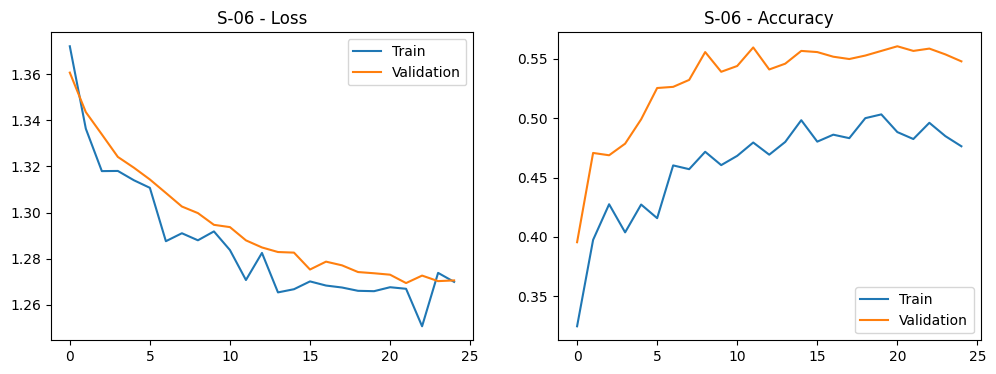


=== CLASSIFICATION REPORT: S-06 ===
              precision    recall  f1-score   support

           0       0.30      0.30      0.30       172
           1       0.00      0.00      0.00        15
           2       0.62      0.73      0.67       634
           3       0.49      0.39      0.43       459

    accuracy                           0.54      1280
   macro avg       0.35      0.36      0.35      1280
weighted avg       0.53      0.54      0.53      1280



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


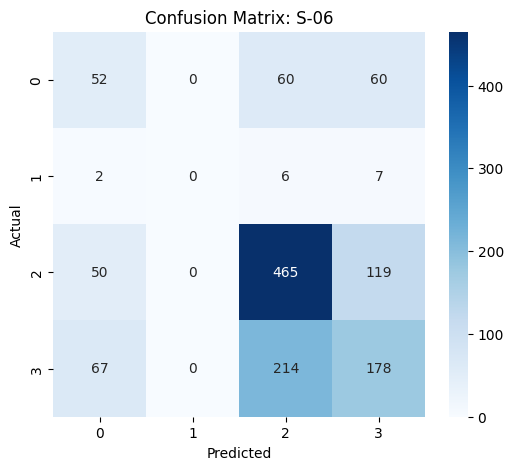

In [ ]:
# ==========================================
# 0. MOUNT GOOGLE DRIVE & SETUP FOLDER
# ==========================================
from google.colab import drive
import os

print("Mounting Google Drive...")
drive.mount('/content/drive')

# Buat folder khusus di Google Drive kamu (jika belum ada)
SAVE_DIR = '/content/drive/MyDrive/Alzheimer_EfficientNet_Models'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Semua model akan disimpan di: {SAVE_DIR}")

# ==========================================
# IMPORT LIBRARIES
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import numpy as np
import copy
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CONFIG & SETUP
# ==========================================
CONFIG = {
    "lr": 1e-4,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("\nLoading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"] # 5120 data
test_data = hf_dataset["test"]      # 1280 data

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")
train_labels = np.array(train_data["label"])

# ==========================================
# 3. CLASS WEIGHTS UNTUK LOSS FUNCTION
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_counts)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

# ==========================================
# 4. DATASET WRAPPER
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

# ==========================================
# 5. DEFINE TRANSFORMS (AUG & NO AUG)
# ==========================================
base_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

aug_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==========================================
# 6. EXPERIMENT FUNCTION (FREEZE SEMUA + SAVE TO DRIVE)
# ==========================================
def run_experiment(experiment_name, train_transform, opt_type, sched_type):
    print(f"\n{'='*60}")
    print(f"STARTING: {experiment_name} | Opt: {opt_type} | Sched: {sched_type}")
    print(f"{'='*60}")

    # --- Setup DataLoaders (Normal Shuffle, NO WeightedRandomSampler) ---
    train_ds = AlzheimerDataset(train_data, train_transform)
    val_ds   = AlzheimerDataset(val_data, base_transform)
    test_ds  = AlzheimerDataset(test_data, base_transform)

    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])
    val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
    test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

    # --- Setup Model ---
    model = efficientnet_b2(weights=EfficientNet_B2_Weights.DEFAULT)

    # FREEZE SEMUA LAYER
    for param in model.features.parameters():
        param.requires_grad = False

    num_classes = len(np.unique(train_labels))
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(1408, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )
    model = model.to(device)

    # --- Loss & Optimizers ---
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    trainable_params = filter(lambda p: p.requires_grad, model.parameters())

    if opt_type == 'Adam':
        optimizer = optim.Adam(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'AdamW':
        optimizer = optim.AdamW(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'SGD':
        optimizer = optim.SGD(trainable_params, lr=CONFIG["lr"], momentum=0.9)
    else:
        raise ValueError("Optimizer tidak dikenali!")

    # --- Dynamic Scheduler ---
    if sched_type == 'CosineAnnealingLR':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])
    elif sched_type == 'ReduceLROnPlateau':
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
    else:
        raise ValueError("Scheduler tidak dikenali!")

    # --- Training Loop ---
    train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []
    best_model = copy.deepcopy(model.state_dict())
    best_loss = float("inf")
    counter = 0

    for epoch in range(CONFIG["epochs"]):
        # ===== Train =====
        model.train()
        train_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss /= total
        train_acc = correct / total

        if sched_type == 'CosineAnnealingLR':
            scheduler.step()

        # ===== Validation =====
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        if sched_type == 'ReduceLROnPlateau':
            scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:02d}/{CONFIG['epochs']} | LR: {current_lr:.2e} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        # ===== Early Stopping =====
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= CONFIG["patience"]:
                print("-> Early stopping triggered!")
                break

    # --- Load Best Model ---
    print(f"\nLoading best model for {experiment_name} testing...")
    model.load_state_dict(best_model)

    # ---------------------------------------------------------
    # SIMPAN MODEL KE GOOGLE DRIVE
    # ---------------------------------------------------------
    clean_name = experiment_name.replace(" ", "_").replace("-", "")
    model_filename = f"model_{clean_name}_{opt_type}_{sched_type}.pth"
    save_path = os.path.join(SAVE_DIR, model_filename)

    torch.save(model.state_dict(), save_path)
    print(f"Berhasil! Model disimpan di: {save_path}")
    # ---------------------------------------------------------

    # --- Testing ---
    model.eval()
    all_probs, all_labels, all_preds = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())

    # --- Plotting & Metrics ---
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Validation")
    plt.title(f"{experiment_name} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label="Train")
    plt.plot(val_accuracies, label="Validation")
    plt.title(f"{experiment_name} - Accuracy")
    plt.legend()
    plt.show()

    print(f"\n=== CLASSIFICATION REPORT: {experiment_name} ===")
    print(classification_report(all_labels, all_preds))

    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix: {experiment_name}")
    plt.show()

# ==========================================
# 7. RUN PIPELINES (SCENARIOS S-01 to S-06)
# ==========================================
scenarios = [
    {"name": "S-01", "opt": "Adam",  "sched": "ReduceLROnPlateau"},
    {"name": "S-02", "opt": "Adam",  "sched": "CosineAnnealingLR"},
    {"name": "S-03", "opt": "AdamW", "sched": "ReduceLROnPlateau"},
    {"name": "S-04", "opt": "AdamW", "sched": "CosineAnnealingLR"},
    {"name": "S-05", "opt": "SGD",   "sched": "ReduceLROnPlateau"},
    {"name": "S-06", "opt": "SGD",   "sched": "CosineAnnealingLR"}
]

for scenario in scenarios:
    run_experiment(
        experiment_name=scenario["name"],
        train_transform=aug_transform,
        opt_type=scenario["opt"],
        sched_type=scenario["sched"]
    )

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Semua model akan disimpan di: /content/drive/MyDrive/Alzheimer_EfficientNet_Models
Device: cuda

Loading dataset...
Train: 4096 | Val: 1024 | Test: 1280

Menghitung Class Weights...
Class Weights Tensor: tensor([0.2419, 3.5916, 0.0682, 0.0983], device='cuda:0')

STARTING: S-07 | Opt: Adam | Sched: ReduceLROnPlateau
Epoch 01/25 | LR: 1.00e-04 | Train Loss: 1.1885 Acc: 0.4963 | Val Loss: 0.9806 Acc: 0.5859
Epoch 02/25 | LR: 1.00e-04 | Train Loss: 0.9529 Acc: 0.5522 | Val Loss: 0.8014 Acc: 0.6514
Epoch 03/25 | LR: 1.00e-04 | Train Loss: 0.8320 Acc: 0.6177 | Val Loss: 0.6774 Acc: 0.6553
Epoch 04/25 | LR: 1.00e-04 | Train Loss: 0.6843 Acc: 0.6677 | Val Loss: 0.5843 Acc: 0.7080
Epoch 05/25 | LR: 1.00e-04 | Train Loss: 0.6126 Acc: 0.7007 | Val Loss: 0.4723 Acc: 0.7520
Epoch 06/25 | LR: 1.00e-04 | Train Loss: 0.5389 Acc: 0.7410 | Val Loss: 0.

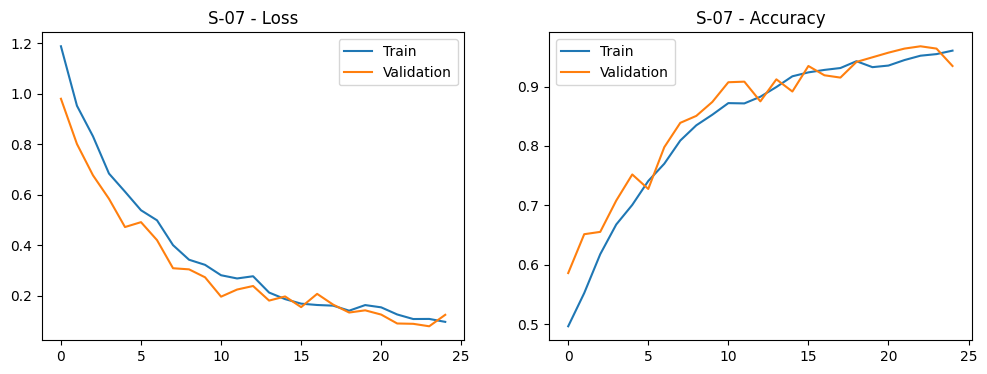


=== CLASSIFICATION REPORT: S-07 ===
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       172
           1       0.94      1.00      0.97        15
           2       0.99      0.94      0.96       634
           3       0.94      0.98      0.96       459

    accuracy                           0.96      1280
   macro avg       0.95      0.97      0.96      1280
weighted avg       0.96      0.96      0.96      1280



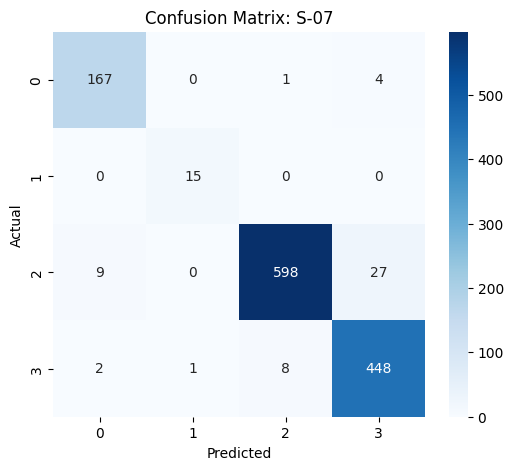


STARTING: S-08 | Opt: Adam | Sched: CosineAnnealingLR
Epoch 01/25 | LR: 9.96e-05 | Train Loss: 1.2087 Acc: 0.4773 | Val Loss: 1.0269 Acc: 0.5605
Epoch 02/25 | LR: 9.84e-05 | Train Loss: 0.9526 Acc: 0.5464 | Val Loss: 0.7923 Acc: 0.6387
Epoch 03/25 | LR: 9.65e-05 | Train Loss: 0.8328 Acc: 0.5920 | Val Loss: 0.7775 Acc: 0.5898
Epoch 04/25 | LR: 9.38e-05 | Train Loss: 0.7251 Acc: 0.6555 | Val Loss: 0.6328 Acc: 0.6621
Epoch 05/25 | LR: 9.05e-05 | Train Loss: 0.6311 Acc: 0.6973 | Val Loss: 0.5521 Acc: 0.7295
Epoch 06/25 | LR: 8.64e-05 | Train Loss: 0.5371 Acc: 0.7444 | Val Loss: 0.4332 Acc: 0.7949
Epoch 07/25 | LR: 8.19e-05 | Train Loss: 0.4731 Acc: 0.7822 | Val Loss: 0.4445 Acc: 0.7725
Epoch 08/25 | LR: 7.68e-05 | Train Loss: 0.4073 Acc: 0.7969 | Val Loss: 0.3429 Acc: 0.8271
Epoch 09/25 | LR: 7.13e-05 | Train Loss: 0.3592 Acc: 0.8354 | Val Loss: 0.3594 Acc: 0.8340
Epoch 10/25 | LR: 6.55e-05 | Train Loss: 0.2998 Acc: 0.8535 | Val Loss: 0.3139 Acc: 0.8418
Epoch 11/25 | LR: 5.94e-05 | Train 

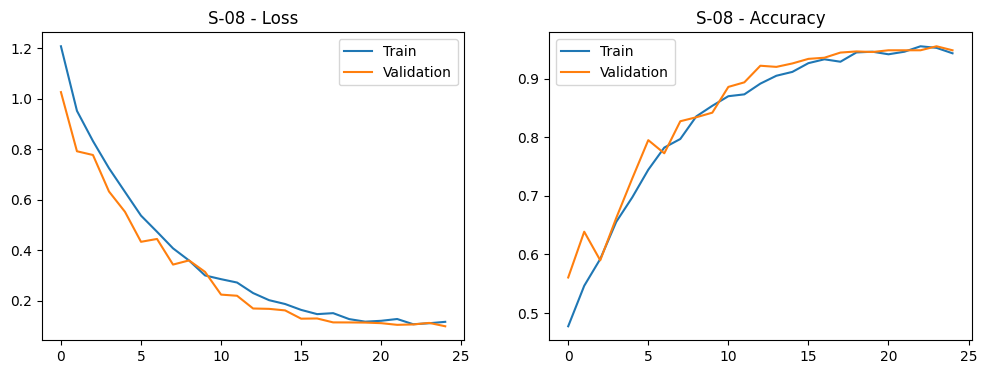


=== CLASSIFICATION REPORT: S-08 ===
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       172
           1       1.00      1.00      1.00        15
           2       0.97      0.95      0.96       634
           3       0.93      0.95      0.94       459

    accuracy                           0.95      1280
   macro avg       0.96      0.97      0.96      1280
weighted avg       0.95      0.95      0.95      1280



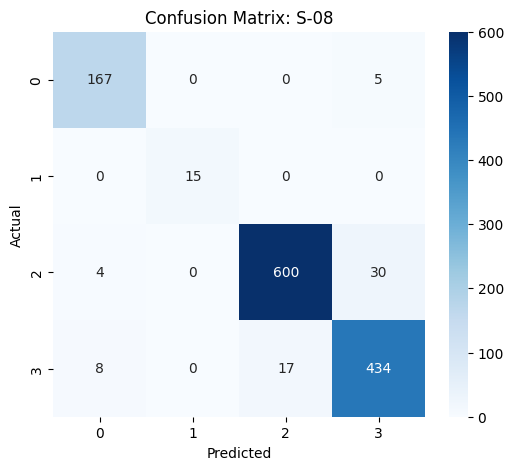


STARTING: S-09 | Opt: AdamW | Sched: ReduceLROnPlateau
Epoch 01/25 | LR: 1.00e-04 | Train Loss: 1.1747 Acc: 0.5044 | Val Loss: 0.9442 Acc: 0.5723
Epoch 02/25 | LR: 1.00e-04 | Train Loss: 0.9333 Acc: 0.5530 | Val Loss: 0.7998 Acc: 0.6182
Epoch 03/25 | LR: 1.00e-04 | Train Loss: 0.8117 Acc: 0.6096 | Val Loss: 0.6967 Acc: 0.6582
Epoch 04/25 | LR: 1.00e-04 | Train Loss: 0.6943 Acc: 0.6594 | Val Loss: 0.7342 Acc: 0.6943
Epoch 05/25 | LR: 1.00e-04 | Train Loss: 0.6202 Acc: 0.7026 | Val Loss: 0.5994 Acc: 0.7275
Epoch 06/25 | LR: 1.00e-04 | Train Loss: 0.5453 Acc: 0.7366 | Val Loss: 0.4671 Acc: 0.7578
Epoch 07/25 | LR: 1.00e-04 | Train Loss: 0.5156 Acc: 0.7642 | Val Loss: 0.4540 Acc: 0.7500
Epoch 08/25 | LR: 1.00e-04 | Train Loss: 0.4361 Acc: 0.7957 | Val Loss: 0.4194 Acc: 0.8164
Epoch 09/25 | LR: 1.00e-04 | Train Loss: 0.4189 Acc: 0.8274 | Val Loss: 0.3621 Acc: 0.8145
Epoch 10/25 | LR: 1.00e-04 | Train Loss: 0.3505 Acc: 0.8384 | Val Loss: 0.3280 Acc: 0.8330
Epoch 11/25 | LR: 1.00e-04 | Train

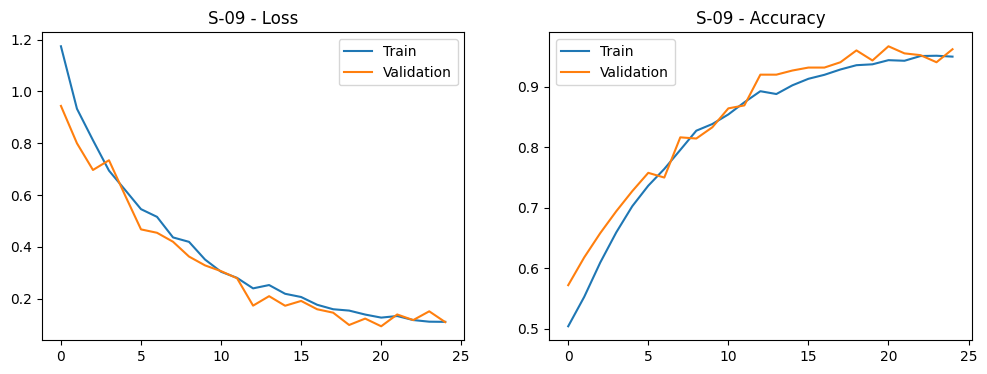


=== CLASSIFICATION REPORT: S-09 ===
              precision    recall  f1-score   support

           0       0.98      0.95      0.96       172
           1       1.00      1.00      1.00        15
           2       0.97      0.97      0.97       634
           3       0.94      0.95      0.94       459

    accuracy                           0.96      1280
   macro avg       0.97      0.97      0.97      1280
weighted avg       0.96      0.96      0.96      1280



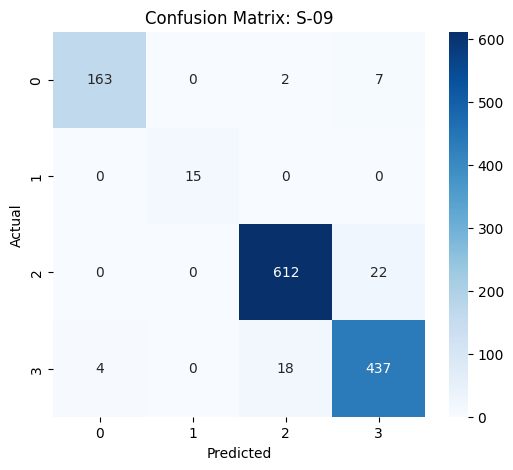


STARTING: S-10 | Opt: AdamW | Sched: CosineAnnealingLR
Epoch 01/25 | LR: 9.96e-05 | Train Loss: 1.1926 Acc: 0.5007 | Val Loss: 1.0693 Acc: 0.5449
Epoch 02/25 | LR: 9.84e-05 | Train Loss: 0.9603 Acc: 0.5569 | Val Loss: 0.8046 Acc: 0.6035
Epoch 03/25 | LR: 9.65e-05 | Train Loss: 0.8364 Acc: 0.6003 | Val Loss: 0.6908 Acc: 0.6445
Epoch 04/25 | LR: 9.38e-05 | Train Loss: 0.6890 Acc: 0.6550 | Val Loss: 0.9136 Acc: 0.5566
Epoch 05/25 | LR: 9.05e-05 | Train Loss: 0.6403 Acc: 0.6980 | Val Loss: 0.5484 Acc: 0.7461
Epoch 06/25 | LR: 8.64e-05 | Train Loss: 0.5491 Acc: 0.7358 | Val Loss: 0.4707 Acc: 0.7598
Epoch 07/25 | LR: 8.19e-05 | Train Loss: 0.4806 Acc: 0.7700 | Val Loss: 0.3663 Acc: 0.8203
Epoch 08/25 | LR: 7.68e-05 | Train Loss: 0.4062 Acc: 0.8101 | Val Loss: 0.3299 Acc: 0.8242
Epoch 09/25 | LR: 7.13e-05 | Train Loss: 0.3605 Acc: 0.8264 | Val Loss: 0.2985 Acc: 0.8613
Epoch 10/25 | LR: 6.55e-05 | Train Loss: 0.3262 Acc: 0.8462 | Val Loss: 0.2631 Acc: 0.8623
Epoch 11/25 | LR: 5.94e-05 | Train

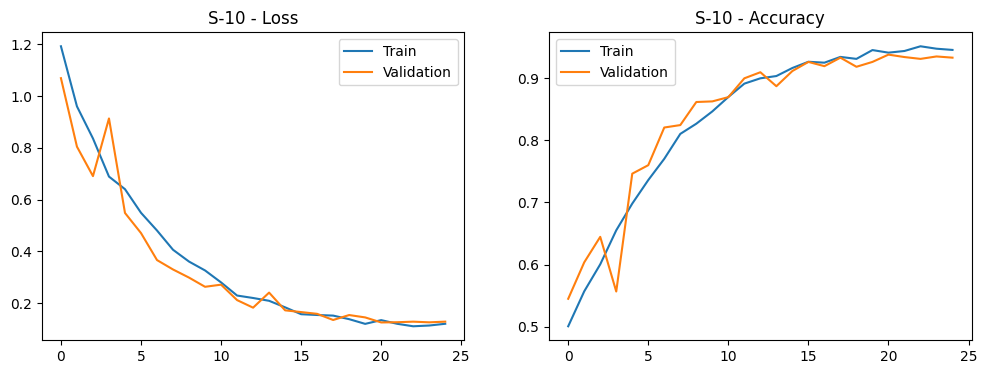


=== CLASSIFICATION REPORT: S-10 ===
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       172
           1       1.00      1.00      1.00        15
           2       0.96      0.95      0.95       634
           3       0.93      0.94      0.93       459

    accuracy                           0.95      1280
   macro avg       0.96      0.96      0.96      1280
weighted avg       0.95      0.95      0.95      1280



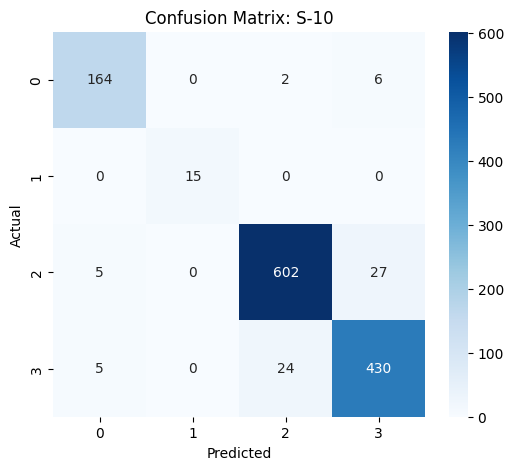

In [ ]:
# ==========================================
# 0. MOUNT GOOGLE DRIVE & SETUP FOLDER
# ==========================================
from google.colab import drive
import os

print("Mounting Google Drive...")
drive.mount('/content/drive')

# Buat folder khusus di Google Drive kamu
SAVE_DIR = '/content/drive/MyDrive/Alzheimer_EfficientNet_Models'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Semua model akan disimpan di: {SAVE_DIR}")

# ==========================================
# IMPORT LIBRARIES
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import numpy as np
import copy
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CONFIG & SETUP
# ==========================================
CONFIG = {
    "lr": 1e-4,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("\nLoading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"] # 5120 data
test_data = hf_dataset["test"]      # 1280 data

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

train_labels = np.array(train_data["label"])

# ==========================================
# 3. CLASS WEIGHTS UNTUK LOSS FUNCTION
# ==========================================
print("\nMenghitung Class Weights...")
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts

# Normalisasi bobot agar tidak terlalu besar/kecil (best practice)
class_weights = class_weights / class_weights.sum() * len(class_counts)

# Konversi ke Tensor dan pindahkan ke device
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"Class Weights Tensor: {class_weights_tensor}")

# ==========================================
# 4. DATASET WRAPPER
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

# ==========================================
# 5. DEFINE TRANSFORMS (AUG & NO AUG)
# ==========================================
base_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

aug_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==========================================
# 6. EXPERIMENT FUNCTION (UNFREEZE LAST LAYERS + SAVE DRIVE)
# ==========================================
def run_experiment(experiment_name, train_transform, opt_type, sched_type):
    print(f"\n{'='*60}")
    print(f"STARTING: {experiment_name} | Opt: {opt_type} | Sched: {sched_type}")
    print(f"{'='*60}")

    # --- Setup DataLoaders (Normal Shuffle, NO WeightedRandomSampler) ---
    train_ds = AlzheimerDataset(train_data, train_transform)
    val_ds   = AlzheimerDataset(val_data, base_transform)
    test_ds  = AlzheimerDataset(test_data, base_transform)

    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])
    val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
    test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

    # --- Setup Model ---
    model = efficientnet_b2(weights=EfficientNet_B2_Weights.DEFAULT)

    # 1. Freeze semua layer terlebih dahulu
    for param in model.features.parameters():
        param.requires_grad = False

    # 2. PERUBAHAN DI SINI: Unfreeze 4 layer terakhir di block features
    for param in model.features[-4:].parameters():
        param.requires_grad = True

    num_classes = len(np.unique(train_labels))
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(1408, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )
    model = model.to(device)

    # --- Loss & Optimizers ---
    # CLASS WEIGHT PADA LOSS FUNCTION
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

    # trainable_params akan otomatis mengambil classifier DAN 4 layer terakhir yang di-unfreeze
    trainable_params = filter(lambda p: p.requires_grad, model.parameters())

    if opt_type == 'Adam':
        optimizer = optim.Adam(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'AdamW':
        optimizer = optim.AdamW(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'SGD':
        optimizer = optim.SGD(trainable_params, lr=CONFIG["lr"], momentum=0.9)
    else:
        raise ValueError("Optimizer tidak dikenali!")

    # --- Dynamic Scheduler ---
    if sched_type == 'CosineAnnealingLR':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])
    elif sched_type == 'ReduceLROnPlateau':
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
    else:
        raise ValueError("Scheduler tidak dikenali!")

    # --- Training Loop ---
    train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []
    best_model = copy.deepcopy(model.state_dict())
    best_loss = float("inf")
    counter = 0

    for epoch in range(CONFIG["epochs"]):
        # ===== Train =====
        model.train()
        train_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss /= total
        train_acc = correct / total

        # Step Scheduler (CosineAnnealingLR)
        if sched_type == 'CosineAnnealingLR':
            scheduler.step()

        # ===== Validation =====
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        # Step Scheduler (ReduceLROnPlateau)
        if sched_type == 'ReduceLROnPlateau':
            scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:02d}/{CONFIG['epochs']} | LR: {current_lr:.2e} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        # ===== Early Stopping =====
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= CONFIG["patience"]:
                print("-> Early stopping triggered!")
                break

    # --- Load Best Model ---
    print(f"\nLoading best model for {experiment_name} testing...")
    model.load_state_dict(best_model)

    # ---------------------------------------------------------
    # SIMPAN MODEL KE GOOGLE DRIVE
    # ---------------------------------------------------------
    clean_name = experiment_name.replace(" ", "_").replace("-", "")
    model_filename = f"model_{clean_name}_{opt_type}_{sched_type}.pth"
    save_path = os.path.join(SAVE_DIR, model_filename)

    torch.save(model.state_dict(), save_path)
    print(f"Berhasil! Model disimpan di Drive: {save_path}")
    # ---------------------------------------------------------

    # --- Testing ---
    model.eval()
    all_probs, all_labels, all_preds = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())

    # --- Plotting & Metrics ---
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Validation")
    plt.title(f"{experiment_name} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label="Train")
    plt.plot(val_accuracies, label="Validation")
    plt.title(f"{experiment_name} - Accuracy")
    plt.legend()
    plt.show()

    print(f"\n=== CLASSIFICATION REPORT: {experiment_name} ===")
    print(classification_report(all_labels, all_preds))

    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix: {experiment_name}")
    plt.show()

# ==========================================
# 7. RUN PIPELINES (SCENARIOS S-07 to S-12)
# ==========================================
scenarios_unfreeze = [
    {"name": "S-07", "opt": "Adam",  "sched": "ReduceLROnPlateau"},
    {"name": "S-08", "opt": "Adam",  "sched": "CosineAnnealingLR"},
    {"name": "S-09", "opt": "AdamW", "sched": "ReduceLROnPlateau"},
    {"name": "S-10", "opt": "AdamW", "sched": "CosineAnnealingLR"},
    # {"name": "S-11", "opt": "SGD",   "sched": "ReduceLROnPlateau"},
    # {"name": "S-12", "opt": "SGD",   "sched": "CosineAnnealingLR"}
]

# Eksekusi loop untuk skenario Unfreeze Layer Terakhir
for scenario in scenarios_unfreeze:
    run_experiment(
        experiment_name=scenario["name"],
        train_transform=aug_transform, # Menggunakan augmentasi
        opt_type=scenario["opt"],
        sched_type=scenario["sched"]
    )

Mounting Google Drive...
Mounted at /content/drive
Semua model akan disimpan di: /content/drive/MyDrive/Alzheimer_EfficientNet_Models
Device: cuda

Loading dataset...


README.md:   0%|          | 0.00/2.13k [00:00<?, ?B/s]

data/train-00000-of-00001-c08a401c53fe53(…):   0%|          | 0.00/22.6M [00:00<?, ?B/s]

data/test-00000-of-00001-44110b9df98c558(…):   0%|          | 0.00/5.65M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5120 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1280 [00:00<?, ? examples/s]

Train: 4096 | Val: 1024 | Test: 1280

Menghitung Class Weights...
Class Weights Tensor: tensor([0.2419, 3.5916, 0.0682, 0.0983], device='cuda:0')

STARTING: S-11 | Opt: SGD | Sched: ReduceLROnPlateau
Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 201MB/s]


Epoch 01/25 | LR: 1.00e-04 | Train Loss: 1.3604 Acc: 0.3833 | Val Loss: 1.3447 Acc: 0.3809
Epoch 02/25 | LR: 1.00e-04 | Train Loss: 1.3278 Acc: 0.4045 | Val Loss: 1.3288 Acc: 0.4248
Epoch 03/25 | LR: 1.00e-04 | Train Loss: 1.3201 Acc: 0.4097 | Val Loss: 1.3166 Acc: 0.4746
Epoch 04/25 | LR: 1.00e-04 | Train Loss: 1.3148 Acc: 0.4341 | Val Loss: 1.3076 Acc: 0.5137
Epoch 05/25 | LR: 1.00e-04 | Train Loss: 1.3074 Acc: 0.4600 | Val Loss: 1.2991 Acc: 0.4932
Epoch 06/25 | LR: 1.00e-04 | Train Loss: 1.2933 Acc: 0.4666 | Val Loss: 1.2906 Acc: 0.5430
Epoch 07/25 | LR: 1.00e-04 | Train Loss: 1.2821 Acc: 0.4724 | Val Loss: 1.2806 Acc: 0.5576
Epoch 08/25 | LR: 1.00e-04 | Train Loss: 1.2785 Acc: 0.4705 | Val Loss: 1.2664 Acc: 0.5605
Epoch 09/25 | LR: 1.00e-04 | Train Loss: 1.2735 Acc: 0.4888 | Val Loss: 1.2565 Acc: 0.5654
Epoch 10/25 | LR: 1.00e-04 | Train Loss: 1.2593 Acc: 0.4924 | Val Loss: 1.2440 Acc: 0.5664
Epoch 11/25 | LR: 1.00e-04 | Train Loss: 1.2432 Acc: 0.5068 | Val Loss: 1.2344 Acc: 0.5732

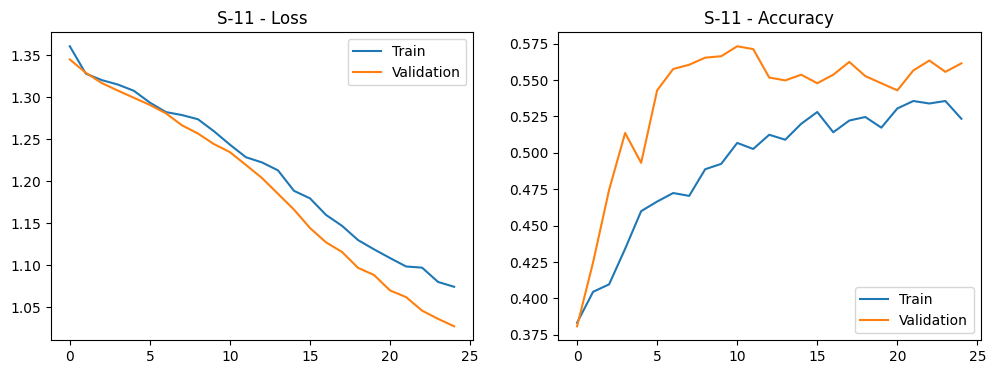


=== CLASSIFICATION REPORT: S-11 ===
              precision    recall  f1-score   support

           0       0.29      0.66      0.41       172
           1       0.00      0.00      0.00        15
           2       0.71      0.65      0.68       634
           3       0.46      0.31      0.37       459

    accuracy                           0.53      1280
   macro avg       0.37      0.41      0.37      1280
weighted avg       0.56      0.53      0.53      1280



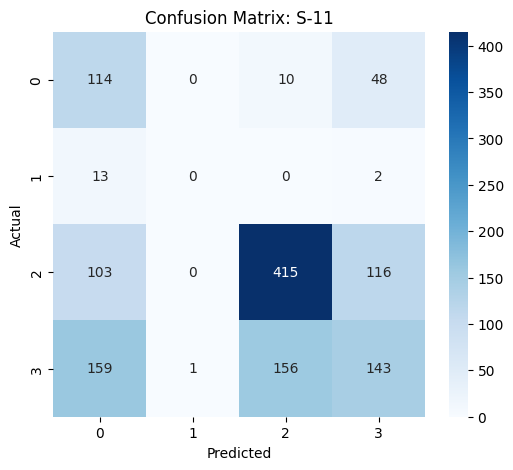


STARTING: S-12 | Opt: SGD | Sched: CosineAnnealingLR
Epoch 01/25 | LR: 9.96e-05 | Train Loss: 1.3537 Acc: 0.4172 | Val Loss: 1.3475 Acc: 0.4971
Epoch 02/25 | LR: 9.84e-05 | Train Loss: 1.3281 Acc: 0.4282 | Val Loss: 1.3309 Acc: 0.5146
Epoch 03/25 | LR: 9.65e-05 | Train Loss: 1.3095 Acc: 0.4429 | Val Loss: 1.3200 Acc: 0.5127
Epoch 04/25 | LR: 9.38e-05 | Train Loss: 1.3100 Acc: 0.4485 | Val Loss: 1.3084 Acc: 0.5205
Epoch 05/25 | LR: 9.05e-05 | Train Loss: 1.2942 Acc: 0.4741 | Val Loss: 1.2992 Acc: 0.5205
Epoch 06/25 | LR: 8.64e-05 | Train Loss: 1.2921 Acc: 0.4709 | Val Loss: 1.2909 Acc: 0.5264
Epoch 07/25 | LR: 8.19e-05 | Train Loss: 1.2792 Acc: 0.4966 | Val Loss: 1.2826 Acc: 0.5312
Epoch 08/25 | LR: 7.68e-05 | Train Loss: 1.2729 Acc: 0.4944 | Val Loss: 1.2725 Acc: 0.5352
Epoch 09/25 | LR: 7.13e-05 | Train Loss: 1.2583 Acc: 0.5085 | Val Loss: 1.2579 Acc: 0.5381
Epoch 10/25 | LR: 6.55e-05 | Train Loss: 1.2570 Acc: 0.4985 | Val Loss: 1.2536 Acc: 0.5459
Epoch 11/25 | LR: 5.94e-05 | Train L

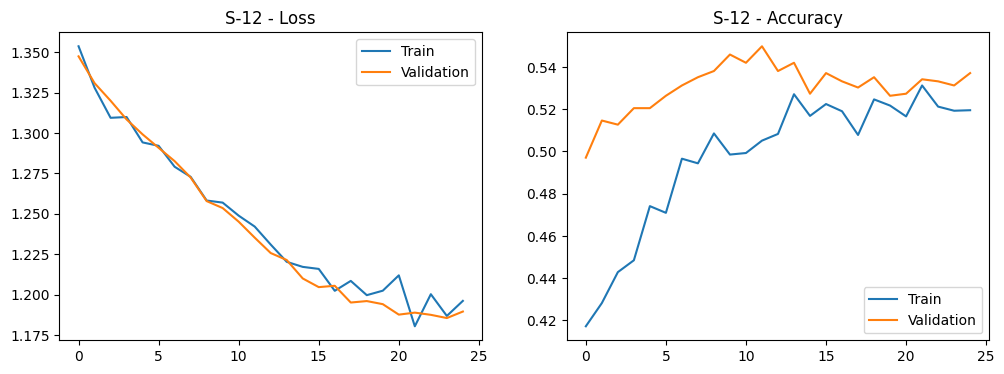


=== CLASSIFICATION REPORT: S-12 ===
              precision    recall  f1-score   support

           0       0.30      0.61      0.40       172
           1       0.00      0.00      0.00        15
           2       0.64      0.75      0.69       634
           3       0.55      0.22      0.31       459

    accuracy                           0.53      1280
   macro avg       0.37      0.40      0.35      1280
weighted avg       0.55      0.53      0.51      1280



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


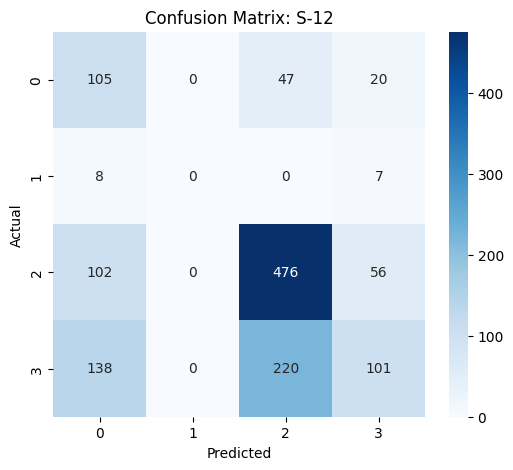

In [ ]:
# ==========================================
# 0. MOUNT GOOGLE DRIVE & SETUP FOLDER
# ==========================================
from google.colab import drive
import os

print("Mounting Google Drive...")
drive.mount('/content/drive')

# Buat folder khusus di Google Drive kamu
SAVE_DIR = '/content/drive/MyDrive/Alzheimer_EfficientNet_Models'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Semua model akan disimpan di: {SAVE_DIR}")

# ==========================================
# IMPORT LIBRARIES
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import numpy as np
import copy
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CONFIG & SETUP
# ==========================================
CONFIG = {
    "lr": 1e-4,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("\nLoading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"] # 5120 data
test_data = hf_dataset["test"]      # 1280 data

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

train_labels = np.array(train_data["label"])

# ==========================================
# 3. CLASS WEIGHTS UNTUK LOSS FUNCTION
# ==========================================
print("\nMenghitung Class Weights...")
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts

# Normalisasi bobot agar tidak terlalu besar/kecil (best practice)
class_weights = class_weights / class_weights.sum() * len(class_counts)

# Konversi ke Tensor dan pindahkan ke device
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"Class Weights Tensor: {class_weights_tensor}")

# ==========================================
# 4. DATASET WRAPPER
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

# ==========================================
# 5. DEFINE TRANSFORMS (AUG & NO AUG)
# ==========================================
base_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

aug_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==========================================
# 6. EXPERIMENT FUNCTION (UNFREEZE LAST LAYERS + SAVE DRIVE)
# ==========================================
def run_experiment(experiment_name, train_transform, opt_type, sched_type):
    print(f"\n{'='*60}")
    print(f"STARTING: {experiment_name} | Opt: {opt_type} | Sched: {sched_type}")
    print(f"{'='*60}")

    # --- Setup DataLoaders (Normal Shuffle, NO WeightedRandomSampler) ---
    train_ds = AlzheimerDataset(train_data, train_transform)
    val_ds   = AlzheimerDataset(val_data, base_transform)
    test_ds  = AlzheimerDataset(test_data, base_transform)

    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])
    val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
    test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

    # --- Setup Model ---
    model = efficientnet_b2(weights=EfficientNet_B2_Weights.DEFAULT)

    # 1. Freeze semua layer terlebih dahulu
    for param in model.features.parameters():
        param.requires_grad = False

    # 2. PERUBAHAN DI SINI: Unfreeze 4 layer terakhir di block features
    for param in model.features[-4:].parameters():
        param.requires_grad = True

    num_classes = len(np.unique(train_labels))
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(1408, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )
    model = model.to(device)

    # --- Loss & Optimizers ---
    # CLASS WEIGHT PADA LOSS FUNCTION
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

    # trainable_params akan otomatis mengambil classifier DAN 4 layer terakhir yang di-unfreeze
    trainable_params = filter(lambda p: p.requires_grad, model.parameters())

    if opt_type == 'Adam':
        optimizer = optim.Adam(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'AdamW':
        optimizer = optim.AdamW(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'SGD':
        optimizer = optim.SGD(trainable_params, lr=CONFIG["lr"], momentum=0.9)
    else:
        raise ValueError("Optimizer tidak dikenali!")

    # --- Dynamic Scheduler ---
    if sched_type == 'CosineAnnealingLR':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])
    elif sched_type == 'ReduceLROnPlateau':
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
    else:
        raise ValueError("Scheduler tidak dikenali!")

    # --- Training Loop ---
    train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []
    best_model = copy.deepcopy(model.state_dict())
    best_loss = float("inf")
    counter = 0

    for epoch in range(CONFIG["epochs"]):
        # ===== Train =====
        model.train()
        train_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss /= total
        train_acc = correct / total

        # Step Scheduler (CosineAnnealingLR)
        if sched_type == 'CosineAnnealingLR':
            scheduler.step()

        # ===== Validation =====
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        # Step Scheduler (ReduceLROnPlateau)
        if sched_type == 'ReduceLROnPlateau':
            scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:02d}/{CONFIG['epochs']} | LR: {current_lr:.2e} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        # ===== Early Stopping =====
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= CONFIG["patience"]:
                print("-> Early stopping triggered!")
                break

    # --- Load Best Model ---
    print(f"\nLoading best model for {experiment_name} testing...")
    model.load_state_dict(best_model)

    # ---------------------------------------------------------
    # SIMPAN MODEL KE GOOGLE DRIVE
    # ---------------------------------------------------------
    clean_name = experiment_name.replace(" ", "_").replace("-", "")
    model_filename = f"model_{clean_name}_{opt_type}_{sched_type}.pth"
    save_path = os.path.join(SAVE_DIR, model_filename)

    torch.save(model.state_dict(), save_path)
    print(f"Berhasil! Model disimpan di Drive: {save_path}")
    # ---------------------------------------------------------

    # --- Testing ---
    model.eval()
    all_probs, all_labels, all_preds = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())

    # --- Plotting & Metrics ---
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Validation")
    plt.title(f"{experiment_name} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label="Train")
    plt.plot(val_accuracies, label="Validation")
    plt.title(f"{experiment_name} - Accuracy")
    plt.legend()
    plt.show()

    print(f"\n=== CLASSIFICATION REPORT: {experiment_name} ===")
    print(classification_report(all_labels, all_preds))

    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix: {experiment_name}")
    plt.show()

# ==========================================
# 7. RUN PIPELINES (SCENARIOS S-07 to S-12)
# ==========================================
scenarios_unfreeze = [
    # {"name": "S-07", "opt": "Adam",  "sched": "ReduceLROnPlateau"},
    # {"name": "S-08", "opt": "Adam",  "sched": "CosineAnnealingLR"},
    # {"name": "S-09", "opt": "AdamW", "sched": "ReduceLROnPlateau"},
    # {"name": "S-10", "opt": "AdamW", "sched": "CosineAnnealingLR"},
     {"name": "S-11", "opt": "SGD",   "sched": "ReduceLROnPlateau"},
     {"name": "S-12", "opt": "SGD",   "sched": "CosineAnnealingLR"}
]

# Eksekusi loop untuk skenario Unfreeze Layer Terakhir
for scenario in scenarios_unfreeze:
    run_experiment(
        experiment_name=scenario["name"],
        train_transform=aug_transform, # Menggunakan augmentasi
        opt_type=scenario["opt"],
        sched_type=scenario["sched"]
    )

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Semua model akan disimpan di: /content/drive/MyDrive/Alzheimer_EfficientNet_Models
Device: cuda

Loading dataset...
Train: 4096 | Val: 1024 | Test: 1280

Menghitung Class Weights...
Class Weights Tensor: tensor([0.2419, 3.5916, 0.0682, 0.0983], device='cuda:0')

STARTING: S-13 | Opt: Adam | Sched: ReduceLROnPlateau
Epoch 01/25 | LR: 1.00e-04 | Train Loss: 1.1645 Acc: 0.4963 | Val Loss: 0.9595 Acc: 0.5732
Epoch 02/25 | LR: 1.00e-04 | Train Loss: 0.8956 Acc: 0.5701 | Val Loss: 0.7853 Acc: 0.6025
Epoch 03/25 | LR: 1.00e-04 | Train Loss: 0.7295 Acc: 0.6411 | Val Loss: 0.6594 Acc: 0.6426
Epoch 04/25 | LR: 1.00e-04 | Train Loss: 0.5782 Acc: 0.7217 | Val Loss: 0.4418 Acc: 0.7871
Epoch 05/25 | LR: 1.00e-04 | Train Loss: 0.4755 Acc: 0.7769 | Val Loss: 0.3325 Acc: 0.8262
Epoch 06/25 | LR: 1.00e-04 | Train Loss: 0.3797 Acc: 0.8269 | Val Loss: 0.

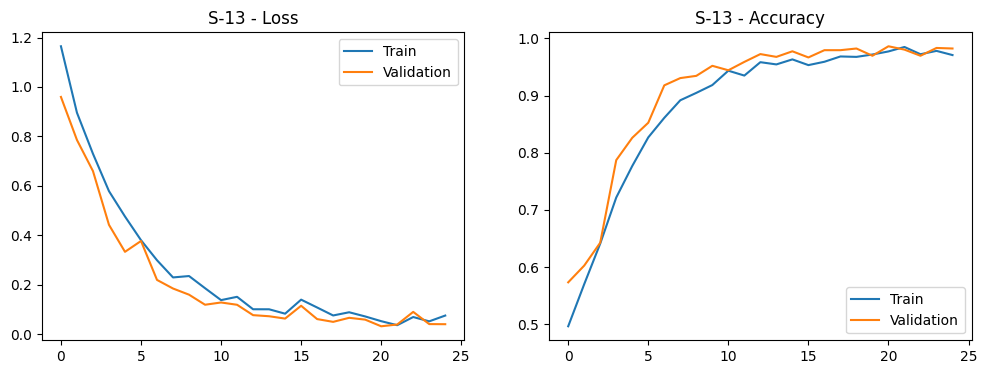


=== CLASSIFICATION REPORT: S-13 ===
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       172
           1       1.00      1.00      1.00        15
           2       0.99      0.99      0.99       634
           3       0.98      0.99      0.99       459

    accuracy                           0.99      1280
   macro avg       0.99      0.99      0.99      1280
weighted avg       0.99      0.99      0.99      1280



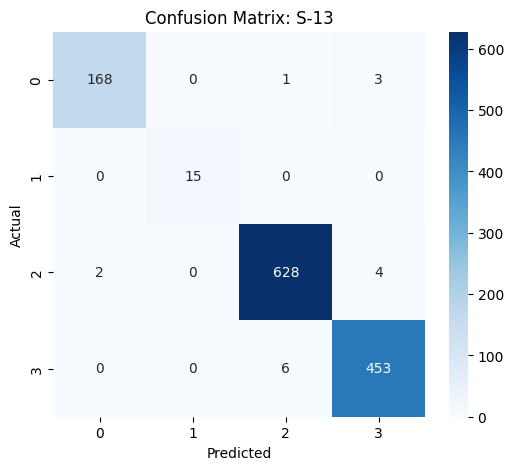


STARTING: S-14 | Opt: Adam | Sched: CosineAnnealingLR
Epoch 01/25 | LR: 9.96e-05 | Train Loss: 1.1746 Acc: 0.4751 | Val Loss: 0.9794 Acc: 0.5244
Epoch 02/25 | LR: 9.84e-05 | Train Loss: 0.9107 Acc: 0.5779 | Val Loss: 0.7280 Acc: 0.6572
Epoch 03/25 | LR: 9.65e-05 | Train Loss: 0.7688 Acc: 0.6377 | Val Loss: 0.6968 Acc: 0.6338
Epoch 04/25 | LR: 9.38e-05 | Train Loss: 0.6093 Acc: 0.7061 | Val Loss: 0.5135 Acc: 0.7422
Epoch 05/25 | LR: 9.05e-05 | Train Loss: 0.4732 Acc: 0.7778 | Val Loss: 0.3837 Acc: 0.8066
Epoch 06/25 | LR: 8.64e-05 | Train Loss: 0.3561 Acc: 0.8308 | Val Loss: 0.3368 Acc: 0.8486
Epoch 07/25 | LR: 8.19e-05 | Train Loss: 0.2865 Acc: 0.8669 | Val Loss: 0.2203 Acc: 0.8955
Epoch 08/25 | LR: 7.68e-05 | Train Loss: 0.2533 Acc: 0.8855 | Val Loss: 0.1335 Acc: 0.9395
Epoch 09/25 | LR: 7.13e-05 | Train Loss: 0.2095 Acc: 0.9146 | Val Loss: 0.1416 Acc: 0.9414
Epoch 10/25 | LR: 6.55e-05 | Train Loss: 0.1759 Acc: 0.9277 | Val Loss: 0.1333 Acc: 0.9277
Epoch 11/25 | LR: 5.94e-05 | Train 

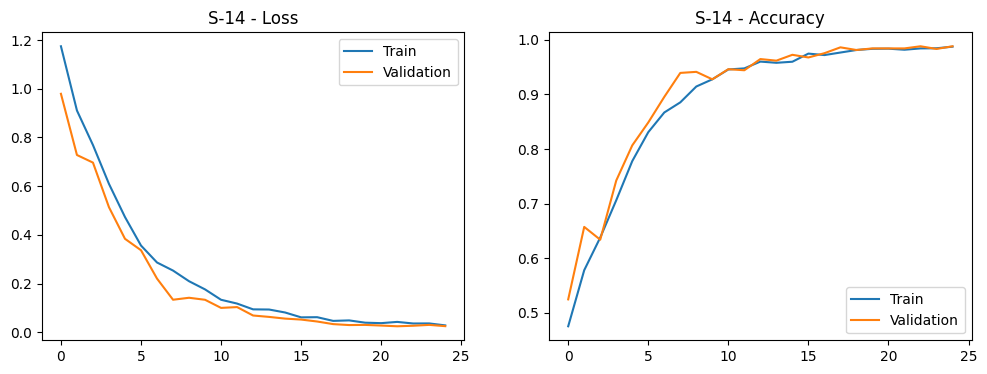


=== CLASSIFICATION REPORT: S-14 ===
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       172
           1       1.00      1.00      1.00        15
           2       0.99      0.98      0.99       634
           3       0.98      0.98      0.98       459

    accuracy                           0.98      1280
   macro avg       0.99      0.99      0.99      1280
weighted avg       0.98      0.98      0.98      1280



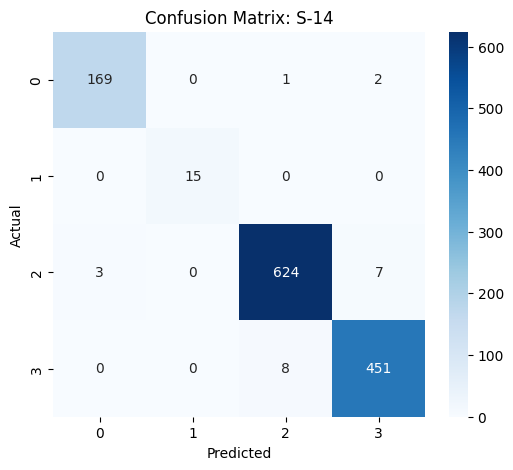


STARTING: S-15 | Opt: AdamW | Sched: ReduceLROnPlateau
Epoch 01/25 | LR: 1.00e-04 | Train Loss: 1.1766 Acc: 0.4907 | Val Loss: 0.9677 Acc: 0.5557
Epoch 02/25 | LR: 1.00e-04 | Train Loss: 0.8994 Acc: 0.5671 | Val Loss: 0.7384 Acc: 0.6143
Epoch 03/25 | LR: 1.00e-04 | Train Loss: 0.7688 Acc: 0.6323 | Val Loss: 0.6382 Acc: 0.7139
Epoch 04/25 | LR: 1.00e-04 | Train Loss: 0.5874 Acc: 0.7175 | Val Loss: 0.4370 Acc: 0.7900
Epoch 05/25 | LR: 1.00e-04 | Train Loss: 0.4871 Acc: 0.7642 | Val Loss: 0.4199 Acc: 0.7998
Epoch 06/25 | LR: 1.00e-04 | Train Loss: 0.3832 Acc: 0.8291 | Val Loss: 0.4592 Acc: 0.8428
Epoch 07/25 | LR: 1.00e-04 | Train Loss: 0.3060 Acc: 0.8613 | Val Loss: 0.3428 Acc: 0.8223
Epoch 08/25 | LR: 1.00e-04 | Train Loss: 0.2354 Acc: 0.8936 | Val Loss: 0.1716 Acc: 0.9258
Epoch 09/25 | LR: 1.00e-04 | Train Loss: 0.2016 Acc: 0.9102 | Val Loss: 0.1904 Acc: 0.9082
Epoch 10/25 | LR: 1.00e-04 | Train Loss: 0.2240 Acc: 0.9119 | Val Loss: 0.1518 Acc: 0.9375
Epoch 11/25 | LR: 1.00e-04 | Train

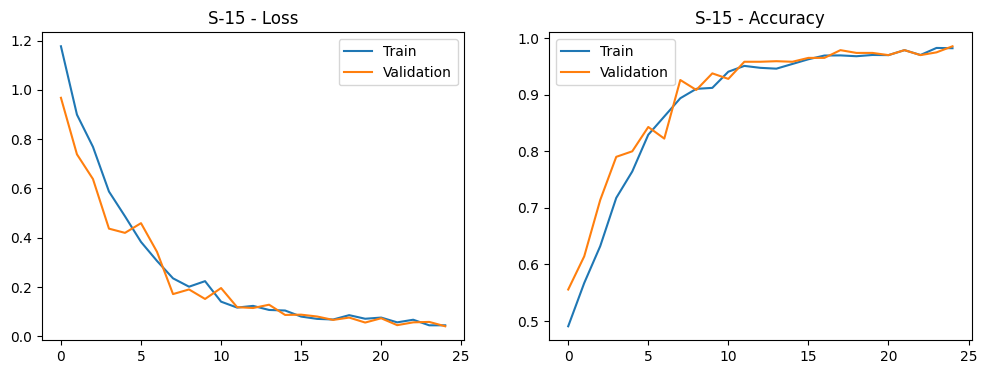


=== CLASSIFICATION REPORT: S-15 ===
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       172
           1       1.00      1.00      1.00        15
           2       1.00      0.99      0.99       634
           3       0.98      0.99      0.99       459

    accuracy                           0.99      1280
   macro avg       0.99      0.99      0.99      1280
weighted avg       0.99      0.99      0.99      1280



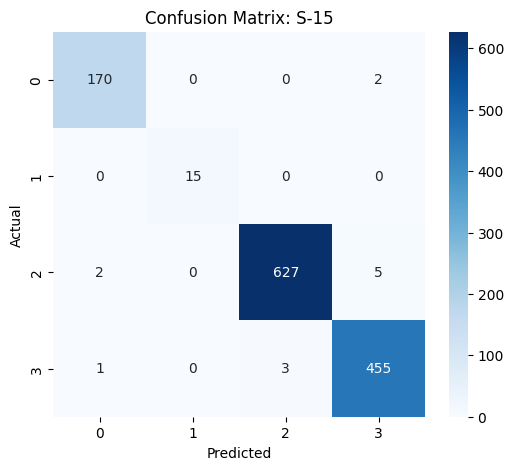

In [ ]:
# ==========================================
# 0. MOUNT GOOGLE DRIVE & SETUP FOLDER
# ==========================================
from google.colab import drive
import os

print("Mounting Google Drive...")
drive.mount('/content/drive')

# Buat folder khusus di Google Drive kamu
SAVE_DIR = '/content/drive/MyDrive/Alzheimer_EfficientNet_Models'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Semua model akan disimpan di: {SAVE_DIR}")

# ==========================================
# IMPORT LIBRARIES
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import numpy as np
import copy
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CONFIG & SETUP
# ==========================================
CONFIG = {
    "lr": 1e-4,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("\nLoading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"] # 5120 data
test_data = hf_dataset["test"]      # 1280 data

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")
train_labels = np.array(train_data["label"])

# ==========================================
# 3. CLASS WEIGHTS UNTUK LOSS FUNCTION
# ==========================================
print("\nMenghitung Class Weights...")
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_counts)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"Class Weights Tensor: {class_weights_tensor}")

# ==========================================
# 4. DATASET WRAPPER
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

# ==========================================
# 5. DEFINE TRANSFORMS (AUG & NO AUG)
# ==========================================
base_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

aug_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==========================================
# 6. EXPERIMENT FUNCTION (FULL TUNING + SAVE DRIVE)
# ==========================================
def run_experiment(experiment_name, train_transform, opt_type, sched_type):
    print(f"\n{'='*60}")
    print(f"STARTING: {experiment_name} | Opt: {opt_type} | Sched: {sched_type}")
    print(f"{'='*60}")

    # --- Setup DataLoaders ---
    train_ds = AlzheimerDataset(train_data, train_transform)
    val_ds   = AlzheimerDataset(val_data, base_transform)
    test_ds  = AlzheimerDataset(test_data, base_transform)

    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])
    val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
    test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

    # --- Setup Model ---
    model = efficientnet_b2(weights=EfficientNet_B2_Weights.DEFAULT)

    # PERUBAHAN DI SINI: Full Fine-Tuning (Pastikan SEMUA layer terbuka)
    for param in model.parameters():
        param.requires_grad = True

    num_classes = len(np.unique(train_labels))
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(1408, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )
    model = model.to(device)

    # --- Loss & Optimizers ---
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

    # Karena Full Tuning, semua parameter masuk ke optimizer
    trainable_params = filter(lambda p: p.requires_grad, model.parameters())

    if opt_type == 'Adam':
        optimizer = optim.Adam(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'AdamW':
        optimizer = optim.AdamW(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'SGD':
        optimizer = optim.SGD(trainable_params, lr=CONFIG["lr"], momentum=0.9)
    else:
        raise ValueError("Optimizer tidak dikenali!")

    # --- Dynamic Scheduler ---
    if sched_type == 'CosineAnnealingLR':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])
    elif sched_type == 'ReduceLROnPlateau':
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
    else:
        raise ValueError("Scheduler tidak dikenali!")

    # --- Training Loop ---
    train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []
    best_model = copy.deepcopy(model.state_dict())
    best_loss = float("inf")
    counter = 0

    for epoch in range(CONFIG["epochs"]):
        # ===== Train =====
        model.train()
        train_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss /= total
        train_acc = correct / total

        if sched_type == 'CosineAnnealingLR':
            scheduler.step()

        # ===== Validation =====
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        if sched_type == 'ReduceLROnPlateau':
            scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:02d}/{CONFIG['epochs']} | LR: {current_lr:.2e} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        # ===== Early Stopping =====
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= CONFIG["patience"]:
                print("-> Early stopping triggered!")
                break

    # --- Load Best Model ---
    print(f"\nLoading best model for {experiment_name} testing...")
    model.load_state_dict(best_model)

    # ---------------------------------------------------------
    # SIMPAN MODEL KE GOOGLE DRIVE
    # ---------------------------------------------------------
    clean_name = experiment_name.replace(" ", "_").replace("-", "")
    model_filename = f"model_{clean_name}_{opt_type}_{sched_type}.pth"
    save_path = os.path.join(SAVE_DIR, model_filename)

    torch.save(model.state_dict(), save_path)
    print(f"Berhasil! Model disimpan di Drive: {save_path}")
    # ---------------------------------------------------------

    # --- Testing ---
    model.eval()
    all_probs, all_labels, all_preds = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())

    # --- Plotting & Metrics ---
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Validation")
    plt.title(f"{experiment_name} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label="Train")
    plt.plot(val_accuracies, label="Validation")
    plt.title(f"{experiment_name} - Accuracy")
    plt.legend()
    plt.show()

    print(f"\n=== CLASSIFICATION REPORT: {experiment_name} ===")
    print(classification_report(all_labels, all_preds))

    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix: {experiment_name}")
    plt.show()

# ==========================================
# 7. RUN PIPELINES (SCENARIOS S-13 to S-18)
# ==========================================
scenarios_full_tuning = [
    {"name": "S-13", "opt": "Adam",  "sched": "ReduceLROnPlateau"},
    {"name": "S-14", "opt": "Adam",  "sched": "CosineAnnealingLR"},
    {"name": "S-15", "opt": "AdamW", "sched": "ReduceLROnPlateau"},
    # {"name": "S-16", "opt": "AdamW", "sched": "CosineAnnealingLR"},
    # {"name": "S-17", "opt": "SGD",   "sched": "ReduceLROnPlateau"},
    # {"name": "S-18", "opt": "SGD",   "sched": "CosineAnnealingLR"}
]

# Eksekusi loop untuk skenario Full Fine-Tuning
for scenario in scenarios_full_tuning:
    run_experiment(
        experiment_name=scenario["name"],
        train_transform=aug_transform, # Menggunakan augmentasi
        opt_type=scenario["opt"],
        sched_type=scenario["sched"]
    )

# Weighted (Saved Model)

Mounting Google Drive...
Mounted at /content/drive
Semua model akan disimpan di: /content/drive/MyDrive/Alzheimer_EfficientNet_Models_Sampler
Device: cuda

Loading dataset...


README.md:   0%|          | 0.00/2.13k [00:00<?, ?B/s]

data/train-00000-of-00001-c08a401c53fe53(…):   0%|          | 0.00/22.6M [00:00<?, ?B/s]

data/test-00000-of-00001-44110b9df98c558(…):   0%|          | 0.00/5.65M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5120 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1280 [00:00<?, ? examples/s]

Train: 4096 | Val: 1024 | Test: 1280

Menghitung Class Weights...
Class Weights Tensor: tensor([0.2419, 3.5916, 0.0682, 0.0983], device='cuda:0')

STARTING: S-01 | Opt: Adam | Sched: ReduceLROnPlateau
Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 188MB/s]


Epoch 01/25 | LR: 1.00e-04 | Train Loss: 1.2962 Acc: 0.4707 | Val Loss: 1.2610 Acc: 0.5166
Epoch 02/25 | LR: 1.00e-04 | Train Loss: 1.2438 Acc: 0.4851 | Val Loss: 1.1979 Acc: 0.5410
Epoch 03/25 | LR: 1.00e-04 | Train Loss: 1.1792 Acc: 0.5181 | Val Loss: 1.1657 Acc: 0.5479
Epoch 04/25 | LR: 1.00e-04 | Train Loss: 1.1809 Acc: 0.5186 | Val Loss: 1.1379 Acc: 0.5498
Epoch 05/25 | LR: 1.00e-04 | Train Loss: 1.1661 Acc: 0.5007 | Val Loss: 1.1335 Acc: 0.5400
Epoch 06/25 | LR: 1.00e-04 | Train Loss: 1.1407 Acc: 0.5144 | Val Loss: 1.1014 Acc: 0.5488
Epoch 07/25 | LR: 1.00e-04 | Train Loss: 1.1457 Acc: 0.5178 | Val Loss: 1.0939 Acc: 0.5234
Epoch 08/25 | LR: 1.00e-04 | Train Loss: 1.1223 Acc: 0.5225 | Val Loss: 1.0835 Acc: 0.5586
Epoch 09/25 | LR: 1.00e-04 | Train Loss: 1.1217 Acc: 0.5132 | Val Loss: 1.0747 Acc: 0.5557
Epoch 10/25 | LR: 1.00e-04 | Train Loss: 1.1270 Acc: 0.5134 | Val Loss: 1.0558 Acc: 0.5723
Epoch 11/25 | LR: 1.00e-04 | Train Loss: 1.0858 Acc: 0.5215 | Val Loss: 1.0435 Acc: 0.5576

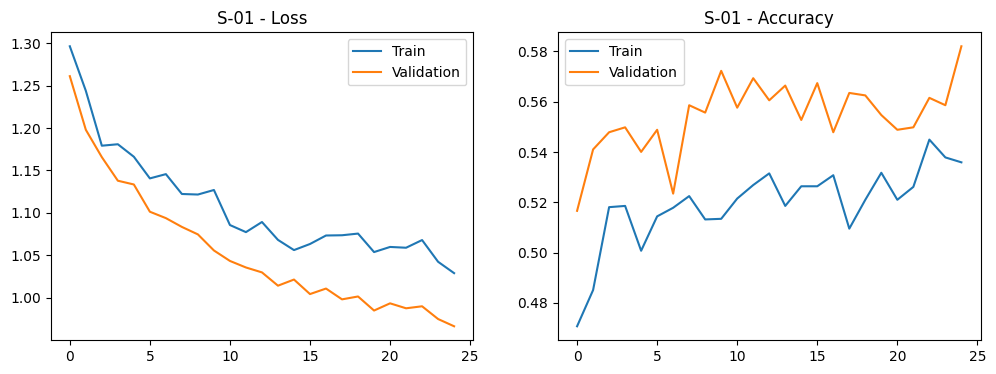


=== CLASSIFICATION REPORT: S-01 ===
              precision    recall  f1-score   support

           0       0.36      0.45      0.40       172
           1       0.27      1.00      0.43        15
           2       0.69      0.68      0.68       634
           3       0.51      0.43      0.47       459

    accuracy                           0.56      1280
   macro avg       0.46      0.64      0.49      1280
weighted avg       0.58      0.56      0.57      1280



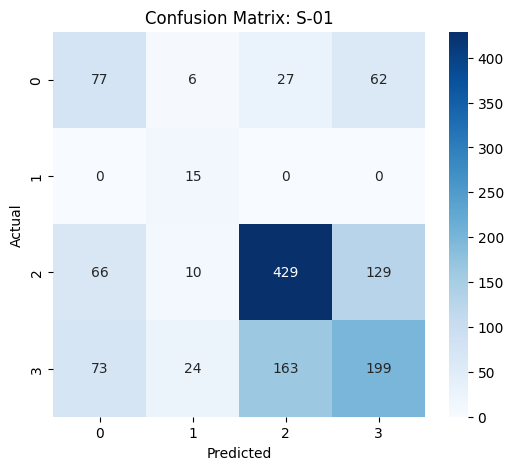


STARTING: S-02 | Opt: Adam | Sched: CosineAnnealingLR
Epoch 01/25 | LR: 9.96e-05 | Train Loss: 1.3093 Acc: 0.4773 | Val Loss: 1.2612 Acc: 0.5625
Epoch 02/25 | LR: 9.84e-05 | Train Loss: 1.2437 Acc: 0.4968 | Val Loss: 1.2055 Acc: 0.5527
Epoch 03/25 | LR: 9.65e-05 | Train Loss: 1.2079 Acc: 0.5071 | Val Loss: 1.1757 Acc: 0.5723
Epoch 04/25 | LR: 9.38e-05 | Train Loss: 1.1709 Acc: 0.5205 | Val Loss: 1.1554 Acc: 0.5693
Epoch 05/25 | LR: 9.05e-05 | Train Loss: 1.1656 Acc: 0.5156 | Val Loss: 1.1375 Acc: 0.5449
Epoch 06/25 | LR: 8.64e-05 | Train Loss: 1.1676 Acc: 0.5205 | Val Loss: 1.1154 Acc: 0.5625
Epoch 07/25 | LR: 8.19e-05 | Train Loss: 1.1445 Acc: 0.5193 | Val Loss: 1.1018 Acc: 0.5664
Epoch 08/25 | LR: 7.68e-05 | Train Loss: 1.1274 Acc: 0.5286 | Val Loss: 1.0870 Acc: 0.5566
Epoch 09/25 | LR: 7.13e-05 | Train Loss: 1.1249 Acc: 0.5247 | Val Loss: 1.0834 Acc: 0.5605
Epoch 10/25 | LR: 6.55e-05 | Train Loss: 1.1227 Acc: 0.5220 | Val Loss: 1.0739 Acc: 0.5576
Epoch 11/25 | LR: 5.94e-05 | Train 

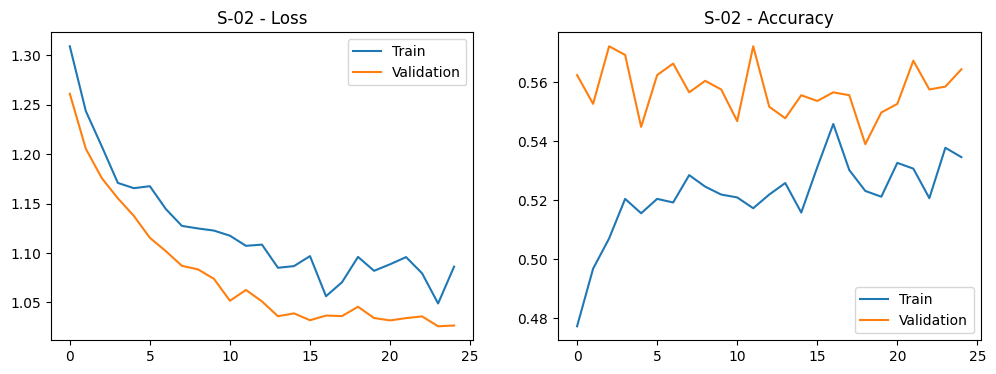


=== CLASSIFICATION REPORT: S-02 ===
              precision    recall  f1-score   support

           0       0.34      0.51      0.41       172
           1       0.19      0.73      0.30        15
           2       0.70      0.65      0.67       634
           3       0.50      0.41      0.45       459

    accuracy                           0.54      1280
   macro avg       0.43      0.58      0.46      1280
weighted avg       0.57      0.54      0.55      1280



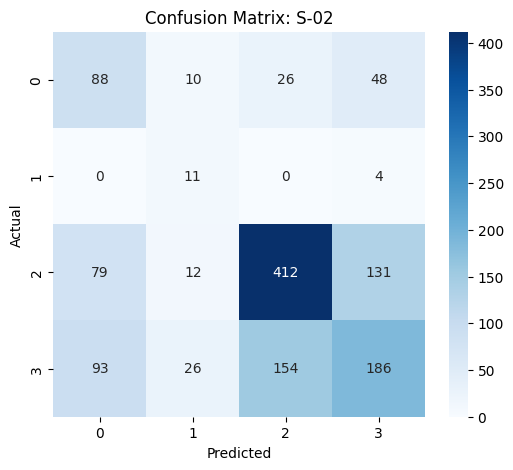


STARTING: S-03 | Opt: AdamW | Sched: ReduceLROnPlateau
Epoch 01/25 | LR: 1.00e-04 | Train Loss: 1.3062 Acc: 0.4592 | Val Loss: 1.2597 Acc: 0.5635
Epoch 02/25 | LR: 1.00e-04 | Train Loss: 1.2390 Acc: 0.5039 | Val Loss: 1.1993 Acc: 0.5615
Epoch 03/25 | LR: 1.00e-04 | Train Loss: 1.2101 Acc: 0.5071 | Val Loss: 1.1731 Acc: 0.5732
Epoch 04/25 | LR: 1.00e-04 | Train Loss: 1.1795 Acc: 0.5156 | Val Loss: 1.1408 Acc: 0.5664
Epoch 05/25 | LR: 1.00e-04 | Train Loss: 1.1774 Acc: 0.5203 | Val Loss: 1.1269 Acc: 0.5498
Epoch 06/25 | LR: 1.00e-04 | Train Loss: 1.1478 Acc: 0.5217 | Val Loss: 1.1008 Acc: 0.5752
Epoch 07/25 | LR: 1.00e-04 | Train Loss: 1.1248 Acc: 0.5303 | Val Loss: 1.0874 Acc: 0.5840
Epoch 08/25 | LR: 1.00e-04 | Train Loss: 1.1200 Acc: 0.5266 | Val Loss: 1.0708 Acc: 0.5605
Epoch 09/25 | LR: 1.00e-04 | Train Loss: 1.1242 Acc: 0.5242 | Val Loss: 1.0644 Acc: 0.5420
Epoch 10/25 | LR: 1.00e-04 | Train Loss: 1.1190 Acc: 0.5225 | Val Loss: 1.0573 Acc: 0.5537
Epoch 11/25 | LR: 1.00e-04 | Train

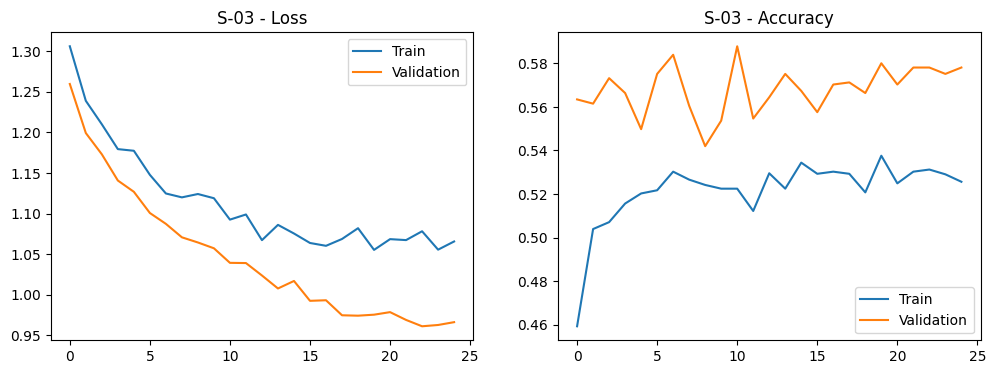


=== CLASSIFICATION REPORT: S-03 ===
              precision    recall  f1-score   support

           0       0.34      0.46      0.39       172
           1       0.29      0.73      0.42        15
           2       0.71      0.62      0.66       634
           3       0.49      0.49      0.49       459

    accuracy                           0.55      1280
   macro avg       0.46      0.58      0.49      1280
weighted avg       0.58      0.55      0.56      1280



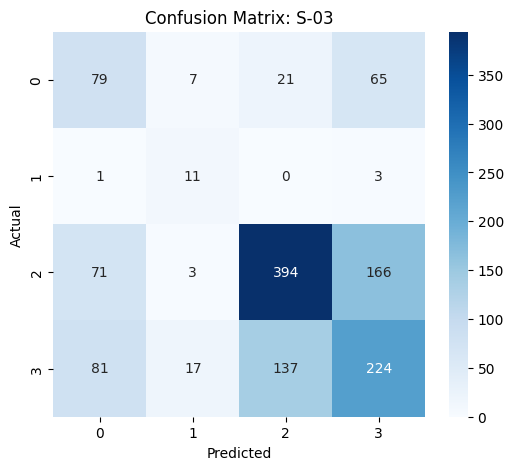


STARTING: S-04 | Opt: AdamW | Sched: CosineAnnealingLR
Epoch 01/25 | LR: 9.96e-05 | Train Loss: 1.3182 Acc: 0.4565 | Val Loss: 1.2649 Acc: 0.5439
Epoch 02/25 | LR: 9.84e-05 | Train Loss: 1.2412 Acc: 0.4990 | Val Loss: 1.2078 Acc: 0.5654
Epoch 03/25 | LR: 9.65e-05 | Train Loss: 1.1893 Acc: 0.5200 | Val Loss: 1.1542 Acc: 0.5850
Epoch 04/25 | LR: 9.38e-05 | Train Loss: 1.1715 Acc: 0.5090 | Val Loss: 1.1361 Acc: 0.5850
Epoch 05/25 | LR: 9.05e-05 | Train Loss: 1.1537 Acc: 0.5298 | Val Loss: 1.1024 Acc: 0.5742
Epoch 06/25 | LR: 8.64e-05 | Train Loss: 1.1385 Acc: 0.5261 | Val Loss: 1.1004 Acc: 0.5762
Epoch 07/25 | LR: 8.19e-05 | Train Loss: 1.1208 Acc: 0.5259 | Val Loss: 1.0808 Acc: 0.5498
Epoch 08/25 | LR: 7.68e-05 | Train Loss: 1.1398 Acc: 0.5356 | Val Loss: 1.0665 Acc: 0.5566
Epoch 09/25 | LR: 7.13e-05 | Train Loss: 1.1303 Acc: 0.5256 | Val Loss: 1.0620 Acc: 0.5605
Epoch 10/25 | LR: 6.55e-05 | Train Loss: 1.1163 Acc: 0.5251 | Val Loss: 1.0540 Acc: 0.5732
Epoch 11/25 | LR: 5.94e-05 | Train

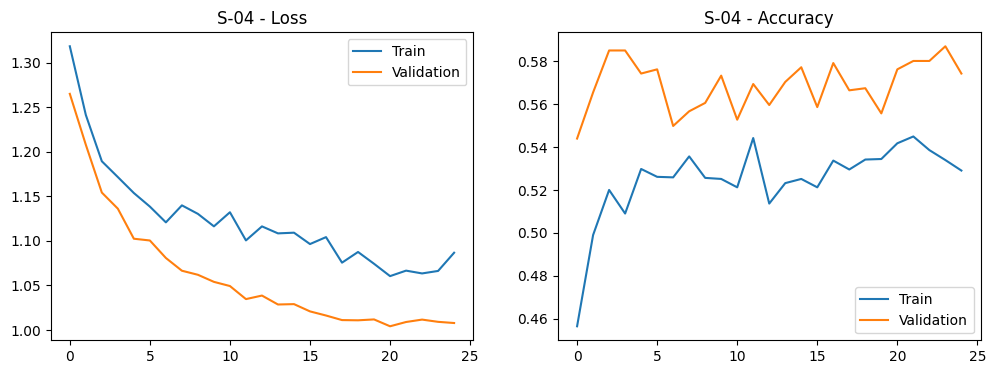


=== CLASSIFICATION REPORT: S-04 ===
              precision    recall  f1-score   support

           0       0.35      0.54      0.42       172
           1       0.29      0.73      0.42        15
           2       0.69      0.69      0.69       634
           3       0.56      0.42      0.48       459

    accuracy                           0.57      1280
   macro avg       0.47      0.59      0.50      1280
weighted avg       0.59      0.57      0.57      1280



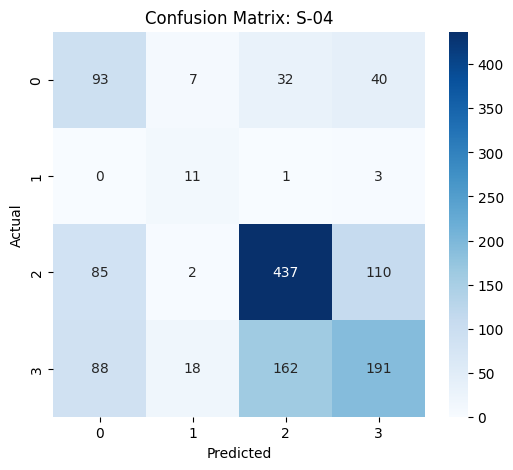


STARTING: S-05 | Opt: SGD | Sched: ReduceLROnPlateau
Epoch 01/25 | LR: 1.00e-04 | Train Loss: 1.3638 Acc: 0.3357 | Val Loss: 1.3555 Acc: 0.4316
Epoch 02/25 | LR: 1.00e-04 | Train Loss: 1.3366 Acc: 0.3806 | Val Loss: 1.3396 Acc: 0.4912
Epoch 03/25 | LR: 1.00e-04 | Train Loss: 1.3356 Acc: 0.4004 | Val Loss: 1.3299 Acc: 0.5127
Epoch 04/25 | LR: 1.00e-04 | Train Loss: 1.3206 Acc: 0.4216 | Val Loss: 1.3241 Acc: 0.5293
Epoch 05/25 | LR: 1.00e-04 | Train Loss: 1.3157 Acc: 0.4326 | Val Loss: 1.3169 Acc: 0.5322
Epoch 06/25 | LR: 1.00e-04 | Train Loss: 1.3199 Acc: 0.4399 | Val Loss: 1.3116 Acc: 0.5508
Epoch 07/25 | LR: 1.00e-04 | Train Loss: 1.2939 Acc: 0.4590 | Val Loss: 1.3051 Acc: 0.5430
Epoch 08/25 | LR: 1.00e-04 | Train Loss: 1.2972 Acc: 0.4570 | Val Loss: 1.3003 Acc: 0.5586
Epoch 09/25 | LR: 1.00e-04 | Train Loss: 1.2923 Acc: 0.4561 | Val Loss: 1.2954 Acc: 0.5586
Epoch 10/25 | LR: 1.00e-04 | Train Loss: 1.2816 Acc: 0.4490 | Val Loss: 1.2899 Acc: 0.5449
Epoch 11/25 | LR: 1.00e-04 | Train L

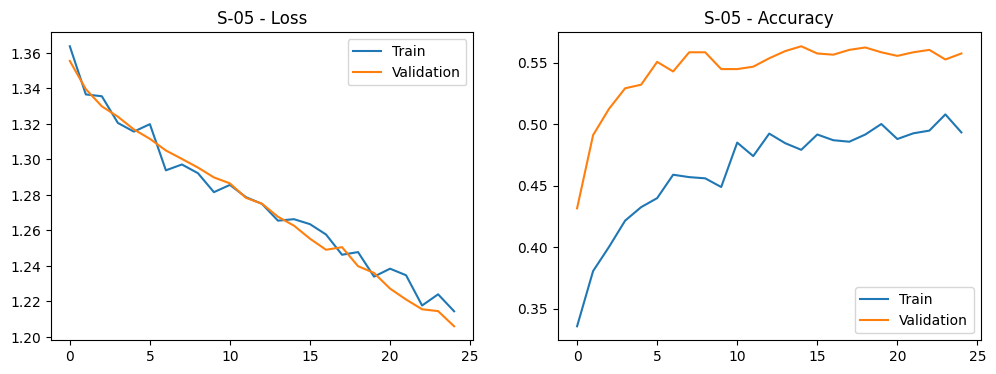


=== CLASSIFICATION REPORT: S-05 ===
              precision    recall  f1-score   support

           0       0.30      0.44      0.36       172
           1       0.00      0.00      0.00        15
           2       0.61      0.78      0.69       634
           3       0.50      0.25      0.33       459

    accuracy                           0.53      1280
   macro avg       0.36      0.37      0.34      1280
weighted avg       0.52      0.53      0.51      1280



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


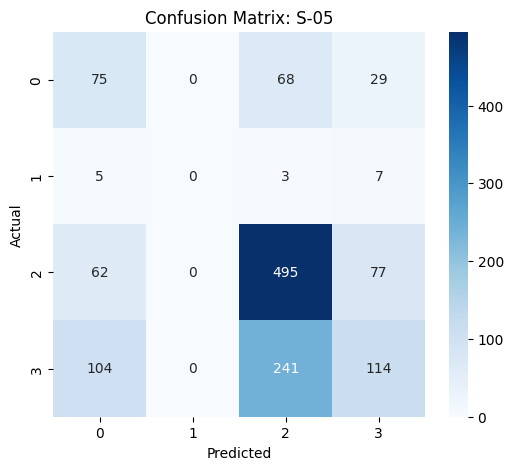


STARTING: S-06 | Opt: SGD | Sched: CosineAnnealingLR
Epoch 01/25 | LR: 9.96e-05 | Train Loss: 1.3593 Acc: 0.3533 | Val Loss: 1.3501 Acc: 0.4609
Epoch 02/25 | LR: 9.84e-05 | Train Loss: 1.3325 Acc: 0.3994 | Val Loss: 1.3354 Acc: 0.4775
Epoch 03/25 | LR: 9.65e-05 | Train Loss: 1.3090 Acc: 0.4153 | Val Loss: 1.3254 Acc: 0.5010
Epoch 04/25 | LR: 9.38e-05 | Train Loss: 1.3029 Acc: 0.4485 | Val Loss: 1.3177 Acc: 0.5029
Epoch 05/25 | LR: 9.05e-05 | Train Loss: 1.3013 Acc: 0.4443 | Val Loss: 1.3140 Acc: 0.5117
Epoch 06/25 | LR: 8.64e-05 | Train Loss: 1.2922 Acc: 0.4702 | Val Loss: 1.3048 Acc: 0.5176
Epoch 07/25 | LR: 8.19e-05 | Train Loss: 1.2916 Acc: 0.4509 | Val Loss: 1.3009 Acc: 0.5166
Epoch 08/25 | LR: 7.68e-05 | Train Loss: 1.3013 Acc: 0.4497 | Val Loss: 1.2964 Acc: 0.5205
Epoch 09/25 | LR: 7.13e-05 | Train Loss: 1.2919 Acc: 0.4626 | Val Loss: 1.2916 Acc: 0.5254
Epoch 10/25 | LR: 6.55e-05 | Train Loss: 1.2901 Acc: 0.4587 | Val Loss: 1.2898 Acc: 0.5225
Epoch 11/25 | LR: 5.94e-05 | Train L

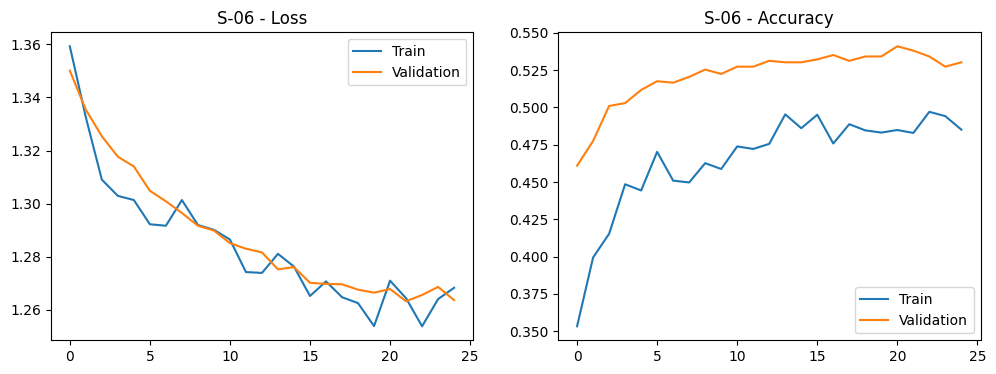


=== CLASSIFICATION REPORT: S-06 ===
              precision    recall  f1-score   support

           0       0.28      0.41      0.33       172
           1       0.00      0.00      0.00        15
           2       0.59      0.80      0.68       634
           3       0.51      0.19      0.28       459

    accuracy                           0.52      1280
   macro avg       0.35      0.35      0.32      1280
weighted avg       0.52      0.52      0.48      1280



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


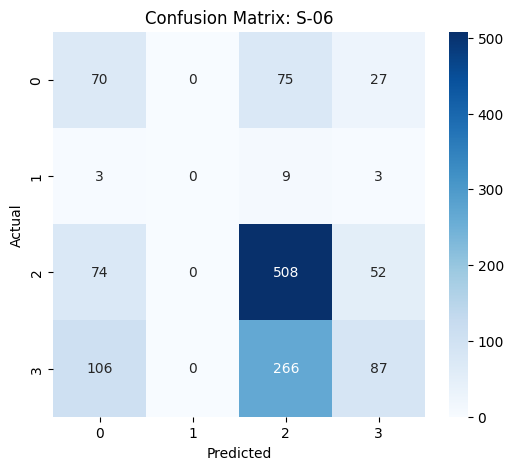

In [ ]:
# ==========================================
# 0. MOUNT GOOGLE DRIVE & SETUP FOLDER
# ==========================================
from google.colab import drive
import os

print("Mounting Google Drive...")
drive.mount('/content/drive')

# Buat folder khusus di Google Drive kamu
SAVE_DIR = '/content/drive/MyDrive/Alzheimer_EfficientNet_Models_Sampler'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Semua model akan disimpan di: {SAVE_DIR}")

# ==========================================
# IMPORT LIBRARIES
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CONFIG & SETUP
# ==========================================
CONFIG = {
    "lr": 1e-4,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("\nLoading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"] # 5120 data
test_data = hf_dataset["test"]      # 1280 data

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")
train_labels = np.array(train_data["label"])

# ==========================================
# 3. CLASS WEIGHTS UNTUK LOSS FUNCTION
# ==========================================
print("\nMenghitung Class Weights...")
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts

# Normalisasi bobot agar tidak terlalu besar/kecil
class_weights = class_weights / class_weights.sum() * len(class_counts)

# Konversi ke Tensor
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"Class Weights Tensor: {class_weights_tensor}")

# ==========================================
# 4. DATASET WRAPPER
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

# ==========================================
# 5. DEFINE TRANSFORMS (AUG & NO AUG)
# ==========================================
base_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

aug_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==========================================
# 6. EXPERIMENT FUNCTION (FREEZE ALL + SAVE DRIVE)
# ==========================================
def run_experiment(experiment_name, train_transform, opt_type, sched_type):
    print(f"\n{'='*60}")
    print(f"STARTING: {experiment_name} | Opt: {opt_type} | Sched: {sched_type}")
    print(f"{'='*60}")

    # --- Setup DataLoaders (Menggunakan Normal Shuffle) ---
    train_ds = AlzheimerDataset(train_data, train_transform)
    val_ds   = AlzheimerDataset(val_data, base_transform)
    test_ds  = AlzheimerDataset(test_data, base_transform)

    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])
    val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
    test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

    # --- Setup Model ---
    model = efficientnet_b2(weights=EfficientNet_B2_Weights.DEFAULT)

    # PERUBAHAN DI SINI: Freeze SEMUA layer backbone
    for param in model.features.parameters():
        param.requires_grad = False

    num_classes = len(np.unique(train_labels))
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(1408, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )
    model = model.to(device)

    # --- Loss & Optimizers ---
    # Class Weight ditambahkan ke Loss Function
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

    # Hanya update layer yang tidak di-freeze
    trainable_params = filter(lambda p: p.requires_grad, model.parameters())
    if opt_type == 'Adam':
        optimizer = optim.Adam(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'AdamW':
        optimizer = optim.AdamW(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'SGD':
        optimizer = optim.SGD(trainable_params, lr=CONFIG["lr"], momentum=0.9)
    else:
        raise ValueError("Optimizer tidak dikenali!")

    # --- Dynamic Scheduler ---
    if sched_type == 'CosineAnnealingLR':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])
    elif sched_type == 'ReduceLROnPlateau':
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
    else:
        raise ValueError("Scheduler tidak dikenali!")

    # --- Training Loop ---
    train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []
    best_model = copy.deepcopy(model.state_dict())
    best_loss = float("inf")
    counter = 0

    for epoch in range(CONFIG["epochs"]):
        # ===== Train =====
        model.train()
        train_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss /= total
        train_acc = correct / total

        if sched_type == 'CosineAnnealingLR':
            scheduler.step()

        # ===== Validation =====
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        if sched_type == 'ReduceLROnPlateau':
            scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:02d}/{CONFIG['epochs']} | LR: {current_lr:.2e} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        # ===== Early Stopping =====
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= CONFIG["patience"]:
                print("-> Early stopping triggered!")
                break

    # --- Load Best Model ---
    print(f"\nLoading best model for {experiment_name} testing...")
    model.load_state_dict(best_model)

    # ---------------------------------------------------------
    # SIMPAN MODEL KE GOOGLE DRIVE
    # ---------------------------------------------------------
    clean_name = experiment_name.replace(" ", "_").replace("-", "")
    model_filename = f"model_{clean_name}_{opt_type}_{sched_type}.pth"
    save_path = os.path.join(SAVE_DIR, model_filename)

    torch.save(model.state_dict(), save_path)
    print(f"Berhasil! Model disimpan di Drive: {save_path}")
    # ---------------------------------------------------------

    # --- Testing ---
    model.eval()
    all_probs, all_labels, all_preds = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())

    # --- Plotting & Metrics ---
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Validation")
    plt.title(f"{experiment_name} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label="Train")
    plt.plot(val_accuracies, label="Validation")
    plt.title(f"{experiment_name} - Accuracy")
    plt.legend()
    plt.show()

    print(f"\n=== CLASSIFICATION REPORT: {experiment_name} ===")
    print(classification_report(all_labels, all_preds))

    # --- Confusion Matrix ---
    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix: {experiment_name}")
    plt.show()

# ==========================================
# 7. RUN PIPELINES (SCENARIOS S-01 to S-06)
# ==========================================
# Menggunakan Augmentasi dan Class Weights Loss untuk semua skenario

scenarios = [
    {"name": "S-01", "opt": "Adam",  "sched": "ReduceLROnPlateau"},
    {"name": "S-02", "opt": "Adam",  "sched": "CosineAnnealingLR"},
    {"name": "S-03", "opt": "AdamW", "sched": "ReduceLROnPlateau"},
    {"name": "S-04", "opt": "AdamW", "sched": "CosineAnnealingLR"},
    {"name": "S-05", "opt": "SGD",   "sched": "ReduceLROnPlateau"},
    {"name": "S-06", "opt": "SGD",   "sched": "CosineAnnealingLR"}
]

for scenario in scenarios:
    run_experiment(
        experiment_name=scenario["name"],
        train_transform=aug_transform,
        opt_type=scenario["opt"],
        sched_type=scenario["sched"]
    )

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Semua model akan disimpan di: /content/drive/MyDrive/Alzheimer_EfficientNet_Models_Sampler
Device: cuda

Loading dataset...
Train: 4096 | Val: 1024 | Test: 1280

Menghitung Class Weights...
Class Weights Tensor: tensor([0.2419, 3.5916, 0.0682, 0.0983], device='cuda:0')

STARTING: S-07 | Opt: Adam | Sched: ReduceLROnPlateau
Epoch 01/25 | LR: 1.00e-04 | Train Loss: 1.1755 Acc: 0.5120 | Val Loss: 0.9706 Acc: 0.5693
Epoch 02/25 | LR: 1.00e-04 | Train Loss: 0.9267 Acc: 0.5583 | Val Loss: 0.7500 Acc: 0.6357
Epoch 03/25 | LR: 1.00e-04 | Train Loss: 0.7899 Acc: 0.6184 | Val Loss: 0.7742 Acc: 0.5996
Epoch 04/25 | LR: 1.00e-04 | Train Loss: 0.7177 Acc: 0.6536 | Val Loss: 0.5798 Acc: 0.7314
Epoch 05/25 | LR: 1.00e-04 | Train Loss: 0.6310 Acc: 0.7012 | Val Loss: 0.4996 Acc: 0.7314
Epoch 06/25 | LR: 1.00e-04 | Train Loss: 0.5187 Acc: 0.7468 | Val 

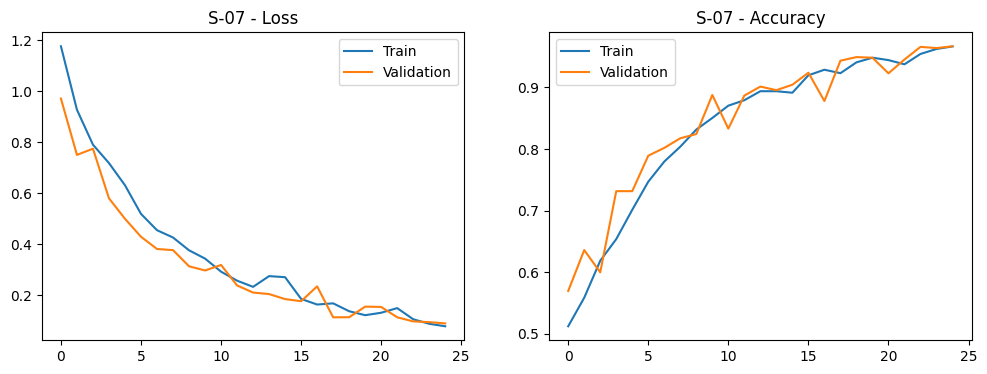


=== CLASSIFICATION REPORT: S-07 ===
              precision    recall  f1-score   support

           0       0.95      0.94      0.94       172
           1       1.00      1.00      1.00        15
           2       0.98      0.96      0.97       634
           3       0.94      0.97      0.95       459

    accuracy                           0.96      1280
   macro avg       0.97      0.97      0.97      1280
weighted avg       0.96      0.96      0.96      1280



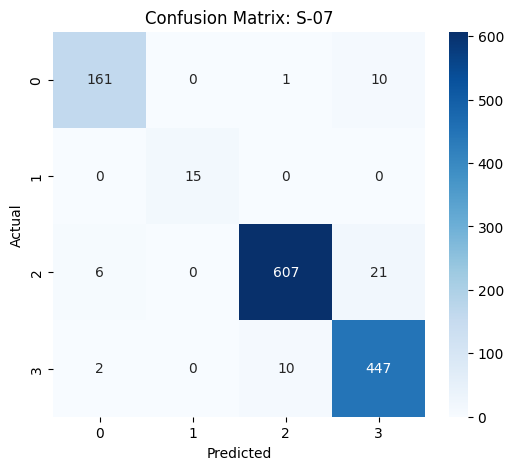


STARTING: S-08 | Opt: Adam | Sched: CosineAnnealingLR
Epoch 01/25 | LR: 9.96e-05 | Train Loss: 1.1788 Acc: 0.5039 | Val Loss: 0.9626 Acc: 0.5752
Epoch 02/25 | LR: 9.84e-05 | Train Loss: 0.9514 Acc: 0.5586 | Val Loss: 0.7749 Acc: 0.6211
Epoch 03/25 | LR: 9.65e-05 | Train Loss: 0.7890 Acc: 0.6194 | Val Loss: 0.6750 Acc: 0.6436
Epoch 04/25 | LR: 9.38e-05 | Train Loss: 0.6987 Acc: 0.6616 | Val Loss: 0.6224 Acc: 0.6709
Epoch 05/25 | LR: 9.05e-05 | Train Loss: 0.6197 Acc: 0.6985 | Val Loss: 0.5866 Acc: 0.6895
Epoch 06/25 | LR: 8.64e-05 | Train Loss: 0.5623 Acc: 0.7380 | Val Loss: 0.4361 Acc: 0.7744
Epoch 07/25 | LR: 8.19e-05 | Train Loss: 0.4730 Acc: 0.7793 | Val Loss: 0.4716 Acc: 0.7842
Epoch 08/25 | LR: 7.68e-05 | Train Loss: 0.4267 Acc: 0.8035 | Val Loss: 0.3571 Acc: 0.8027
Epoch 09/25 | LR: 7.13e-05 | Train Loss: 0.3726 Acc: 0.8191 | Val Loss: 0.3069 Acc: 0.8340
Epoch 10/25 | LR: 6.55e-05 | Train Loss: 0.3145 Acc: 0.8464 | Val Loss: 0.2488 Acc: 0.8789
Epoch 11/25 | LR: 5.94e-05 | Train 

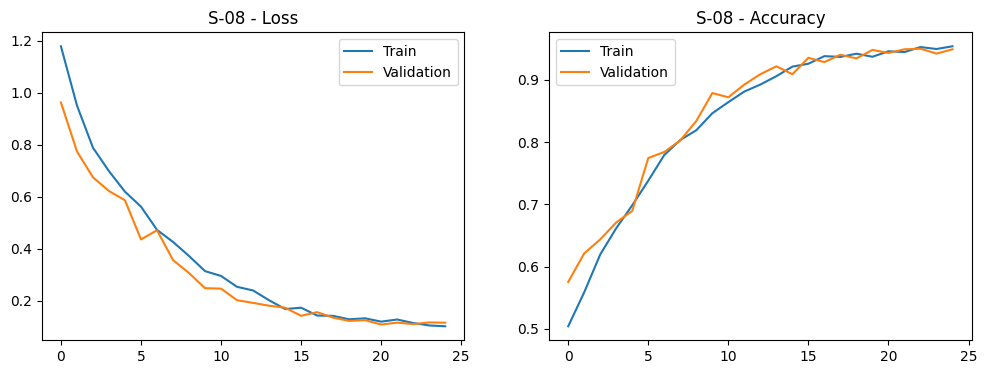


=== CLASSIFICATION REPORT: S-08 ===
              precision    recall  f1-score   support

           0       0.88      0.97      0.93       172
           1       1.00      1.00      1.00        15
           2       0.97      0.92      0.95       634
           3       0.91      0.95      0.93       459

    accuracy                           0.94      1280
   macro avg       0.94      0.96      0.95      1280
weighted avg       0.94      0.94      0.94      1280



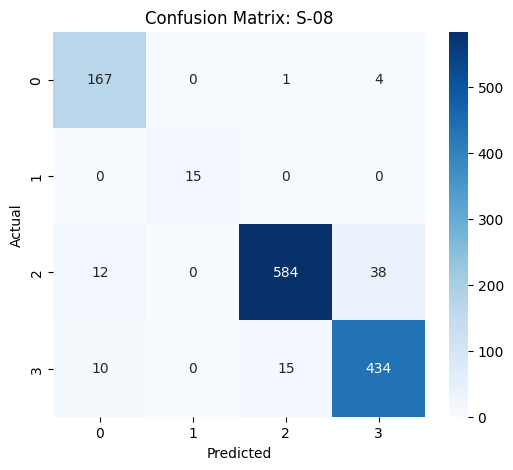


STARTING: S-09 | Opt: AdamW | Sched: ReduceLROnPlateau
Epoch 01/25 | LR: 1.00e-04 | Train Loss: 1.1646 Acc: 0.5002 | Val Loss: 0.9505 Acc: 0.5508
Epoch 02/25 | LR: 1.00e-04 | Train Loss: 0.9337 Acc: 0.5471 | Val Loss: 0.8104 Acc: 0.6201
Epoch 03/25 | LR: 1.00e-04 | Train Loss: 0.8013 Acc: 0.6150 | Val Loss: 0.7008 Acc: 0.6006
Epoch 04/25 | LR: 1.00e-04 | Train Loss: 0.6842 Acc: 0.6589 | Val Loss: 0.6064 Acc: 0.7168
Epoch 05/25 | LR: 1.00e-04 | Train Loss: 0.6064 Acc: 0.7080 | Val Loss: 0.4838 Acc: 0.7646
Epoch 06/25 | LR: 1.00e-04 | Train Loss: 0.5224 Acc: 0.7517 | Val Loss: 0.4817 Acc: 0.7656
Epoch 07/25 | LR: 1.00e-04 | Train Loss: 0.4693 Acc: 0.7834 | Val Loss: 0.4140 Acc: 0.7852
Epoch 08/25 | LR: 1.00e-04 | Train Loss: 0.3975 Acc: 0.8079 | Val Loss: 0.3584 Acc: 0.8174
Epoch 09/25 | LR: 1.00e-04 | Train Loss: 0.3647 Acc: 0.8391 | Val Loss: 0.3042 Acc: 0.8496
Epoch 10/25 | LR: 1.00e-04 | Train Loss: 0.3189 Acc: 0.8540 | Val Loss: 0.2745 Acc: 0.8643
Epoch 11/25 | LR: 1.00e-04 | Train

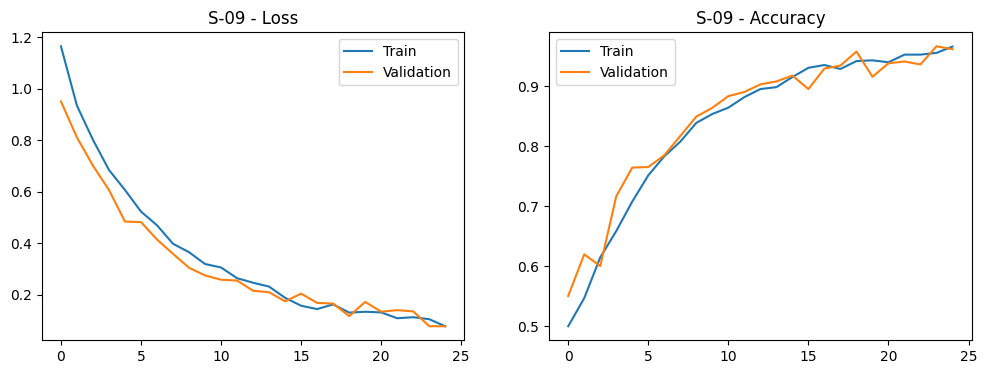


=== CLASSIFICATION REPORT: S-09 ===
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       172
           1       1.00      1.00      1.00        15
           2       0.99      0.93      0.96       634
           3       0.92      0.99      0.95       459

    accuracy                           0.96      1280
   macro avg       0.97      0.98      0.97      1280
weighted avg       0.96      0.96      0.96      1280



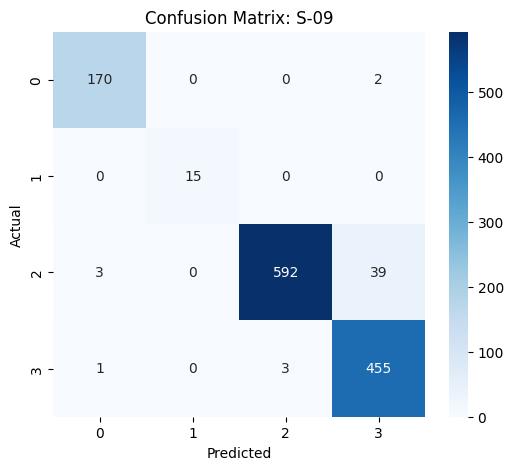


STARTING: S-10 | Opt: AdamW | Sched: CosineAnnealingLR
Epoch 01/25 | LR: 9.96e-05 | Train Loss: 1.2045 Acc: 0.5017 | Val Loss: 0.9702 Acc: 0.5801
Epoch 02/25 | LR: 9.84e-05 | Train Loss: 0.9520 Acc: 0.5552 | Val Loss: 0.7550 Acc: 0.6533
Epoch 03/25 | LR: 9.65e-05 | Train Loss: 0.7976 Acc: 0.6094 | Val Loss: 0.6527 Acc: 0.6846
Epoch 04/25 | LR: 9.38e-05 | Train Loss: 0.6688 Acc: 0.6721 | Val Loss: 0.5416 Acc: 0.7295
Epoch 05/25 | LR: 9.05e-05 | Train Loss: 0.5941 Acc: 0.7148 | Val Loss: 0.4985 Acc: 0.7354
Epoch 06/25 | LR: 8.64e-05 | Train Loss: 0.5125 Acc: 0.7585 | Val Loss: 0.4452 Acc: 0.7930
Epoch 07/25 | LR: 8.19e-05 | Train Loss: 0.4734 Acc: 0.7781 | Val Loss: 0.6692 Acc: 0.7646
Epoch 08/25 | LR: 7.68e-05 | Train Loss: 0.4041 Acc: 0.8064 | Val Loss: 0.3289 Acc: 0.8594
Epoch 09/25 | LR: 7.13e-05 | Train Loss: 0.3324 Acc: 0.8428 | Val Loss: 0.2533 Acc: 0.8623
Epoch 10/25 | LR: 6.55e-05 | Train Loss: 0.3021 Acc: 0.8613 | Val Loss: 0.2446 Acc: 0.8789
Epoch 11/25 | LR: 5.94e-05 | Train

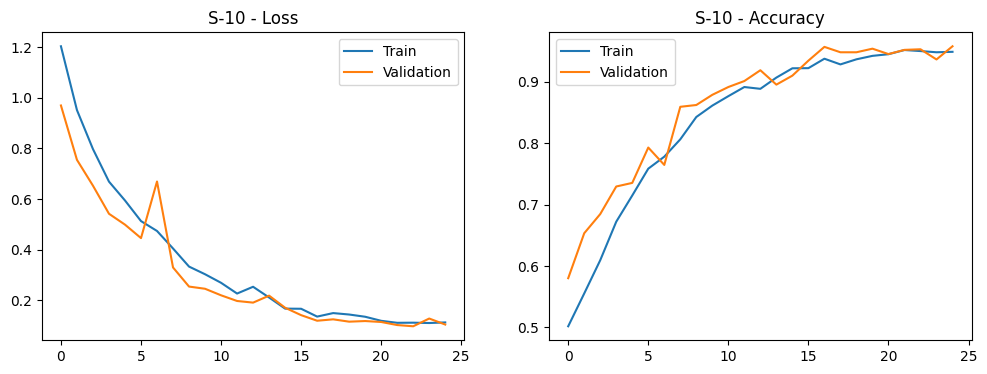


=== CLASSIFICATION REPORT: S-10 ===
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       172
           1       1.00      1.00      1.00        15
           2       0.98      0.94      0.96       634
           3       0.94      0.96      0.95       459

    accuracy                           0.95      1280
   macro avg       0.96      0.97      0.96      1280
weighted avg       0.96      0.95      0.95      1280



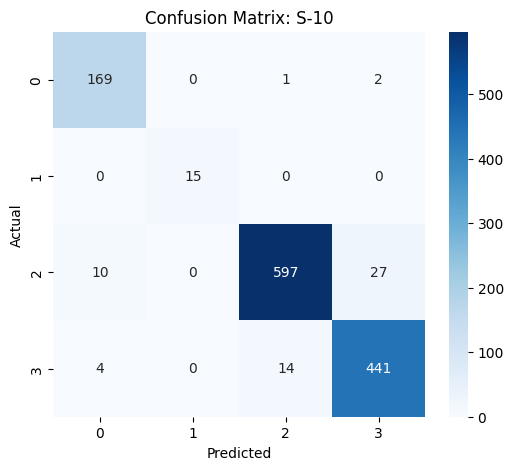

In [ ]:
# ==========================================
# 0. MOUNT GOOGLE DRIVE & SETUP FOLDER
# ==========================================
from google.colab import drive
import os

print("Mounting Google Drive...")
drive.mount('/content/drive')

# Buat folder khusus di Google Drive kamu
SAVE_DIR = '/content/drive/MyDrive/Alzheimer_EfficientNet_Models_Sampler'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Semua model akan disimpan di: {SAVE_DIR}")

# ==========================================
# IMPORT LIBRARIES
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CONFIG & SETUP
# ==========================================
CONFIG = {
    "lr": 1e-4,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("\nLoading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"] # 5120 data
test_data = hf_dataset["test"]      # 1280 data

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

train_labels = np.array(train_data["label"])

# ==========================================
# 3. CLASS WEIGHTS UNTUK LOSS FUNCTION
# ==========================================
print("\nMenghitung Class Weights...")
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts

# Normalisasi bobot agar tidak terlalu besar/kecil (best practice)
class_weights = class_weights / class_weights.sum() * len(class_counts)

# Konversi ke Tensor dan pindahkan ke device
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"Class Weights Tensor: {class_weights_tensor}")

# ==========================================
# 4. DATASET WRAPPER
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

# ==========================================
# 5. DEFINE TRANSFORMS (AUG & NO AUG)
# ==========================================
base_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

aug_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==========================================
# 6. EXPERIMENT FUNCTION (UNFREEZE LAST 4 LAYERS + SAVE TO DRIVE)
# ==========================================
def run_experiment(experiment_name, train_transform, opt_type, sched_type):
    print(f"\n{'='*60}")
    print(f"STARTING: {experiment_name} | Opt: {opt_type} | Sched: {sched_type}")
    print(f"{'='*60}")

    # --- Setup DataLoaders (Normal Shuffle, NO WeightedRandomSampler) ---
    train_ds = AlzheimerDataset(train_data, train_transform)
    val_ds   = AlzheimerDataset(val_data, base_transform)
    test_ds  = AlzheimerDataset(test_data, base_transform)

    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])
    val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
    test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

    # --- Setup Model ---
    model = efficientnet_b2(weights=EfficientNet_B2_Weights.DEFAULT)

    # 1. Freeze semua layer terlebih dahulu
    for param in model.features.parameters():
        param.requires_grad = False

    # 2. PERUBAHAN DI SINI: Unfreeze 4 layer terakhir di block features
    for param in model.features[-4:].parameters():
        param.requires_grad = True

    num_classes = len(np.unique(train_labels))
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(1408, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )
    model = model.to(device)

    # --- Loss & Optimizers ---
    # CLASS WEIGHT PADA LOSS FUNCTION
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

    # trainable_params otomatis mengambil classifier DAN 4 layer terakhir yang di-unfreeze
    trainable_params = filter(lambda p: p.requires_grad, model.parameters())

    if opt_type == 'Adam':
        optimizer = optim.Adam(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'AdamW':
        optimizer = optim.AdamW(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'SGD':
        optimizer = optim.SGD(trainable_params, lr=CONFIG["lr"], momentum=0.9)
    else:
        raise ValueError("Optimizer tidak dikenali!")

    # --- Dynamic Scheduler ---
    if sched_type == 'CosineAnnealingLR':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])
    elif sched_type == 'ReduceLROnPlateau':
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
    else:
        raise ValueError("Scheduler tidak dikenali!")

    # --- Training Loop ---
    train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []
    best_model = copy.deepcopy(model.state_dict())
    best_loss = float("inf")
    counter = 0

    for epoch in range(CONFIG["epochs"]):
        # ===== Train =====
        model.train()
        train_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss /= total
        train_acc = correct / total

        # Step Scheduler (CosineAnnealingLR)
        if sched_type == 'CosineAnnealingLR':
            scheduler.step()

        # ===== Validation =====
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        # Step Scheduler (ReduceLROnPlateau)
        if sched_type == 'ReduceLROnPlateau':
            scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:02d}/{CONFIG['epochs']} | LR: {current_lr:.2e} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        # ===== Early Stopping =====
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= CONFIG["patience"]:
                print("-> Early stopping triggered!")
                break

    # --- Load Best Model ---
    print(f"\nLoading best model for {experiment_name} testing...")
    model.load_state_dict(best_model)

    # ---------------------------------------------------------
    # SIMPAN MODEL KE GOOGLE DRIVE
    # ---------------------------------------------------------
    clean_name = experiment_name.replace(" ", "_").replace("-", "")
    model_filename = f"model_{clean_name}_{opt_type}_{sched_type}.pth"
    save_path = os.path.join(SAVE_DIR, model_filename)

    torch.save(model.state_dict(), save_path)
    print(f"Berhasil! Model disimpan di Drive: {save_path}")
    # ---------------------------------------------------------

    # --- Testing ---
    model.eval()
    all_probs, all_labels, all_preds = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())

    # --- Plotting & Metrics ---
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Validation")
    plt.title(f"{experiment_name} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label="Train")
    plt.plot(val_accuracies, label="Validation")
    plt.title(f"{experiment_name} - Accuracy")
    plt.legend()
    plt.show()

    print(f"\n=== CLASSIFICATION REPORT: {experiment_name} ===")
    print(classification_report(all_labels, all_preds))

    # --- Visualisasi Confusion Matrix ---
    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix: {experiment_name}")
    plt.show()

# ==========================================
# 7. RUN PIPELINES (SCENARIOS S-07 to S-12)
# ==========================================
scenarios_unfreeze = [
    {"name": "S-07", "opt": "Adam",  "sched": "ReduceLROnPlateau"},
    {"name": "S-08", "opt": "Adam",  "sched": "CosineAnnealingLR"},
    {"name": "S-09", "opt": "AdamW", "sched": "ReduceLROnPlateau"},
    {"name": "S-10", "opt": "AdamW", "sched": "CosineAnnealingLR"},
    # {"name": "S-11", "opt": "SGD",   "sched": "ReduceLROnPlateau"},
    # {"name": "S-12", "opt": "SGD",   "sched": "CosineAnnealingLR"}
]

# Eksekusi loop untuk skenario Unfreeze Layer Terakhir
for scenario in scenarios_unfreeze:
    run_experiment(
        experiment_name=scenario["name"],
        train_transform=aug_transform, # Menggunakan data augmentasi
        opt_type=scenario["opt"],
        sched_type=scenario["sched"]
    )

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Semua model akan disimpan di: /content/drive/MyDrive/Alzheimer_EfficientNet_Models
Device: cuda

Loading dataset...
Train: 4096 | Val: 1024 | Test: 1280

Menghitung Class Weights...
Class Weights Tensor: tensor([0.2419, 3.5916, 0.0682, 0.0983], device='cuda:0')

STARTING: S-11 | Opt: SGD | Sched: ReduceLROnPlateau
Epoch 01/25 | LR: 1.00e-04 | Train Loss: 1.3719 Acc: 0.3394 | Val Loss: 1.3594 Acc: 0.4697
Epoch 02/25 | LR: 1.00e-04 | Train Loss: 1.3362 Acc: 0.4133 | Val Loss: 1.3403 Acc: 0.4795
Epoch 03/25 | LR: 1.00e-04 | Train Loss: 1.3262 Acc: 0.4197 | Val Loss: 1.3263 Acc: 0.5020
Epoch 04/25 | LR: 1.00e-04 | Train Loss: 1.3049 Acc: 0.4656 | Val Loss: 1.3158 Acc: 0.5303
Epoch 05/25 | LR: 1.00e-04 | Train Loss: 1.3080 Acc: 0.4543 | Val Loss: 1.3051 Acc: 0.5303
Epoch 06/25 | LR: 1.00e-04 | Train Loss: 1.2975 Acc: 0.4714 | Val Loss: 1.2

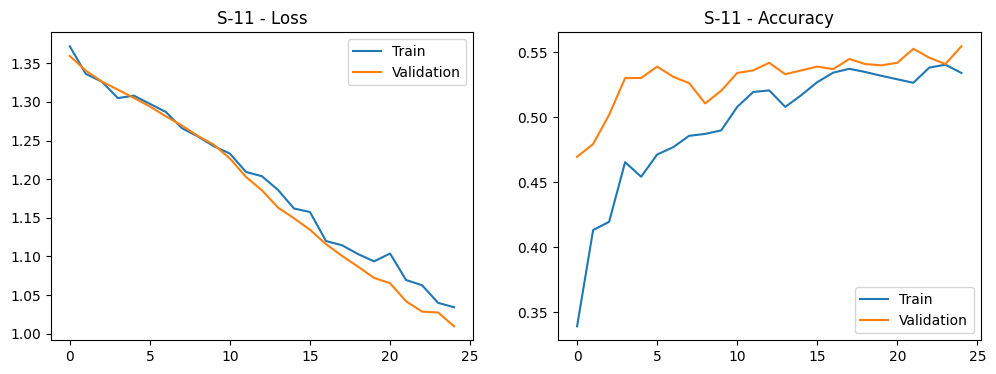


=== CLASSIFICATION REPORT: S-11 ===
              precision    recall  f1-score   support

           0       0.30      0.65      0.41       172
           1       0.00      0.00      0.00        15
           2       0.68      0.69      0.68       634
           3       0.48      0.28      0.35       459

    accuracy                           0.53      1280
   macro avg       0.36      0.40      0.36      1280
weighted avg       0.55      0.53      0.52      1280



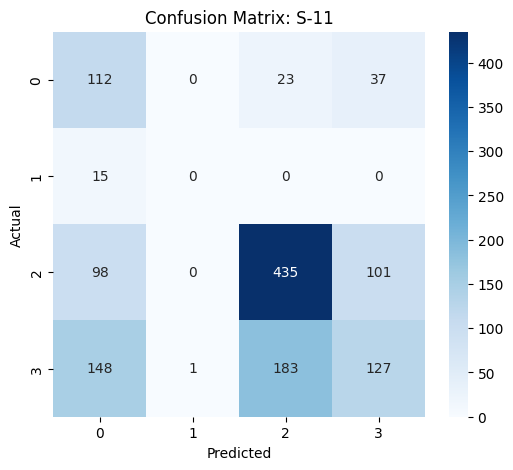


STARTING: S-12 | Opt: SGD | Sched: CosineAnnealingLR
Epoch 01/25 | LR: 9.96e-05 | Train Loss: 1.3729 Acc: 0.3853 | Val Loss: 1.3608 Acc: 0.4902
Epoch 02/25 | LR: 9.84e-05 | Train Loss: 1.3324 Acc: 0.4282 | Val Loss: 1.3395 Acc: 0.5039
Epoch 03/25 | LR: 9.65e-05 | Train Loss: 1.3234 Acc: 0.4307 | Val Loss: 1.3286 Acc: 0.5127
Epoch 04/25 | LR: 9.38e-05 | Train Loss: 1.3168 Acc: 0.4214 | Val Loss: 1.3194 Acc: 0.5176
Epoch 05/25 | LR: 9.05e-05 | Train Loss: 1.3060 Acc: 0.4470 | Val Loss: 1.3052 Acc: 0.5225
Epoch 06/25 | LR: 8.64e-05 | Train Loss: 1.2892 Acc: 0.4595 | Val Loss: 1.2965 Acc: 0.5332
Epoch 07/25 | LR: 8.19e-05 | Train Loss: 1.2836 Acc: 0.4863 | Val Loss: 1.2879 Acc: 0.5322
Epoch 08/25 | LR: 7.68e-05 | Train Loss: 1.2726 Acc: 0.4951 | Val Loss: 1.2756 Acc: 0.5361
Epoch 09/25 | LR: 7.13e-05 | Train Loss: 1.2563 Acc: 0.4910 | Val Loss: 1.2648 Acc: 0.5576
Epoch 10/25 | LR: 6.55e-05 | Train Loss: 1.2556 Acc: 0.4971 | Val Loss: 1.2567 Acc: 0.5596
Epoch 11/25 | LR: 5.94e-05 | Train L

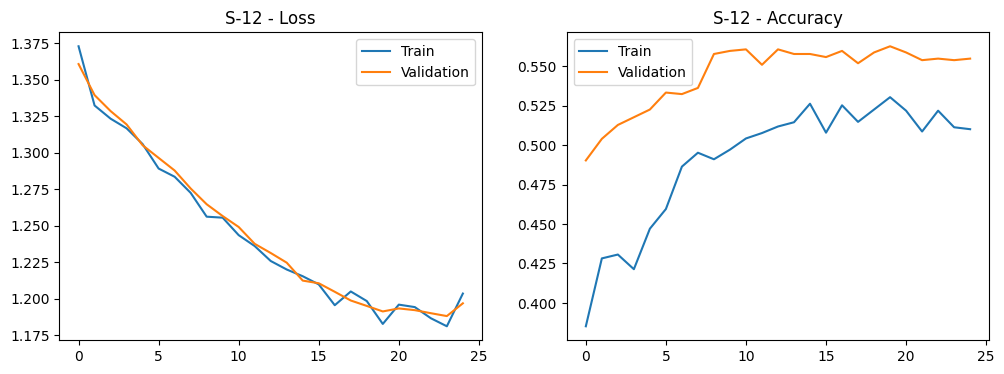


=== CLASSIFICATION REPORT: S-12 ===
              precision    recall  f1-score   support

           0       0.30      0.53      0.38       172
           1       0.00      0.00      0.00        15
           2       0.65      0.71      0.68       634
           3       0.46      0.27      0.34       459

    accuracy                           0.52      1280
   macro avg       0.35      0.38      0.35      1280
weighted avg       0.53      0.52      0.51      1280



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


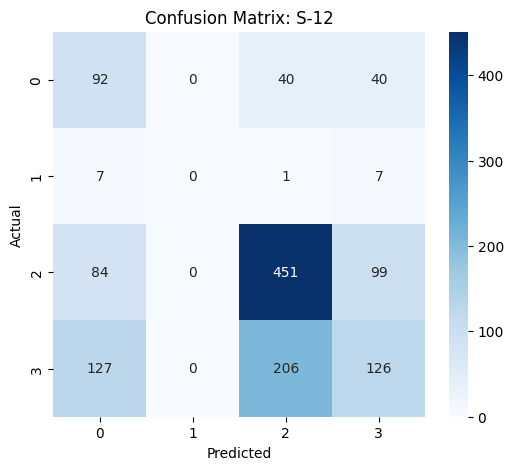

In [ ]:
# ==========================================
# 0. MOUNT GOOGLE DRIVE & SETUP FOLDER
# ==========================================
from google.colab import drive
import os

print("Mounting Google Drive...")
drive.mount('/content/drive')

# Buat folder khusus di Google Drive kamu
SAVE_DIR = '/content/drive/MyDrive/Alzheimer_EfficientNet_Models_Sampler'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Semua model akan disimpan di: {SAVE_DIR}")

# ==========================================
# IMPORT LIBRARIES
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CONFIG & SETUP
# ==========================================
CONFIG = {
    "lr": 1e-4,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("\nLoading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"] # 5120 data
test_data = hf_dataset["test"]      # 1280 data

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

train_labels = np.array(train_data["label"])

# ==========================================
# 3. CLASS WEIGHTS UNTUK LOSS FUNCTION
# ==========================================
print("\nMenghitung Class Weights...")
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts

# Normalisasi bobot agar tidak terlalu besar/kecil (best practice)
class_weights = class_weights / class_weights.sum() * len(class_counts)

# Konversi ke Tensor dan pindahkan ke device
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"Class Weights Tensor: {class_weights_tensor}")

# ==========================================
# 4. DATASET WRAPPER
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

# ==========================================
# 5. DEFINE TRANSFORMS (AUG & NO AUG)
# ==========================================
base_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

aug_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==========================================
# 6. EXPERIMENT FUNCTION (UNFREEZE LAST 4 LAYERS + SAVE TO DRIVE)
# ==========================================
def run_experiment(experiment_name, train_transform, opt_type, sched_type):
    print(f"\n{'='*60}")
    print(f"STARTING: {experiment_name} | Opt: {opt_type} | Sched: {sched_type}")
    print(f"{'='*60}")

    # --- Setup DataLoaders (Normal Shuffle, NO WeightedRandomSampler) ---
    train_ds = AlzheimerDataset(train_data, train_transform)
    val_ds   = AlzheimerDataset(val_data, base_transform)
    test_ds  = AlzheimerDataset(test_data, base_transform)

    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])
    val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
    test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

    # --- Setup Model ---
    model = efficientnet_b2(weights=EfficientNet_B2_Weights.DEFAULT)

    # 1. Freeze semua layer terlebih dahulu
    for param in model.features.parameters():
        param.requires_grad = False

    # 2. PERUBAHAN DI SINI: Unfreeze 4 layer terakhir di block features
    for param in model.features[-4:].parameters():
        param.requires_grad = True

    num_classes = len(np.unique(train_labels))
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(1408, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )
    model = model.to(device)

    # --- Loss & Optimizers ---
    # CLASS WEIGHT PADA LOSS FUNCTION
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

    # trainable_params otomatis mengambil classifier DAN 4 layer terakhir yang di-unfreeze
    trainable_params = filter(lambda p: p.requires_grad, model.parameters())

    if opt_type == 'Adam':
        optimizer = optim.Adam(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'AdamW':
        optimizer = optim.AdamW(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'SGD':
        optimizer = optim.SGD(trainable_params, lr=CONFIG["lr"], momentum=0.9)
    else:
        raise ValueError("Optimizer tidak dikenali!")

    # --- Dynamic Scheduler ---
    if sched_type == 'CosineAnnealingLR':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])
    elif sched_type == 'ReduceLROnPlateau':
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
    else:
        raise ValueError("Scheduler tidak dikenali!")

    # --- Training Loop ---
    train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []
    best_model = copy.deepcopy(model.state_dict())
    best_loss = float("inf")
    counter = 0

    for epoch in range(CONFIG["epochs"]):
        # ===== Train =====
        model.train()
        train_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss /= total
        train_acc = correct / total

        # Step Scheduler (CosineAnnealingLR)
        if sched_type == 'CosineAnnealingLR':
            scheduler.step()

        # ===== Validation =====
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        # Step Scheduler (ReduceLROnPlateau)
        if sched_type == 'ReduceLROnPlateau':
            scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:02d}/{CONFIG['epochs']} | LR: {current_lr:.2e} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        # ===== Early Stopping =====
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= CONFIG["patience"]:
                print("-> Early stopping triggered!")
                break

    # --- Load Best Model ---
    print(f"\nLoading best model for {experiment_name} testing...")
    model.load_state_dict(best_model)

    # ---------------------------------------------------------
    # SIMPAN MODEL KE GOOGLE DRIVE
    # ---------------------------------------------------------
    clean_name = experiment_name.replace(" ", "_").replace("-", "")
    model_filename = f"model_{clean_name}_{opt_type}_{sched_type}.pth"
    save_path = os.path.join(SAVE_DIR, model_filename)

    torch.save(model.state_dict(), save_path)
    print(f"Berhasil! Model disimpan di Drive: {save_path}")
    # ---------------------------------------------------------

    # --- Testing ---
    model.eval()
    all_probs, all_labels, all_preds = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())

    # --- Plotting & Metrics ---
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Validation")
    plt.title(f"{experiment_name} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label="Train")
    plt.plot(val_accuracies, label="Validation")
    plt.title(f"{experiment_name} - Accuracy")
    plt.legend()
    plt.show()

    print(f"\n=== CLASSIFICATION REPORT: {experiment_name} ===")
    print(classification_report(all_labels, all_preds))

    # --- Visualisasi Confusion Matrix ---
    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix: {experiment_name}")
    plt.show()

# ==========================================
# 7. RUN PIPELINES (SCENARIOS S-07 to S-12)
# ==========================================
scenarios_unfreeze = [
    # {"name": "S-07", "opt": "Adam",  "sched": "ReduceLROnPlateau"},
    # {"name": "S-08", "opt": "Adam",  "sched": "CosineAnnealingLR"},
    # {"name": "S-09", "opt": "AdamW", "sched": "ReduceLROnPlateau"},
    # {"name": "S-10", "opt": "AdamW", "sched": "CosineAnnealingLR"},
    {"name": "S-11", "opt": "SGD",   "sched": "ReduceLROnPlateau"},
    {"name": "S-12", "opt": "SGD",   "sched": "CosineAnnealingLR"}
]

# Eksekusi loop untuk skenario Unfreeze Layer Terakhir
for scenario in scenarios_unfreeze:
    run_experiment(
        experiment_name=scenario["name"],
        train_transform=aug_transform, # Menggunakan data augmentasi
        opt_type=scenario["opt"],
        sched_type=scenario["sched"]
    )

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Semua model akan disimpan di: /content/drive/MyDrive/Alzheimer_EfficientNet_Models
Device: cuda

Loading dataset...
Train: 4096 | Val: 1024 | Test: 1280

Menghitung Class Weights...
Class Weights Tensor: tensor([0.2419, 3.5916, 0.0682, 0.0983], device='cuda:0')

STARTING: S-13 | Opt: Adam | Sched: ReduceLROnPlateau
Epoch 01/25 | LR: 1.00e-04 | Train Loss: 1.2010 Acc: 0.4744 | Val Loss: 0.9851 Acc: 0.5596
Epoch 02/25 | LR: 1.00e-04 | Train Loss: 0.9282 Acc: 0.5681 | Val Loss: 0.7706 Acc: 0.6299
Epoch 03/25 | LR: 1.00e-04 | Train Loss: 0.7669 Acc: 0.6294 | Val Loss: 0.6191 Acc: 0.6855
Epoch 04/25 | LR: 1.00e-04 | Train Loss: 0.6464 Acc: 0.6909 | Val Loss: 0.5370 Acc: 0.7314
Epoch 05/25 | LR: 1.00e-04 | Train Loss: 0.5452 Acc: 0.7395 | Val Loss: 0.4732 Acc: 0.7432
Epoch 06/25 | LR: 1.00e-04 | Train Loss: 0.4408 Acc: 0.7905 | Val Loss: 0.

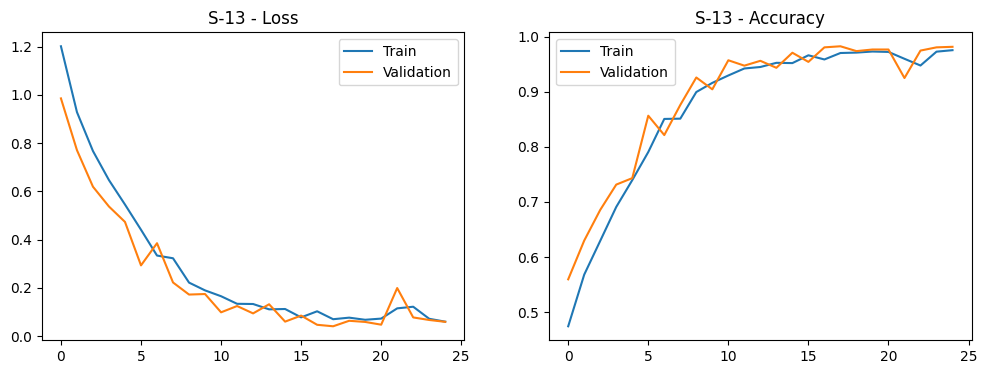


=== CLASSIFICATION REPORT: S-13 ===
              precision    recall  f1-score   support

           0       0.97      0.96      0.96       172
           1       1.00      1.00      1.00        15
           2       0.99      0.98      0.98       634
           3       0.97      0.98      0.98       459

    accuracy                           0.98      1280
   macro avg       0.98      0.98      0.98      1280
weighted avg       0.98      0.98      0.98      1280



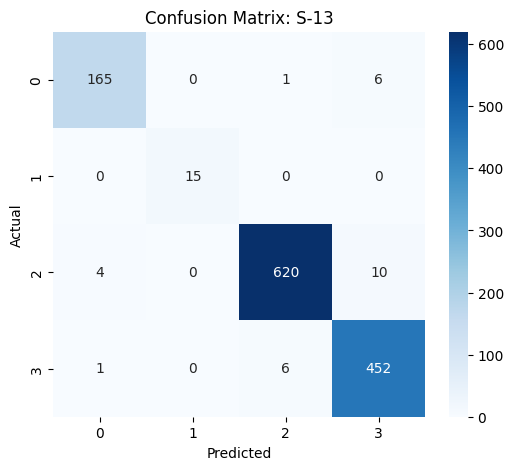


STARTING: S-14 | Opt: Adam | Sched: CosineAnnealingLR
Epoch 01/25 | LR: 9.96e-05 | Train Loss: 1.1810 Acc: 0.5051 | Val Loss: 1.0988 Acc: 0.5010
Epoch 02/25 | LR: 9.84e-05 | Train Loss: 0.9159 Acc: 0.5674 | Val Loss: 0.7762 Acc: 0.6113
Epoch 03/25 | LR: 9.65e-05 | Train Loss: 0.7866 Acc: 0.6250 | Val Loss: 0.7230 Acc: 0.6826
Epoch 04/25 | LR: 9.38e-05 | Train Loss: 0.6285 Acc: 0.7083 | Val Loss: 0.4937 Acc: 0.7500
Epoch 05/25 | LR: 9.05e-05 | Train Loss: 0.4971 Acc: 0.7747 | Val Loss: 0.3701 Acc: 0.8252
Epoch 06/25 | LR: 8.64e-05 | Train Loss: 0.3874 Acc: 0.8147 | Val Loss: 0.2780 Acc: 0.8623
Epoch 07/25 | LR: 8.19e-05 | Train Loss: 0.3442 Acc: 0.8459 | Val Loss: 0.2322 Acc: 0.8662
Epoch 08/25 | LR: 7.68e-05 | Train Loss: 0.2664 Acc: 0.8848 | Val Loss: 0.1933 Acc: 0.9189
Epoch 09/25 | LR: 7.13e-05 | Train Loss: 0.2049 Acc: 0.9070 | Val Loss: 0.2618 Acc: 0.8643
Epoch 10/25 | LR: 6.55e-05 | Train Loss: 0.1799 Acc: 0.9207 | Val Loss: 0.1670 Acc: 0.9141
Epoch 11/25 | LR: 5.94e-05 | Train 

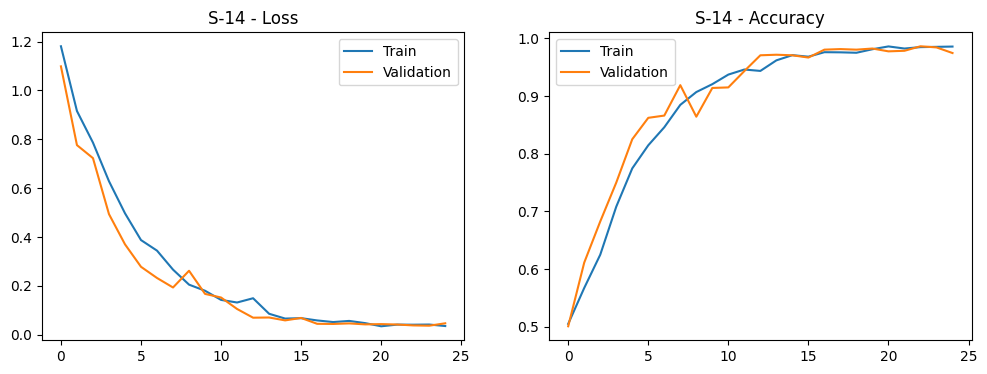


=== CLASSIFICATION REPORT: S-14 ===
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       172
           1       1.00      1.00      1.00        15
           2       0.99      0.99      0.99       634
           3       0.97      0.99      0.98       459

    accuracy                           0.98      1280
   macro avg       0.99      0.99      0.99      1280
weighted avg       0.98      0.98      0.98      1280



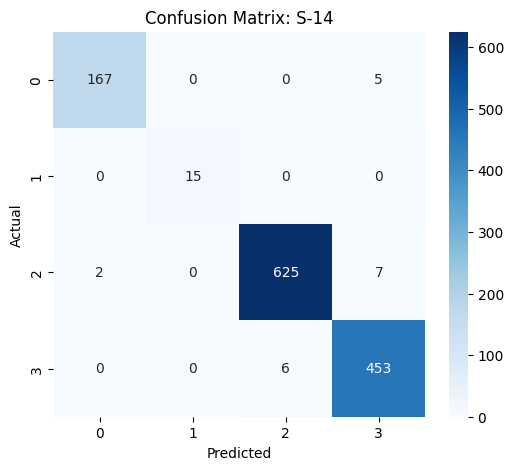


STARTING: S-15 | Opt: AdamW | Sched: ReduceLROnPlateau
Epoch 01/25 | LR: 1.00e-04 | Train Loss: 1.2111 Acc: 0.4717 | Val Loss: 0.9587 Acc: 0.5850
Epoch 02/25 | LR: 1.00e-04 | Train Loss: 0.9726 Acc: 0.5481 | Val Loss: 0.8280 Acc: 0.5713
Epoch 03/25 | LR: 1.00e-04 | Train Loss: 0.7663 Acc: 0.6223 | Val Loss: 0.7756 Acc: 0.6104
Epoch 04/25 | LR: 1.00e-04 | Train Loss: 0.6548 Acc: 0.6936 | Val Loss: 0.5416 Acc: 0.7197
Epoch 05/25 | LR: 1.00e-04 | Train Loss: 0.5303 Acc: 0.7471 | Val Loss: 0.4068 Acc: 0.7979
Epoch 06/25 | LR: 1.00e-04 | Train Loss: 0.4200 Acc: 0.8059 | Val Loss: 0.3060 Acc: 0.8623
Epoch 07/25 | LR: 1.00e-04 | Train Loss: 0.3674 Acc: 0.8350 | Val Loss: 0.2617 Acc: 0.8789
Epoch 08/25 | LR: 1.00e-04 | Train Loss: 0.2893 Acc: 0.8669 | Val Loss: 0.2004 Acc: 0.9082
Epoch 09/25 | LR: 1.00e-04 | Train Loss: 0.2129 Acc: 0.9048 | Val Loss: 0.1573 Acc: 0.9160
Epoch 10/25 | LR: 1.00e-04 | Train Loss: 0.2378 Acc: 0.9070 | Val Loss: 0.1327 Acc: 0.9355
Epoch 11/25 | LR: 1.00e-04 | Train

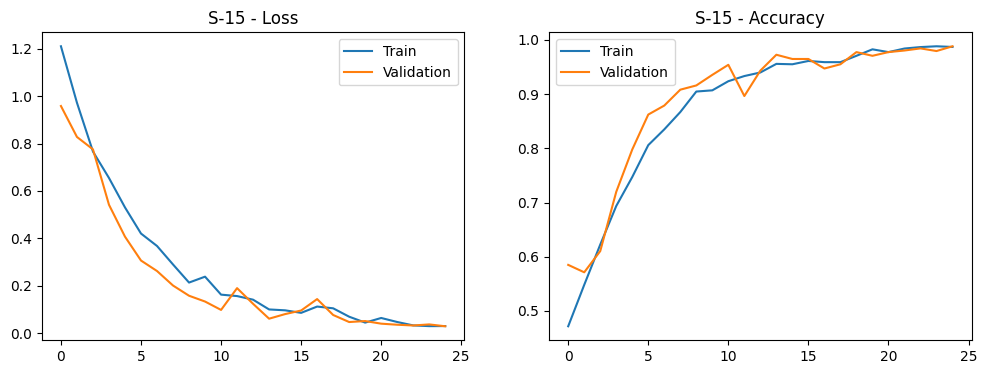


=== CLASSIFICATION REPORT: S-15 ===
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       172
           1       1.00      1.00      1.00        15
           2       1.00      0.97      0.98       634
           3       0.97      0.99      0.98       459

    accuracy                           0.98      1280
   macro avg       0.98      0.99      0.98      1280
weighted avg       0.98      0.98      0.98      1280



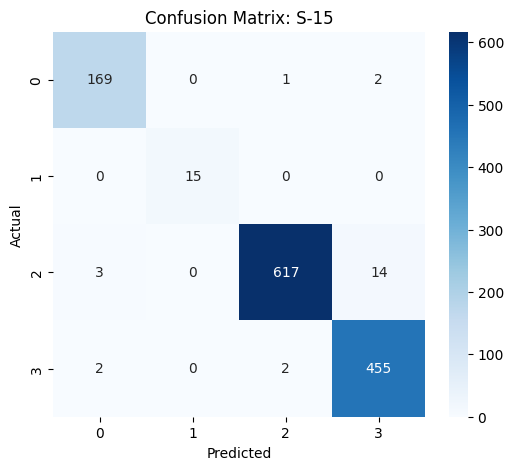

In [ ]:
# ==========================================
# 0. MOUNT GOOGLE DRIVE & SETUP FOLDER
# ==========================================
from google.colab import drive
import os

print("Mounting Google Drive...")
drive.mount('/content/drive')

# Buat folder khusus di Google Drive kamu
SAVE_DIR = '/content/drive/MyDrive/Alzheimer_EfficientNet_Models_Sampler'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Semua model akan disimpan di: {SAVE_DIR}")

# ==========================================
# IMPORT LIBRARIES
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CONFIG & SETUP
# ==========================================
CONFIG = {
    "lr": 1e-4,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("\nLoading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"] # 5120 data
test_data = hf_dataset["test"]      # 1280 data

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

train_labels = np.array(train_data["label"])

# ==========================================
# 3. CLASS WEIGHTS UNTUK LOSS FUNCTION
# ==========================================
print("\nMenghitung Class Weights...")
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts

# Normalisasi bobot agar tidak terlalu besar/kecil (best practice)
class_weights = class_weights / class_weights.sum() * len(class_counts)

# Konversi ke Tensor dan pindahkan ke device
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"Class Weights Tensor: {class_weights_tensor}")

# ==========================================
# 4. DATASET WRAPPER
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

# ==========================================
# 5. DEFINE TRANSFORMS (AUG & NO AUG)
# ==========================================
base_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

aug_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==========================================
# 6. EXPERIMENT FUNCTION (FULL FINE-TUNING + SAVE TO DRIVE)
# ==========================================
def run_experiment(experiment_name, train_transform, opt_type, sched_type):
    print(f"\n{'='*60}")
    print(f"STARTING: {experiment_name} | Opt: {opt_type} | Sched: {sched_type}")
    print(f"{'='*60}")

    # --- Setup DataLoaders (Normal Shuffle, NO WeightedRandomSampler) ---
    train_ds = AlzheimerDataset(train_data, train_transform)
    val_ds   = AlzheimerDataset(val_data, base_transform)
    test_ds  = AlzheimerDataset(test_data, base_transform)

    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])
    val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
    test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

    # --- Setup Model ---
    model = efficientnet_b2(weights=EfficientNet_B2_Weights.DEFAULT)

    # PERUBAHAN DI SINI: Pastikan SEMUA layer terbuka (Full Fine-Tuning)
    for param in model.parameters():
        param.requires_grad = True

    num_classes = len(np.unique(train_labels))
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(1408, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )
    model = model.to(device)

    # --- Loss & Optimizers ---
    # CLASS WEIGHT PADA LOSS FUNCTION
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

    # trainable_params mencakup KESELURUHAN model
    trainable_params = filter(lambda p: p.requires_grad, model.parameters())

    if opt_type == 'Adam':
        optimizer = optim.Adam(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'AdamW':
        optimizer = optim.AdamW(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'SGD':
        optimizer = optim.SGD(trainable_params, lr=CONFIG["lr"], momentum=0.9)
    else:
        raise ValueError("Optimizer tidak dikenali!")

    # --- Dynamic Scheduler ---
    if sched_type == 'CosineAnnealingLR':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])
    elif sched_type == 'ReduceLROnPlateau':
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
    else:
        raise ValueError("Scheduler tidak dikenali!")

    # --- Training Loop ---
    train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []
    best_model = copy.deepcopy(model.state_dict())
    best_loss = float("inf")
    counter = 0

    for epoch in range(CONFIG["epochs"]):
        # ===== Train =====
        model.train()
        train_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss /= total
        train_acc = correct / total

        # CosineAnnealingLR di-step setiap akhir epoch training
        if sched_type == 'CosineAnnealingLR':
            scheduler.step()

        # ===== Validation =====
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        # ReduceLROnPlateau di-step setiap akhir epoch validation
        if sched_type == 'ReduceLROnPlateau':
            scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:02d}/{CONFIG['epochs']} | LR: {current_lr:.2e} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        # ===== Early Stopping =====
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= CONFIG["patience"]:
                print("-> Early stopping triggered!")
                break

    # --- Load Best Model ---
    print(f"\nLoading best model for {experiment_name} testing...")
    model.load_state_dict(best_model)

    # ---------------------------------------------------------
    # SIMPAN MODEL KE GOOGLE DRIVE
    # ---------------------------------------------------------
    clean_name = experiment_name.replace(" ", "_").replace("-", "")
    model_filename = f"model_{clean_name}_{opt_type}_{sched_type}.pth"
    save_path = os.path.join(SAVE_DIR, model_filename)

    torch.save(model.state_dict(), save_path)
    print(f"Berhasil! Model disimpan di Drive: {save_path}")
    # ---------------------------------------------------------

    # --- Testing ---
    model.eval()
    all_probs, all_labels, all_preds = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())

    # --- Plotting & Metrics ---
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Validation")
    plt.title(f"{experiment_name} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label="Train")
    plt.plot(val_accuracies, label="Validation")
    plt.title(f"{experiment_name} - Accuracy")
    plt.legend()
    plt.show()

    print(f"\n=== CLASSIFICATION REPORT: {experiment_name} ===")
    print(classification_report(all_labels, all_preds))

    # --- Visualisasi Confusion Matrix ---
    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix: {experiment_name}")
    plt.show()

# ==========================================
# 7. RUN PIPELINES (SCENARIOS S-13 to S-18)
# ==========================================
scenarios_full_tuning = [
    {"name": "S-13", "opt": "Adam",  "sched": "ReduceLROnPlateau"},
    {"name": "S-14", "opt": "Adam",  "sched": "CosineAnnealingLR"},
    {"name": "S-15", "opt": "AdamW", "sched": "ReduceLROnPlateau"},
    # {"name": "S-16", "opt": "AdamW", "sched": "CosineAnnealingLR"},
    # {"name": "S-17", "opt": "SGD",   "sched": "ReduceLROnPlateau"},
    # {"name": "S-18", "opt": "SGD",   "sched": "CosineAnnealingLR"}
]

for scenario in scenarios_full_tuning:
    run_experiment(
        experiment_name=scenario["name"],
        train_transform=aug_transform,
        opt_type=scenario["opt"],
        sched_type=scenario["sched"]
    )

Mounting Google Drive...
Mounted at /content/drive
Semua model akan disimpan di: /content/drive/MyDrive/Alzheimer_EfficientNet_Models_Sampler
Device: cuda

Loading dataset...


README.md:   0%|          | 0.00/2.13k [00:00<?, ?B/s]

data/train-00000-of-00001-c08a401c53fe53(…):   0%|          | 0.00/22.6M [00:00<?, ?B/s]

data/test-00000-of-00001-44110b9df98c558(…):   0%|          | 0.00/5.65M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5120 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1280 [00:00<?, ? examples/s]

Train: 4096 | Val: 1024 | Test: 1280

Menghitung Class Weights...
Class Weights Tensor: tensor([0.2419, 3.5916, 0.0682, 0.0983], device='cuda:0')

STARTING: S-16 | Opt: AdamW | Sched: CosineAnnealingLR
Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 116MB/s]


Epoch 01/25 | LR: 9.96e-05 | Train Loss: 1.1680 Acc: 0.4807 | Val Loss: 0.9627 Acc: 0.5713
Epoch 02/25 | LR: 9.84e-05 | Train Loss: 0.9047 Acc: 0.5747 | Val Loss: 0.7447 Acc: 0.6055
Epoch 03/25 | LR: 9.65e-05 | Train Loss: 0.7606 Acc: 0.6270 | Val Loss: 0.6828 Acc: 0.6621
Epoch 04/25 | LR: 9.38e-05 | Train Loss: 0.6222 Acc: 0.6953 | Val Loss: 0.4828 Acc: 0.7578
Epoch 05/25 | LR: 9.05e-05 | Train Loss: 0.4802 Acc: 0.7666 | Val Loss: 0.3787 Acc: 0.8408
Epoch 06/25 | LR: 8.64e-05 | Train Loss: 0.3665 Acc: 0.8323 | Val Loss: 0.3008 Acc: 0.8330
Epoch 07/25 | LR: 8.19e-05 | Train Loss: 0.3447 Acc: 0.8564 | Val Loss: 0.2525 Acc: 0.9023
Epoch 08/25 | LR: 7.68e-05 | Train Loss: 0.2651 Acc: 0.8828 | Val Loss: 0.1614 Acc: 0.9209
Epoch 09/25 | LR: 7.13e-05 | Train Loss: 0.1791 Acc: 0.9141 | Val Loss: 0.1846 Acc: 0.9092
Epoch 10/25 | LR: 6.55e-05 | Train Loss: 0.1661 Acc: 0.9307 | Val Loss: 0.1338 Acc: 0.9355
Epoch 11/25 | LR: 5.94e-05 | Train Loss: 0.1311 Acc: 0.9441 | Val Loss: 0.1415 Acc: 0.9463

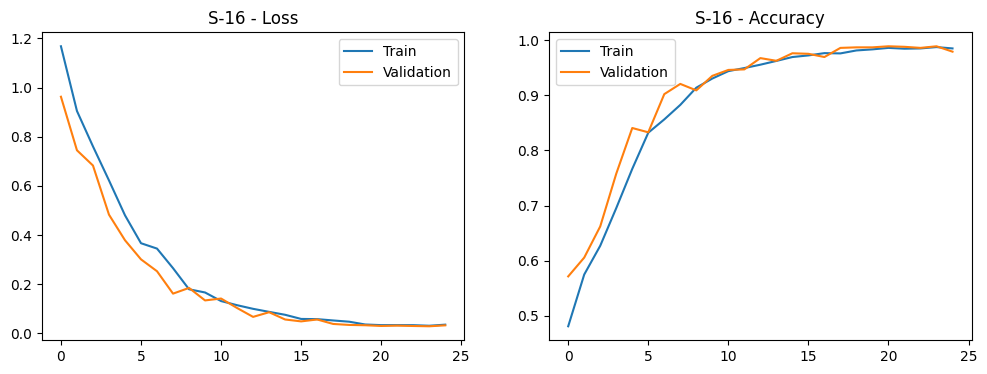


=== CLASSIFICATION REPORT: S-16 ===
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       172
           1       1.00      1.00      1.00        15
           2       0.99      0.99      0.99       634
           3       0.99      0.99      0.99       459

    accuracy                           0.99      1280
   macro avg       0.99      0.99      0.99      1280
weighted avg       0.99      0.99      0.99      1280



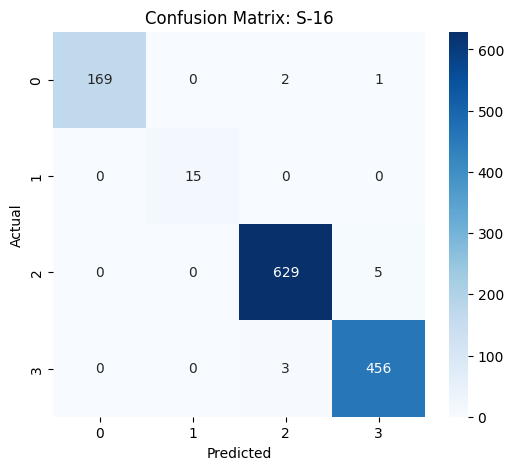


STARTING: S-17 | Opt: SGD | Sched: ReduceLROnPlateau
Epoch 01/25 | LR: 1.00e-04 | Train Loss: 1.3541 Acc: 0.3799 | Val Loss: 1.3450 Acc: 0.4590
Epoch 02/25 | LR: 1.00e-04 | Train Loss: 1.3341 Acc: 0.4001 | Val Loss: 1.3274 Acc: 0.4775
Epoch 03/25 | LR: 1.00e-04 | Train Loss: 1.3273 Acc: 0.4348 | Val Loss: 1.3152 Acc: 0.5068
Epoch 04/25 | LR: 1.00e-04 | Train Loss: 1.2976 Acc: 0.4688 | Val Loss: 1.3047 Acc: 0.5029
Epoch 05/25 | LR: 1.00e-04 | Train Loss: 1.2902 Acc: 0.4663 | Val Loss: 1.2912 Acc: 0.5205
Epoch 06/25 | LR: 1.00e-04 | Train Loss: 1.2699 Acc: 0.4934 | Val Loss: 1.2773 Acc: 0.5332
Epoch 07/25 | LR: 1.00e-04 | Train Loss: 1.2638 Acc: 0.4937 | Val Loss: 1.2602 Acc: 0.5254
Epoch 08/25 | LR: 1.00e-04 | Train Loss: 1.2619 Acc: 0.5017 | Val Loss: 1.2453 Acc: 0.5215
Epoch 09/25 | LR: 1.00e-04 | Train Loss: 1.2348 Acc: 0.5076 | Val Loss: 1.2277 Acc: 0.5156
Epoch 10/25 | LR: 1.00e-04 | Train Loss: 1.2176 Acc: 0.5208 | Val Loss: 1.2019 Acc: 0.5215
Epoch 11/25 | LR: 1.00e-04 | Train L

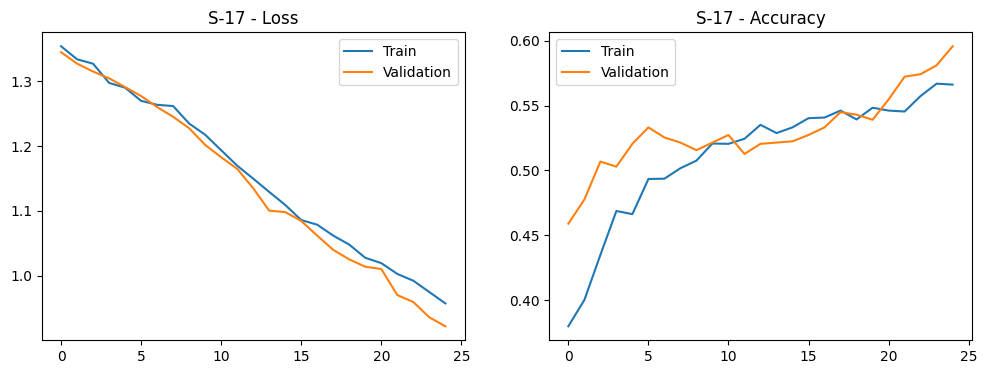


=== CLASSIFICATION REPORT: S-17 ===
              precision    recall  f1-score   support

           0       0.33      0.76      0.46       172
           1       0.85      0.73      0.79        15
           2       0.73      0.67      0.70       634
           3       0.55      0.34      0.42       459

    accuracy                           0.57      1280
   macro avg       0.61      0.63      0.59      1280
weighted avg       0.61      0.57      0.57      1280



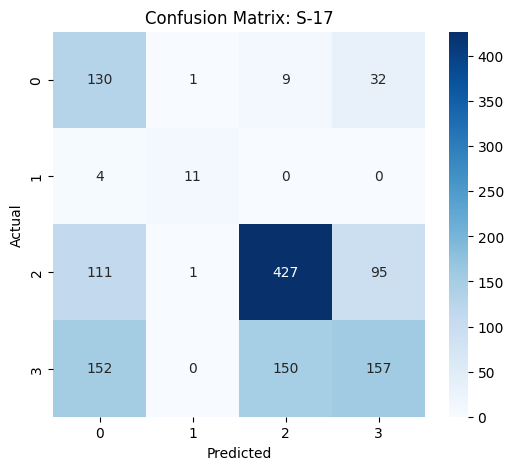


STARTING: S-18 | Opt: SGD | Sched: CosineAnnealingLR
Epoch 01/25 | LR: 9.96e-05 | Train Loss: 1.3737 Acc: 0.3071 | Val Loss: 1.3558 Acc: 0.3428
Epoch 02/25 | LR: 9.84e-05 | Train Loss: 1.3392 Acc: 0.3523 | Val Loss: 1.3368 Acc: 0.4268
Epoch 03/25 | LR: 9.65e-05 | Train Loss: 1.3296 Acc: 0.4021 | Val Loss: 1.3230 Acc: 0.4805
Epoch 04/25 | LR: 9.38e-05 | Train Loss: 1.3170 Acc: 0.4043 | Val Loss: 1.3130 Acc: 0.5273
Epoch 05/25 | LR: 9.05e-05 | Train Loss: 1.3081 Acc: 0.4412 | Val Loss: 1.3049 Acc: 0.5352
Epoch 06/25 | LR: 8.64e-05 | Train Loss: 1.2878 Acc: 0.4546 | Val Loss: 1.2908 Acc: 0.5400
Epoch 07/25 | LR: 8.19e-05 | Train Loss: 1.2856 Acc: 0.4656 | Val Loss: 1.2813 Acc: 0.5215
Epoch 08/25 | LR: 7.68e-05 | Train Loss: 1.2695 Acc: 0.4824 | Val Loss: 1.2704 Acc: 0.5391
Epoch 09/25 | LR: 7.13e-05 | Train Loss: 1.2571 Acc: 0.5059 | Val Loss: 1.2577 Acc: 0.5322
Epoch 10/25 | LR: 6.55e-05 | Train Loss: 1.2421 Acc: 0.5190 | Val Loss: 1.2440 Acc: 0.5361
Epoch 11/25 | LR: 5.94e-05 | Train L

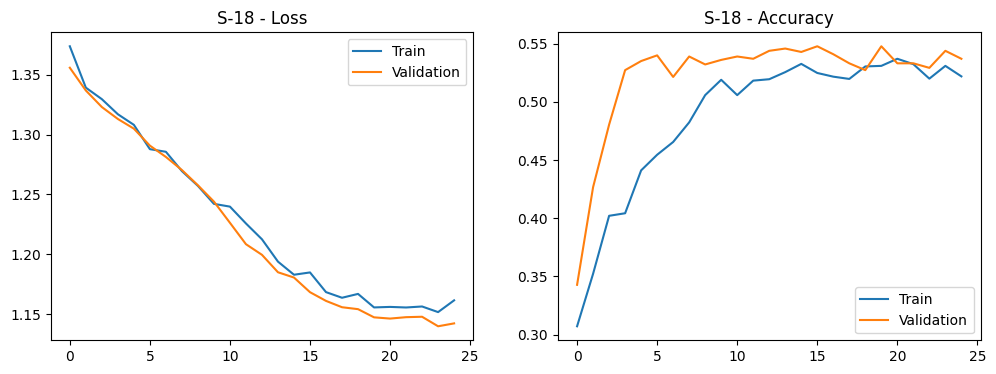


=== CLASSIFICATION REPORT: S-18 ===
              precision    recall  f1-score   support

           0       0.27      0.58      0.37       172
           1       0.00      0.00      0.00        15
           2       0.64      0.74      0.69       634
           3       0.43      0.17      0.24       459

    accuracy                           0.50      1280
   macro avg       0.33      0.37      0.32      1280
weighted avg       0.51      0.50      0.48      1280



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


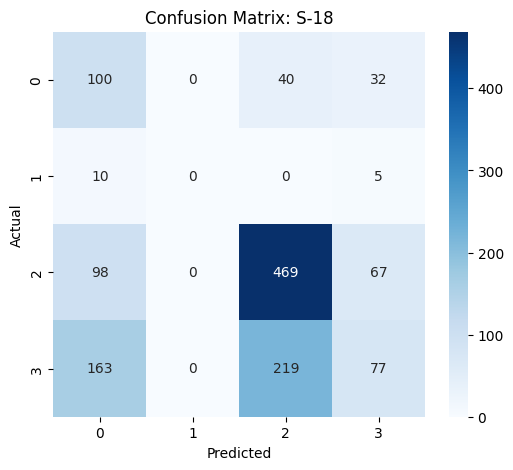

In [ ]:
# ==========================================
# 0. MOUNT GOOGLE DRIVE & SETUP FOLDER
# ==========================================
from google.colab import drive
import os

print("Mounting Google Drive...")
drive.mount('/content/drive')

# Buat folder khusus di Google Drive kamu
SAVE_DIR = '/content/drive/MyDrive/Alzheimer_EfficientNet_Models_Sampler'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Semua model akan disimpan di: {SAVE_DIR}")

# ==========================================
# IMPORT LIBRARIES
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CONFIG & SETUP
# ==========================================
CONFIG = {
    "lr": 1e-4,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("\nLoading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"] # 5120 data
test_data = hf_dataset["test"]      # 1280 data

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

train_labels = np.array(train_data["label"])

# ==========================================
# 3. CLASS WEIGHTS UNTUK LOSS FUNCTION
# ==========================================
print("\nMenghitung Class Weights...")
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts

# Normalisasi bobot agar tidak terlalu besar/kecil (best practice)
class_weights = class_weights / class_weights.sum() * len(class_counts)

# Konversi ke Tensor dan pindahkan ke device
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"Class Weights Tensor: {class_weights_tensor}")

# ==========================================
# 4. DATASET WRAPPER
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

# ==========================================
# 5. DEFINE TRANSFORMS (AUG & NO AUG)
# ==========================================
base_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

aug_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==========================================
# 6. EXPERIMENT FUNCTION (FULL FINE-TUNING + SAVE TO DRIVE)
# ==========================================
def run_experiment(experiment_name, train_transform, opt_type, sched_type):
    print(f"\n{'='*60}")
    print(f"STARTING: {experiment_name} | Opt: {opt_type} | Sched: {sched_type}")
    print(f"{'='*60}")

    # --- Setup DataLoaders (Normal Shuffle, NO WeightedRandomSampler) ---
    train_ds = AlzheimerDataset(train_data, train_transform)
    val_ds   = AlzheimerDataset(val_data, base_transform)
    test_ds  = AlzheimerDataset(test_data, base_transform)

    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])
    val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
    test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

    # --- Setup Model ---
    model = efficientnet_b2(weights=EfficientNet_B2_Weights.DEFAULT)

    # PERUBAHAN DI SINI: Pastikan SEMUA layer terbuka (Full Fine-Tuning)
    for param in model.parameters():
        param.requires_grad = True

    num_classes = len(np.unique(train_labels))
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(1408, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )
    model = model.to(device)

    # --- Loss & Optimizers ---
    # CLASS WEIGHT PADA LOSS FUNCTION
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

    # trainable_params mencakup KESELURUHAN model
    trainable_params = filter(lambda p: p.requires_grad, model.parameters())

    if opt_type == 'Adam':
        optimizer = optim.Adam(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'AdamW':
        optimizer = optim.AdamW(trainable_params, lr=CONFIG["lr"])
    elif opt_type == 'SGD':
        optimizer = optim.SGD(trainable_params, lr=CONFIG["lr"], momentum=0.9)
    else:
        raise ValueError("Optimizer tidak dikenali!")

    # --- Dynamic Scheduler ---
    if sched_type == 'CosineAnnealingLR':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])
    elif sched_type == 'ReduceLROnPlateau':
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
    else:
        raise ValueError("Scheduler tidak dikenali!")

    # --- Training Loop ---
    train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []
    best_model = copy.deepcopy(model.state_dict())
    best_loss = float("inf")
    counter = 0

    for epoch in range(CONFIG["epochs"]):
        # ===== Train =====
        model.train()
        train_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss /= total
        train_acc = correct / total

        # CosineAnnealingLR di-step setiap akhir epoch training
        if sched_type == 'CosineAnnealingLR':
            scheduler.step()

        # ===== Validation =====
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        # ReduceLROnPlateau di-step setiap akhir epoch validation
        if sched_type == 'ReduceLROnPlateau':
            scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:02d}/{CONFIG['epochs']} | LR: {current_lr:.2e} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        # ===== Early Stopping =====
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= CONFIG["patience"]:
                print("-> Early stopping triggered!")
                break

    # --- Load Best Model ---
    print(f"\nLoading best model for {experiment_name} testing...")
    model.load_state_dict(best_model)

    # ---------------------------------------------------------
    # SIMPAN MODEL KE GOOGLE DRIVE
    # ---------------------------------------------------------
    clean_name = experiment_name.replace(" ", "_").replace("-", "")
    model_filename = f"model_{clean_name}_{opt_type}_{sched_type}.pth"
    save_path = os.path.join(SAVE_DIR, model_filename)

    torch.save(model.state_dict(), save_path)
    print(f"Berhasil! Model disimpan di Drive: {save_path}")
    # ---------------------------------------------------------

    # --- Testing ---
    model.eval()
    all_probs, all_labels, all_preds = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())

    # --- Plotting & Metrics ---
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Validation")
    plt.title(f"{experiment_name} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label="Train")
    plt.plot(val_accuracies, label="Validation")
    plt.title(f"{experiment_name} - Accuracy")
    plt.legend()
    plt.show()

    print(f"\n=== CLASSIFICATION REPORT: {experiment_name} ===")
    print(classification_report(all_labels, all_preds))

    # --- Visualisasi Confusion Matrix ---
    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix: {experiment_name}")
    plt.show()

# ==========================================
# 7. RUN PIPELINES (SCENARIOS S-13 to S-18)
# ==========================================
scenarios_full_tuning = [
    # {"name": "S-13", "opt": "Adam",  "sched": "ReduceLROnPlateau"},
    # {"name": "S-14", "opt": "Adam",  "sched": "CosineAnnealingLR"},
    # {"name": "S-15", "opt": "AdamW", "sched": "ReduceLROnPlateau"},
    {"name": "S-16", "opt": "AdamW", "sched": "CosineAnnealingLR"},
    {"name": "S-17", "opt": "SGD",   "sched": "ReduceLROnPlateau"},
    {"name": "S-18", "opt": "SGD",   "sched": "CosineAnnealingLR"}
]

for scenario in scenarios_full_tuning:
    run_experiment(
        experiment_name=scenario["name"],
        train_transform=aug_transform,
        opt_type=scenario["opt"],
        sched_type=scenario["sched"]
    )